In [1]:

#импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 

from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [2]:
pd.set_option('Display.max_columns', None)
pd.set_option('Display.max_rows', None)

In [3]:
import oracledb
import pyodbc 
import time


import oracledb


connection = oracledb.connect(
    user = "USR_IBRAGIMOVASM",
    password = "mYJfvnul",
    dsn ="cprd-dwh-dbprim:1521/ODSPROD"
)

cursor = connection.cursor()

#ID_NOM_COL, OBJECT_GEO_LAT, OBJECT_GEO_LON, ID_EXP_MONTH, ID_EXP_YEAR,  ID_DATE_NO_COL, ID_DATE_OO_COL, EXPOSURE_TO_YEAR 

df = pd.read_sql_query('''select   *          
                        from DMS_DOG_LOSS_01_2026_v1
                       ''', connection) 

C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\213042919.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query('''select   *


In [ ]:
# df=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\рез-т запроса полисы убытки_v2.xlsx')

d:\ProgramData\Anaconda3\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [91]:
df_spark=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\спарк_all_transl2.xlsx')

In [92]:
df.head()

,AGREEMENT_ID,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_INN,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,CANCEL_DATE,Пол,F_GENDER,CHILD,RELATIVE,REGION,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,COST_YEAR_PROGRAM,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,POLICY_AGREEMENT_ID,POLICY_DOGOVOR_NUMBER_POLICY,POLICY_POLICY_NUMBER,NAME,ORG_TYPE,STAR,REVIEWS,BUS_DIST_MIN,SUBWAY_DIST_MIN,COORDS,SUBWAY_SYNT,LOSS_BILL_POLICY_NUMBER,GROUP (KOD SETI/LPU),GROUP name SETI/TOU,CODE TOU new,SERVICE_POINT_ID_NEW,ASSISTANCE_TYPE,REGION ITOG,REGION ITOG_GROUP,SUM_PRICE_TO_PAY,CNT,CLINIC_RANK,SUM_PAID_ALL,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_LEVEL_NUM_FOR_FREQ,COVENANTA,COMISSION_PERCENTAGE_FIX,PROGRAM_LIST_RISK_PREPAY_SPEC,SUM_PRICE_TO_PAY_0,PAID_FLAG,YEAR
0,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,КАМЕНЬТОРГ,008БС4581005350,5024133217,"ООО ""КАМЛИТ""",Ю,008БС4581005347-6,2023-10-02,2024-10-01 23:59:59,2023-10-02,2024-10-01 23:59:59,367,0,0,1.0,21.0,0.05,NaT,М,0,0,0,Московская,0,1,0,0,Программа № 1: Взрослая Москва,119910.0,1.0,Первичный,Московская,Московская обл,39,30-39,18-64,1.0,Обрабатывающие производства,Раздел C,1,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,008БС4581005347-6,Андреевские больницы Неболит,"Медцентр, клиника",4.9,2274.0,0.42,1.63,"55.825998,37.371209",0.890,008БС4581005347-6,4976-Сеть1367,МЦ НЕБОЛИТ,RMS000111,578f3e61-5edb-45bb-a4a6-19b3c76a9e86,Посредник РМС,МОСКВА И МО,МОСКВА И МО,25770.0,6.0,1.0,25770.0,Prochee,0.0,1,covenant,60.0,Риск,0.0,1,2023
1,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,КАМЕНЬТОРГ,008БС4581005350,5024133217,"ООО ""КАМЛИТ""",Ю,008БС4581005347-11,2023-10-02,2024-10-01 23:59:59,2023-10-02,2024-10-01 23:59:59,367,0,0,1.0,21.0,0.05,NaT,М,0,0,0,None,0,1,0,0,Программа № 1: Взрослая Москва,119910.0,1.0,Первичный,Московская,Московская обл,41,40-49,18-64,1.0,Обрабатывающие производства,Раздел C,1,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,008БС4581005347-11,Андреевские больницы Неболит,"Медцентр, клиника",4.9,2274.0,0.42,1.63,"55.825998,37.371209",0.381,008БС4581005347-11,4976-Сеть1367,МЦ НЕБОЛИТ,RMS000111,ddda6070-ad54-4361-987d-12e411dd1436,Посредник РМС,МОСКВА И МО,МОСКВА И МО,6340.0,2.0,1.0,6340.0,Prochee,0.0,1,covenant,60.0,Риск,0.0,1,2023
2,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,КАМЕНЬТОРГ,008БС4581005350,5024133217,"ООО ""КАМЛИТ""",Ю,008БС4581005347-12,2023-10-02,2024-10-01 23:59:59,2023-10-02,2024-10-01 23:59:59,367,0,0,1.0,21.0,0.05,NaT,Ж,1,0,0,Московская,0,1,0,0,Программа № 1: Взрослая Москва,119910.0,1.0,Первичный,Московская,Московская обл,34,30-39,18-64,1.0,Обрабатывающие производства,Раздел C,1,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,008БС4581005347-12,Андреевские больницы Неболит,"Медцентр, клиника",4.9,2274.0,0.42,1.63,"55.825998,37.371209",0.381,008БС4581005347-12,4976-Сеть1367,МЦ НЕБОЛИТ,RMS000111,824e847e-6672-498c-8be0-3baebd296ef7,Посредник РМС,МОСКВА И МО,МОСКВА И МО,69840.0,20.0,1.0,69840.0,Prochee,0.0,1,covenant,60.0,Риск,0.0,1,2023
3,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,КАМЕНЬТОРГ,008БС4581005350,5024133217,"ООО ""КАМЛИТ""",Ю,008БС4581005347-15,2023-10-02,2024-10-01 23:59:59,2023-10-02,2024-10-01 23:59:59,367,0,0,1.0,21.0,0.05,NaT,М,0,0,0,Москва,0,1,0,0,Программа № 1: Взрослая Москва,119910.0,1.0,Первичный,Московская,Московская обл,58,50-59,18-64,1.0,Обрабатывающие производства,Раздел C,1,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,008БС4581005347-15,Медлайн-Сервис,"Медцентр, клиника",5.0,107.0,NaN,1.32,"55.658724,37.51447",0.188,008БС4581005347-15,731-Сеть1,МедлайН-Сервис,731-2,18812866-38d8-47b1-b1db-677e24433668,Прямой договор СБС,МОСКВА И МО,МОСКВА И МО,4650.0,2.0,1.0,4650.0,ECONOM,1.0,1,covenant,60.0,Риск,0.0,1,2023
4,82AD005056012C8911EE5CB8236EE65D,008БС458100

In [86]:
df['HOLDING'] = df['HOLDING'].fillna(df['INSURANT_NAME'])

In [7]:
df_spark.head()

,name,website,date_reg,age_of_company,liquidation,INSURANT_INN,form_of_ownership,public_sector,IDO,IFR,IPD,Zalog,Leasing,Intellect_property,Size_of_company,count_empoyees,Equity_capital,Tax_type,income,outcome,income_tax,Vznos_PFR,Vznos_FOMS,Vznos_FSS,Net_assets,Current_assets,UK,Nerasped_profit,sobstvnii_oborotnii_capital,Revenue,Profit_before_tax,Net_profit,Salary,Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv,Sootnoshenie sovokupnogo dolga k EBIT,Rentabelnost prodazh,Rentabelnost activov (ROA),Rentabelnost capitala (ROE),Coeff tekushei liqvidnosti,Coeff bistroi liqvidnosti,YEAR
0,"(КОЛХОЗ) ИМЕНИ ФРУНЗЕ, СПК",0,1993-12-28,28.0,0,2238000057,16 - Частная собственность,NaN,1.0,37.0,NaN,да,да,NaN,Микропредприятия,0,30213300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98131000.0,62085000.0,40000.0,92983000.0,60419000.0,4.996200e+07,6712000.0,6309000.0,5425000.0,0.0,0.0,0.2,0.1,0.1,37.3,7.1,2021
1,"(КОЛХОЗ) ИМЕНИ ШЕВЧЕНКО, СПК",0,1993-03-23,28.0,0,5627000270,16 - Частная собственность,NaN,1.0,5.0,NaN,да,NaN,NaN,Малые предприятия,0,11429000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,387259000.0,222633000.0,11429000.0,363265000.0,213307000.0,3.119830e+08,94097000.0,94097000.0,58130000.0,0.2,0.8,0.3,0.2,0.3,25.4,5.6,2021
2,"1 СТРОЙЦЕНТР САТУРН-Р, ООО",1,2013-09-12,8.0,0,5902240063,16 - Частная собственность,NaN,2.0,13.0,94.0,NaN,NaN,да,Крупные предприятия,201,10000.0,NaN,4.782478e+09,4.658521e+09,31355583.0,32657284.0,8002251.0,592822.0,399260000.0,977366000.0,10000.0,399250000.0,584452000.0,4.629256e+09,123957000.0,95626000.0,204535000.0,1.6,1.9,0.0,0.1,0.3,2.6,1.7,2021
3,"100 БИЛЕТОВ, ООО",0,2018-03-20,3.0,0,7107125534,16 - Частная собственность,NaN,29.0,35.0,NaN,NaN,NaN,NaN,Малые предприятия,1,10000.0,УСН,1.200000e+05,7.700000e+04,NaN,NaN,NaN,NaN,-130000.0,2452000.0,10000.0,-140000.0,-130000.0,1.200000e+05,43000.0,36000.0,NaN,-19.9,0.0,0.5,0.0,-0.2,0.9,0.9,2021
4,"1760 ГОД, ООО",0,2005-10-14,16.0,0,1831107146,16 - Частная собственность,NaN,11.0,22.0,NaN,NaN,NaN,NaN,Малые предприятия,70,40000.0,NaN,5.419580e+08,5.361200e+08,1397872.0,4394005.0,1304825.0,381536.0,75846000.0,187994000.0,40000.0,75806000.0,114019000.0,5.403960e+08,5838000.0,4145000.0,32972000.0,1.7,5.4,0.0,0.0,0.1,1.8,0.6,2021


In [88]:
df.shape

(166363, 72)

In [89]:
#df['spark_income_bin'] = df['spark_income_bin'].fillna('not_def')

df['PROLONGATION_TYPE'] = df['PROLONGATION_TYPE'].fillna('not_def')
df['COVENANTA'] = df['COVENANTA'].fillna('not_def')
df['COMISSION_PERCENTAGE_FIX'] = df['COMISSION_PERCENTAGE_FIX'].fillna('not_def')
df['ASSISTANCE_TYPE'] = df['ASSISTANCE_TYPE'].fillna('not_def')

In [ ]:
# # Шаг 1: Убедимся, что RESP_DT_BEG — тип datetime
df['RESP_DT_BEG'] = pd.to_datetime(df['RESP_DT_BEG'])
df['YEAR'] = df['RESP_DT_BEG'].dt.year  # создаём год для джойна

# Шаг 2: Добавляем префикс spark_ ко ВСЕМ столбцам df_spark, кроме INN и YEAR (ключей)
# Сохраним оригинальные названия ключей
df_spark_renamed = df_spark.copy()

# Список ключей, которые не переименовываем
key_columns = ['INSURANT_INN', 'INN', 'YEAR']

# Переименовываем все НЕключевые столбцы
rename_cols = {
    col: f"spark_{col}" for col in df_spark_renamed.columns if col not in key_columns
}
df_spark_renamed = df_spark_renamed.rename(columns=rename_cols)

# Если был INN → переименовываем в INSURANT_INN
if 'INN' in df_spark_renamed.columns:
    df_spark_renamed = df_spark_renamed.rename(columns={'INN': 'INSURANT_INN'})

# 🔑 Приводим ключи к одинаковому типу (str)
df['INSURANT_INN'] = df['INSURANT_INN'].astype(str)
df_spark_renamed['INSURANT_INN'] = df_spark_renamed['INSURANT_INN'].astype(str)

df['YEAR'] = df['YEAR'].astype(str)
df_spark_renamed['YEAR'] = df_spark_renamed['YEAR'].astype(str)

# Объединяем
df_merge = pd.merge(
    df,
    df_spark_renamed,
    on=['INSURANT_INN', 'YEAR'],
    how='left'
)





In [99]:
df_merge['spark_Zalog'] = df_merge['spark_Zalog'].fillna('not_def')
df_merge['spark_Leasing'] = df_merge['spark_Leasing'].fillna('not_def')
df_merge['spark_Intellect_property'] = df_merge['spark_Intellect_property'].fillna('not_def')
df_merge['spark_public_sector'] = df_merge['spark_public_sector'].fillna('not_def')
df_merge['spark_Tax_type'] = df_merge['spark_Tax_type'].fillna('not_def')

In [ ]:
# def add_quantile_binning_v4(df_merge, col_name, n_bins=50, exclude_cols=None, max_unique=200):
#     """
#     Условный биннинг числовой колонки с защитой от NaN и выделением -999 в отдельный бин.
#     """
#     if exclude_cols is None:
#         exclude_cols = []

#     if col_name not in df_merge.columns:
#         raise ValueError(f"Колонка '{col_name}' не найдена.")

#     n_unique = df_merge[col_name].nunique(dropna=True)
#     if n_unique < max_unique:
#         print(f"Пропущено биннингом: {col_name} (уникальных: {n_unique} < {max_unique})")
#         return df_merge

#     if n_unique == 1:
#         print(f"Пропущено: все значения '{col_name}' одинаковы")
#         return df_merge

#     bin_col_name = f"{col_name}_bin"
#     if bin_col_name in df_merge.columns:
#         raise ValueError(f"Колонка '{bin_col_name}' уже существует.")

#     # === Новая логика: выделяем -999 отдельно ===
#     # Создаём маску для -999
#     mask_minus_999 = (df_merge[col_name] == -999)
#     not_minus_999 = ~mask_minus_999

#     # Если все строки — -999 или ничего нет — обрабатываем отдельно
#     if not_minus_999.sum() == 0:
#         # Все значения — -999
#         df_merge[bin_col_name] = pd.Categorical([f"{col_name}_-999"] * len(df_merge), categories=[f"{col_name}_-999"])
#         print(f"Все значения — -999 → один бин: {bin_col_name}")
#         if col_name not in exclude_cols:
#             df_merge.drop(columns=[col_name], inplace=True)
#         return df_merge

#     # Подготовка: работаем с не--999 значениями
#     temp_col = df_merge.loc[not_minus_999, col_name]

#     # Проверяем количество уникальных значений среди не--999
#     n_unique_clean = temp_col.nunique(dropna=True)
#     if n_unique_clean < 2:
#         print(f"Недостаточно уникальных значений после исключения -999: {col_name}")
#         return df_merge

#     try:
#         binned = pd.qcut(temp_col, q=n_bins, duplicates='drop')
#     except Exception as e:
#         print(f"Не удалось построить qcut для '{col_name}' (без -999): {e}")
#         return df_merge

#     # Создаём результирующую колонку с пропусками
#     labels = pd.Series([None] * len(df_merge), index=df_merge.index)

#     # Заполняем метки для не--999
#     def get_label(interval):
#         if pd.isna(interval):
#             return f"{col_name}_nan"
#         left = int(round(interval.left))
#         right = int(round(interval.right))
#         return f"{col_name}_{left}_{right}"

#     labels.loc[not_minus_999] = binned.apply(get_label).astype(str)

#     # Заполняем метки для -999
#     labels.loc[mask_minus_999] = f"{col_name}_-999"

#     # Заменяем возможные NaN в метках (на всякий случай)
#     labels = labels.fillna(f"{col_name}_nan")

#     # Формируем категории
#     unique_labels = sorted(labels.unique().tolist())  # включает: диапазоны, _-999, _nan

#     # Создаём категориальную колонку
#     df_merge[bin_col_name] = pd.Categorical(labels, categories=unique_labels, ordered=False)

#     # Удаляем исходную колонку, если нужно
#     #if col_name not in exclude_cols:
#     #    df.drop(columns=[col_name], inplace=True)
#     #    print(f"Бинировано и удалено: {col_name} → {bin_col_name}")
#     #else:
#     #    print(f"Бинировано, но сохранено: {col_name} (в exclude_cols)")

#     return df_merge


In [ ]:
# exclude_list =[]
# #['V_NUM_ACC', 'V_EXPOSURE_TO_YEAR', 'ID_POLICY',  'SUM_PAID', 'EXPOSURE_TO_YEAR']

# numeric_cols = df_merge.select_dtypes(include=[np.number]).columns.tolist()

# for col in numeric_cols:
#     add_quantile_binning_v4(df_merge, col, n_bins=10, exclude_cols=exclude_list, max_unique=200)

# print("Условный биннинг завершён.")


In [100]:
df_merge.head()

,AGREEMENT_ID,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_INN,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,CANCEL_DATE,Пол,F_GENDER,CHILD,RELATIVE,REGION,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,COST_YEAR_PROGRAM,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,POLICY_AGREEMENT_ID,POLICY_DOGOVOR_NUMBER_POLICY,POLICY_POLICY_NUMBER,NAME,ORG_TYPE,STAR,REVIEWS,BUS_DIST_MIN,SUBWAY_DIST_MIN,COORDS,SUBWAY_SYNT,LOSS_BILL_POLICY_NUMBER,GROUP (KOD SETI/LPU),GROUP name SETI/TOU,CODE TOU new,SERVICE_POINT_ID_NEW,ASSISTANCE_TYPE,REGION ITOG,REGION ITOG_GROUP,SUM_PRICE_TO_PAY,CNT,CLINIC_RANK,SUM_PAID_ALL,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_LEVEL_NUM_FOR_FREQ,COVENANTA,COMISSION_PERCENTAGE_FIX,PROGRAM_LIST_RISK_PREPAY_SPEC,SUM_PRICE_TO_PAY_0,PAID_FLAG,YEAR,spark_name,spark_website,spark_date_reg,spark_age_of_company,spark_liquidation,spark_form_of_ownership,spark_public_sector,spark_IDO,spark_IFR,spark_IPD,spark_Zalog,spark_Leasing,spark_Intellect_property,spark_Size_of_company,spark_count_empoyees,spark_Equity_capital,spark_Tax_type,spark_income,spark_outcome,spark_income_tax,spark_Vznos_PFR,spark_Vznos_FOMS,spark_Vznos_FSS,spark_Net_assets,spark_Current_assets,spark_UK,spark_Nerasped_profit,spark_sobstvnii_oborotnii_capital,spark_Revenue,spark_Profit_before_tax,spark_Net_profit,spark_Salary,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv,spark_Sootnoshenie sovokupnogo dolga k EBIT,spark_Rentabelnost prodazh,spark_Rentabelnost activov (ROA),spark_Rentabelnost capitala (ROE),spark_Coeff tekushei liqvidnosti,spark_Coeff bistroi liqvidnosti
0,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,КАМЕНЬТОРГ,008БС4581005350,5024133217,"ООО ""КАМЛИТ""",Ю,008БС4581005347-6,2023-10-02,2024-10-01 23:59:59,2023-10-02,2024-10-01 23:59:59,367,0,0,1.0,21.0,0.05,NaT,М,0,0,0,Московская,0,1,0,0,Программа № 1: Взрослая Москва,119910.0,1.0,Первичный,Московская,Московская обл,39,30-39,18-64,1.0,Обрабатывающие производства,Раздел C,1,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,008БС4581005347-6,Андреевские больницы Неболит,"Медцентр, клиника",4.9,2274.0,0.42,1.63,"55.825998,37.371209",0.890,008БС4581005347-6,4976-Сеть1367,МЦ НЕБОЛИТ,RMS000111,578f3e61-5edb-45bb-a4a6-19b3c76a9e86,Посредник РМС,МОСКВА И МО,МОСКВА И МО,25770.0,6.0,1.0,25770.0,Prochee,0.0,1,covenant,60.0,Риск,0.0,1,2023,"КАМЛИТ, ООО",1.0,2012-12-25,13.0,0.0,16 - Частная собственность,not_def,14.0,30.0,NaN,да,not_def,not_def,Малые предприятия,103.0,10000.0,not_def,325001000.0,321557000.0,2158065.0,2591212.0,777381.0,191517.0,64557000.0,364991000.0,10000.0,64547000.0,-23709000.0,319010000.0,3444000.0,1341000.0,49741000.0,5.9,19.1,0.0,0.0,0.0,1.0,0.4
1,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,КАМЕНЬТОРГ,008БС4581005350,5024133217,"ООО ""КАМЛИТ""",Ю,008БС4581005347-11,2023-10-02,2024-10-01 23:59:59,2023-10-02,2024-10-01 23:59:59,367,0,0,1.0,21.0,0.05,NaT,М,0,0,0,None,0,1,0,0,Программа № 1: Взрослая Москва,119910.0,1.0,Первичный,Московская,Московская обл,41,40-49,18-64,1.0,Обрабатывающие производства,Раздел C,1,82AD005056012C8911EE5CB8236EE65D,008БС4581005347,008БС4581005347-11,Андреевские больницы Неболит,"Медцентр, клиника",4.9,2274.0,0.42,1.63,"55.825998,37.371209",0.381,008БС4581005347-11,4976-Сеть1367,МЦ НЕБОЛИТ,RMS000111,ddda6070-ad54-4361-987d-12e411dd1436,Посредник РМС,МОСКВА И МО,МОСКВА И МО,6340.0,2.0,1.0,6340.0,Prochee,0.0,1,covenant,60.0,Риск,0.0,1,2023,"КАМЛИТ, ООО",1.0,2012-12-25,13.0,0.0,16 - Частная собственность,not_def,14.0,30.0,NaN,да,not_def,not_def,Малые предприятия,103.0,10000.0,not_def,325001000.0,321557000.0,2158065.0,2591212.0,777381.0,191517.0,64557000.0,364991000.0,10000.0,64547000.0,-23709000.0,319010000.0,3444000.0,1341000.0,49741000.0,5.9,19.1,0.0,0.0,0.0,1.0,0.4
2,82AD005056012C8911EE5CB8236EE65D,008БС45

In [101]:
df_merge.shape

(166363, 112)

In [127]:
df_merge.head()

,AGREEMENT_ID,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_INN,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,CANCEL_DATE,Pol,F_GENDER,CHILD,RELATIVE,REGION,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,COST_YEAR_PROGRAM,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,POLICY_AGREEMENT_ID,POLICY_DOGOVOR_NUMBER_POLICY,POLICY_POLICY_NUMBER,NAME,ORG_TYPE,STAR,REVIEWS,BUS_DIST_MIN,SUBWAY_DIST_MIN,COORDS,SUBWAY_SYNT,LOSS_BILL_POLICY_NUMBER,GROUP (KOD SETI/LPU),GROUP name SETI/TOU,CODE TOU new,SERVICE_POINT_ID_NEW,ASSISTANCE_TYPE,REGION ITOG,REGION ITOG_GROUP,SUM_PRICE_TO_PAY,CNT,CLINIC_RANK,SUM_PAID_ALL,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_LEVEL_NUM_FOR_FREQ,COVENANTA,COMISSION_PERCENTAGE_FIX,PROGRAM_LIST_RISK_PREPAY_SPEC,SUM_PRICE_TO_PAY_0,PAID_FLAG,YEAR,spark_name,spark_website,spark_date_reg,spark_age_of_company,spark_liquidation,spark_form_of_ownership,spark_public_sector,spark_IDO,spark_IFR,spark_IPD,spark_Zalog,spark_Leasing,spark_Intellect_property,spark_Size_of_company,spark_count_empoyees,spark_Equity_capital,spark_Tax_type,spark_income,spark_outcome,spark_income_tax,spark_Vznos_PFR,spark_Vznos_FOMS,spark_Vznos_FSS,spark_Net_assets,spark_Current_assets,spark_UK,spark_Nerasped_profit,spark_sobstvnii_oborotnii_capital,spark_Revenue,spark_Profit_before_tax,spark_Net_profit,spark_Salary,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv,spark_Sootnoshenie sovokupnogo dolga k EBIT,spark_Rentabelnost prodazh,spark_Rentabelnost activov (ROA),spark_Rentabelnost capitala (ROE),spark_Coeff tekushei liqvidnosti,spark_Coeff bistroi liqvidnosti
0,82AD005056012C8911EE5CB8236EE65D,008BS4581005347,KAMEN'TORG,008BS4581005350,5024133217,"OOO ""KAMLIT""",Ju,008BS4581005347-6,2023-10-02 00:00:00,2024-10-01 23:59:59,2023-10-02 00:00:00,2024-10-01 23:59:59,367,0,0,1.0,21.0,0.05,NaT,M,0,0,0,Moskovskaja,0,1,0,0,Programma № 1: Vzroslaja Moskva,119910.0,1.0,Pervichnyj,Moskovskaja,Moskovskaja obl,39,30-39,18-64,1.0,Obrabatyvajuschie proizvodstva,Razdel C,1,82AD005056012C8911EE5CB8236EE65D,008BS4581005347,008BS4581005347-6,Andreevskie bol'nitsy Nebolit,"Medtsentr, klinika",4.9,2274.0,0.42,1.63,"55.825998,37.371209",0.890,008BS4581005347-6,4976-Set'1367,MTs NEBOLIT,RMS000111,578f3e61-5edb-45bb-a4a6-19b3c76a9e86,Posrednik RMS,MOSKVA I MO,MOSKVA I MO,25770.0,6.0,1.0,25770.0,Prochee,0.0,1,covenant,60.0,Risk,0.0,1,2023,"KAMLIT, OOO",1.0,2012-12-25 00:00:00,13.0,0.0,16 - Chastnaja sobstvennost',not_def,14.0,30.0,NaN,da,not_def,not_def,Malye predprijatija,103.0,10000.0,not_def,325001000.0,321557000.0,2158065.0,2591212.0,777381.0,191517.0,64557000.0,364991000.0,10000.0,64547000.0,-23709000.0,319010000.0,3444000.0,1341000.0,49741000.0,5.9,19.1,0.0,0.0,0.0,1.0,0.4
1,82AD005056012C8911EE5CB8236EE65D,008BS4581005347,KAMEN'TORG,008BS4581005350,5024133217,"OOO ""KAMLIT""",Ju,008BS4581005347-11,2023-10-02 00:00:00,2024-10-01 23:59:59,2023-10-02 00:00:00,2024-10-01 23:59:59,367,0,0,1.0,21.0,0.05,NaT,M,0,0,0,None,0,1,0,0,Programma № 1: Vzroslaja Moskva,119910.0,1.0,Pervichnyj,Moskovskaja,Moskovskaja obl,41,40-49,18-64,1.0,Obrabatyvajuschie proizvodstva,Razdel C,1,82AD005056012C8911EE5CB8236EE65D,008BS4581005347,008BS4581005347-11,Andreevskie bol'nitsy Nebolit,"Medtsentr, klinika",4.9,2274.0,0.42,1.63,"55.825998,37.371209",0.381,008BS4581005347-11,4976-Set'1367,MTs NEBOLIT,RMS000111,ddda6070-ad54-4361-987d-12e411dd1436,Posrednik RMS,MOSKVA I MO,MOSKVA I MO,6340.0,2.0,1.0,6340.0,Prochee,0.0,1,covenant,60.0,Risk,0.0,1,2023,"KAMLIT, OOO",1.0,2012-12-25 00:00:00,13.0,0.0,16 - Chastnaja sobstvennost',not_def,14.0,30.0,NaN,da,not_def,not_def,Malye predprijatija,103.0,10000.0,not_def,325001000.0,321557000.0,2158065.0,2591212.0,777381.0,191517.0,64557000.0,364991000.0,10000.0,64547000.0,-23709000.0,319010000.0,3444000.0,1341000

In [ ]:
#df_merge.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\рез-т запроса полисы убытки_спарк.xlsx', index=False)

In [102]:
df_merge=df_merge[df_merge['CNT_POLICY_BEG']>0]
df_merge=df_merge[df_merge['CNT_POLICY_BEG']<500]
df_merge=df_merge[df_merge['HOLDING']!='ЕДИНАЯ РОССИЯ']
df_merge=df_merge[df_merge['INSURED_EXP_NEW']>0]

In [103]:
import translit
from  transliterate import translit

col_list=df_merge.columns.to_list ()
for col in  col_list:
    df_merge.rename(columns={col: translit(col, 'ru', reversed=True)}, inplace=True)

In [104]:
def make_col (x): 
    return translit(str(x), 'ru', reversed=True)

In [105]:
for col in df_merge.select_dtypes(exclude=['float', 'number']).columns.to_list():

    try:
        df_merge[col]=df_merge[col].apply(make_col)
    except BaseException: 
        print (col, df_merge.dtypes[col])

In [4]:
# df_merge.head(100)

In [107]:
df_merge.isna().sum()    

AGREEMENT_ID                                             0
DOGOVOR_NUMBER_POLICY                                    0
HOLDING                                                  0
HOLDING_DOC_NUM                                          0
INSURANT_INN                                             0
INSURANT_NAME                                            0
INSURANT_TYPE                                            0
POLICY_NUMBER                                            0
RESP_DT_BEG                                              0
RESP_DT_END                                              0
START_DATE                                               0
END_DATE                                                 0
DAYS                                                     0
ATTACHMENT                                               0
UNPINNING                                                0
CNT_PROGRAM                                              0
CNT_POLICY_BEG                                          

In [ ]:
new_df = df_merge.groupby('HOLDING')['PAID_FLAG'].sum().reset_index()
folds = new_df.sort_values(by='PAID_FLAG', ascending=False)
folds['FOLD'] = [i % 5 + 1 for i in range(len(folds))]
print(folds.groupby('FOLD')['PAID_FLAG'].sum())
folds

In [109]:
print(folds.groupby('FOLD')['PAID_FLAG'].sum())

FOLD
1    7382
2    7324
3    7238
4    7154
5    7074
Name: PAID_FLAG, dtype: int64


In [110]:
fold_df = pd.merge(df_merge, folds[['HOLDING', 'FOLD']], how='left', on='HOLDING')

In [23]:
fold_df.head()

,AGREEMENT_ID,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_INN,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,CANCEL_DATE,POLICY_STATUS,BIRTH_DATE,Pol,F_GENDER,CHILD,RELATIVE,FIO,WP_FULL,WP,REGION,ADDRESS,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,OMO_TYPE,PROGRAM_ID,POLICY_ID,PROGRAM_NAME,COST_YEAR_PROGRAM,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,END_DATE_TRUE,INSURED_FULLMONTH,INSURED_FULLYEAR,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,POLICY_AGREEMENT_ID,POLICY_DOGOVOR_NUMBER_POLICY,POLICY_POLICY_NUMBER,NAME,ORG_TYPE,STAR,REVIEWS,BUS_DIST_MIN,SUBWAY_DIST_MIN,COORDS,SUBWAY_SYNT,LOSS_BILL_POLICY_NUMBER,GROUP (KOD SETI/LPU),GROUP name SETI/TOU,CODE TOU new,SERVICE_POINT_ID_NEW,ASSISTANCE_TYPE,REGION ITOG,REGION ITOG_GROUP,SUM_PRICE_TO_PAY,CNT,CLINIC_RANK,SUM_PAID_ALL,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_LEVEL_NUM_FOR_FREQ,COVENANTA,COMISSION_PERCENTAGE_FIX,PROGRAM_LIST_RISK_PREPAY_SPEC,SUM_PRICE_TO_PAY_0,PAID_FLAG,YEAR,spark_name,spark_website,spark_date_reg,spark_age_of_company,spark_liquidation,spark_form_of_ownership,spark_public_sector,spark_IDO,spark_IFR,spark_IPD,spark_Zalog,spark_Leasing,spark_Intellect_property,spark_Size_of_company,spark_count_empoyees,spark_Equity_capital,spark_Tax_type,spark_income,spark_outcome,spark_income_tax,spark_Vznos_PFR,spark_Vznos_FOMS,spark_Vznos_FSS,spark_Net_assets,spark_Current_assets,spark_UK,spark_Nerasped_profit,spark_sobstvnii_oborotnii_capital,spark_Revenue,spark_Profit_before_tax,spark_Net_profit,spark_Salary,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv,spark_Sootnoshenie sovokupnogo dolga k EBIT,spark_Rentabelnost prodazh,spark_Rentabelnost activov (ROA),spark_Rentabelnost capitala (ROE),spark_Coeff tekushei liqvidnosti,spark_Coeff bistroi liqvidnosti,FOLD
0,82B8005056012C8911EE8A6358DB9FE1,008BS4581006168,RTsT,008BS4581006168,3662256472,"OOO ""RTsT""",Ju,008BS4581006168-1,2023-01-12 00:00:00,30.11.24,01.12.23,30.11.24,367,0,0,1.0,2.0,0.500000,nan,1,02.06.78,Zh,1,0,0,Scherbinina Natal'ja Mihajlovna,29360.0,0,Voronezhskaja,Voronezh,0,1,0,0,1.7,nan,3177547,Programma № 1: Vzroslaja Voronezh,29360.0,1.0,Pervichnyj,Voronezhskaja obl,Prochee,45,40-49,18-64,30.11.24,12,1,1.0,Obrabatyvajuschie proizvodstva,Razdel C,82B8005056012C8911EE8A6358DB9FE1,008BS4581006168,008BS4581006168-1,Diagnostika pljus,Diagnosticheskij tsentr,4.7,3176.0,NaN,NaN,"51.689672,39.182956",0.0,008BS4581006168-1,1097-Set'1,MTs Diagnostika Pljus,36-706-01,67FE2FFA-A2A4-5D7F-E053-596510AC686B,Prjamoj dogovor SBS,VORONEZhSKAJa,PROCHEE,6350.0,5.0,1.0,6350.0,ECONOM,1.0,1,noncovenant,25.0,Risk,0.0,1,2023,"RTsT, OOO",0.0,2017-11-16 00:00:00,8.0,0.0,16 - Chastnaja sobstvennost',not_def,1.0,15.0,NaN,not_def,not_def,not_def,Mikropredprijatija,12.0,10000.0,USN,125906000.0,124432000.0,453676.0,641446.0,148699.0,84554.0,12810000.0,4.512800e+07,NaN,NaN,21795000.0,1.166590e+08,1474000.0,854000.0,NaN,2.6,2.7,0.0,0.0,0.1,1.8,0.7,5
1,9B600050560A61CE11EFB6E60D285DBA,008BS4581009281,STROJAVTODOR (BELGORODSKAJa OBLAST'),008BS4581009281,3123344085,"OOO ""STROJAVTODOR""",Ju,008BS4581009281-1,2024-11-29 00:00:00,28.11.25,29.11.24,28.11.25,366,0,0,1.0,1.0,1.000000,nan,1,20.12.54,Zh,1,0,0,Erachina Valentina Stefanovna,78240.0,0,nan,"Belgorodskaja obl., g. Belgorod, bul'var Junos...",0,1,0,0,1.1,nan,5089155,Programma № 1: Vzroslaja Belgorod K2,78240.0,1.0,Pervichnyj,Tambovskaja obl,Prochee,69,65-69,65+,28.11.25,12,1,1.0,Transportirovka i hranenie,Razdel H,9B600050560A61CE11EFB6E60D285DBA,008BS4581009281,008BS4581009281-1,Pokolenie,"Medtsentr, klinika",4.7,831.0,NaN,NaN,"50.566183,36.561884",0.0,008BS4581009281-1,4976-Set'1032,MTs Pokolenie (Belgorod),RMS008315,6860b256-f4a0-4594-975c-db9f4ef2607d,Posrednik RMS,BELGORODSKAJa,PROCHEE,27592.0,24.0,1.0,50843.0,BUSINESS,3.0,3,noncovenant,40.0,Risk,23251.0,1,2024,"STROJAVTODOR, OOO",0.0,2014-04-30 00:0

In [111]:
print(fold_df.groupby('FOLD')['POLICY_NUMBER'].count())

FOLD
1    20866
2    17448
3    19245
4    18398
5    17365
Name: POLICY_NUMBER, dtype: int64


In [25]:
print(fold_df.groupby('FOLD')['HOLDING'].count())

FOLD
1    20866
2    17448
3    19245
4    18398
5    17365
Name: HOLDING, dtype: int64


In [26]:
fold_df.columns.tolist()

['AGREEMENT_ID',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_INN',
 'INSURANT_NAME',
 'INSURANT_TYPE',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'CANCEL_DATE',
 'POLICY_STATUS',
 'BIRTH_DATE',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'FIO',
 'WP_FULL',
 'WP',
 'REGION',
 'ADDRESS',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'OMO_TYPE',
 'PROGRAM_ID',
 'POLICY_ID',
 'PROGRAM_NAME',
 'COST_YEAR_PROGRAM',
 'DOGOVOR_TYPE',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'END_DATE_TRUE',
 'INSURED_FULLMONTH',
 'INSURED_FULLYEAR',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'POLICY_AGREEMENT_ID',
 'POLICY_DOGOVOR_NUMBER_POLICY',
 'POLICY_POLICY_NUMBER',
 'NAME',
 'ORG_TYPE',
 'STAR',
 'REVIEWS',
 'BUS_DIST_MIN',
 'SUBWAY_DIS

In [ ]:
fold_df.head(45)

In [112]:
# Только в строковых столбцах
for col in fold_df.select_dtypes(include='object').columns:
    fold_df[col] = fold_df[col].astype(str).str.replace(';', ',', regex=False)


In [130]:
fold_df=fold_df.drop([ 'AGREEMENT_ID',
 'HOLDING_DOC_NUM',
 'INSURANT_INN',
 'CANCEL_DATE',
#'POLICY_STATUS',
# 'BIRTH_DATE',
 'Pol',
 'CHILD',
# 'FIO',
 #'WP_FULL',
# 'WP',
 #'ADDRESS',
 'PREPAYMENT',
# 'OMO_TYPE',
# 'PROGRAM_ID',
 #'POLICY_ID',
 'COST_YEAR_PROGRAM',
 'DOGOVOR_TYPE',
 #'END_DATE_TRUE',
 #'INSURED_FULLMONTH',
# 'INSURED_FULLYEAR',
 'POLICY_AGREEMENT_ID',
 'POLICY_DOGOVOR_NUMBER_POLICY',
 'POLICY_POLICY_NUMBER',
 'NAME',
 'COORDS',
 'LOSS_BILL_POLICY_NUMBER',
 'CODE TOU new',
 'SERVICE_POINT_ID_NEW',
 'spark_name',
 'spark_date_reg'
 ], axis=1)

In [131]:
def add_quantile_binning_v4(fold_df, col_name, n_bins=50, exclude_cols=None, max_unique=200):
    """
    Условный биннинг числовой колонки с защитой от NaN и выделением -999 в отдельный бин.
    """
    if exclude_cols is None:
        exclude_cols = []

    if col_name not in fold_df.columns:
        raise ValueError(f"Колонка '{col_name}' не найдена.")

    n_unique = fold_df[col_name].nunique(dropna=True)
    if n_unique < max_unique:
        print(f"Пропущено биннингом: {col_name} (уникальных: {n_unique} < {max_unique})")
        return fold_df

    if n_unique == 1:
        print(f"Пропущено: все значения '{col_name}' одинаковы")
        return fold_df

    bin_col_name = f"{col_name}_bin"
    if bin_col_name in fold_df.columns:
        raise ValueError(f"Колонка '{bin_col_name}' уже существует.")

    # === Новая логика: выделяем -999 отдельно ===
    # Создаём маску для -999
    mask_minus_999 = (fold_df[col_name] == -999)
    not_minus_999 = ~mask_minus_999

    # Если все строки — -999 или ничего нет — обрабатываем отдельно
    if not_minus_999.sum() == 0:
        # Все значения — -999
        fold_df[bin_col_name] = pd.Categorical([f"{col_name}_-999"] * len(fold_df), categories=[f"{col_name}_-999"])
        print(f"Все значения — -999 → один бин: {bin_col_name}")
        if col_name not in exclude_cols:
            fold_df.drop(columns=[col_name], inplace=True)
        return fold_df

    # Подготовка: работаем с не--999 значениями
    temp_col = fold_df.loc[not_minus_999, col_name]

    # Проверяем количество уникальных значений среди не--999
    n_unique_clean = temp_col.nunique(dropna=True)
    if n_unique_clean < 2:
        print(f"Недостаточно уникальных значений после исключения -999: {col_name}")
        return fold_df

    try:
        binned = pd.qcut(temp_col, q=n_bins, duplicates='drop')
    except Exception as e:
        print(f"Не удалось построить qcut для '{col_name}' (без -999): {e}")
        return fold_df

    # Создаём результирующую колонку с пропусками
    labels = pd.Series([None] * len(fold_df), index=fold_df.index)

    # Заполняем метки для не--999
    def get_label(interval):
        if pd.isna(interval):
            return f"{col_name}_nan"
        left = int(round(interval.left))
        right = int(round(interval.right))
        return f"{col_name}_{left}_{right}"

    labels.loc[not_minus_999] = binned.apply(get_label).astype(str)

    # Заполняем метки для -999
    labels.loc[mask_minus_999] = f"{col_name}_-999"

    # Заменяем возможные NaN в метках (на всякий случай)
    labels = labels.fillna(f"{col_name}_nan")

    # Формируем категории
    unique_labels = sorted(labels.unique().tolist())  # включает: диапазоны, _-999, _nan

    # Создаём категориальную колонку
    fold_df[bin_col_name] = pd.Categorical(labels, categories=unique_labels, ordered=False)

    # Удаляем исходную колонку, если нужно
    #if col_name not in exclude_cols:
    #    df.drop(columns=[col_name], inplace=True)
    #    print(f"Бинировано и удалено: {col_name} → {bin_col_name}")
    #else:
    #    print(f"Бинировано, но сохранено: {col_name} (в exclude_cols)")

    return fold_df


In [132]:
exclude_list =[]
#['V_NUM_ACC', 'V_EXPOSURE_TO_YEAR', 'ID_POLICY',  'SUM_PAID', 'EXPOSURE_TO_YEAR']

numeric_cols = fold_df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    add_quantile_binning_v4(fold_df, col, n_bins=10, exclude_cols=exclude_list, max_unique=200)

print("Условный биннинг завершён.")


Пропущено биннингом: ATTACHMENT (уникальных: 2 < 200)
Пропущено биннингом: UNPINNING (уникальных: 2 < 200)
Пропущено биннингом: CNT_PROGRAM (уникальных: 29 < 200)
Пропущено биннингом: CNT_POLICY_BEG (уникальных: 166 < 200)
Пропущено биннингом: CNT_PROGRAM/cnt_policy_beg (уникальных: 67 < 200)
Пропущено биннингом: F_GENDER (уникальных: 2 < 200)
Пропущено биннингом: RELATIVE (уникальных: 2 < 200)
Пропущено биннингом: DIRECT_SERVICE (уникальных: 2 < 200)
Пропущено биннингом: COMPENSATION (уникальных: 2 < 200)
Пропущено биннингом: VIP (уникальных: 2 < 200)
Пропущено биннингом: INS_AGE (уникальных: 67 < 200)
Пропущено биннингом: INSURED_EXP_NEW (уникальных: 172 < 200)
Пропущено биннингом: COVENANTA_ZHUD (уникальных: 2 < 200)
Пропущено биннингом: STAR (уникальных: 33 < 200)
Пропущено биннингом: BUS_DIST_MIN (уникальных: 73 < 200)
Пропущено биннингом: SUBWAY_DIST_MIN (уникальных: 199 < 200)
Пропущено биннингом: CNT (уникальных: 101 < 200)
Пропущено биннингом: CLINIC_RANK (уникальных: 1 < 200)

In [133]:
fold_df.head()

,DOGOVOR_NUMBER_POLICY,HOLDING,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,F_GENDER,RELATIVE,REGION,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,ORG_TYPE,STAR,REVIEWS,BUS_DIST_MIN,SUBWAY_DIST_MIN,SUBWAY_SYNT,GROUP (KOD SETI/LPU),GROUP name SETI/TOU,ASSISTANCE_TYPE,REGION ITOG,REGION ITOG_GROUP,SUM_PRICE_TO_PAY,CNT,CLINIC_RANK,SUM_PAID_ALL,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_LEVEL_NUM_FOR_FREQ,COVENANTA,COMISSION_PERCENTAGE_FIX,PROGRAM_LIST_RISK_PREPAY_SPEC,SUM_PRICE_TO_PAY_0,PAID_FLAG,YEAR,spark_website,spark_age_of_company,spark_liquidation,spark_form_of_ownership,spark_public_sector,spark_IDO,spark_IFR,spark_IPD,spark_Zalog,spark_Leasing,spark_Intellect_property,spark_Size_of_company,spark_count_empoyees,spark_Equity_capital,spark_Tax_type,spark_income,spark_outcome,spark_income_tax,spark_Vznos_PFR,spark_Vznos_FOMS,spark_Vznos_FSS,spark_Net_assets,spark_Current_assets,spark_UK,spark_Nerasped_profit,spark_sobstvnii_oborotnii_capital,spark_Revenue,spark_Profit_before_tax,spark_Net_profit,spark_Salary,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv,spark_Sootnoshenie sovokupnogo dolga k EBIT,spark_Rentabelnost prodazh,spark_Rentabelnost activov (ROA),spark_Rentabelnost capitala (ROE),spark_Coeff tekushei liqvidnosti,spark_Coeff bistroi liqvidnosti,FOLD,DAYS_bin,REVIEWS_bin,SUBWAY_SYNT_bin,SUM_PRICE_TO_PAY_bin,SUM_PAID_ALL_bin,SUM_PRICE_TO_PAY_0_bin,spark_count_empoyees_bin,spark_Equity_capital_bin,spark_income_bin,spark_outcome_bin,spark_income_tax_bin,spark_Vznos_PFR_bin,spark_Vznos_FOMS_bin,spark_Vznos_FSS_bin,spark_Net_assets_bin,spark_Current_assets_bin,spark_UK_bin,spark_Nerasped_profit_bin,spark_sobstvnii_oborotnii_capital_bin,spark_Revenue_bin,spark_Profit_before_tax_bin,spark_Net_profit_bin,spark_Salary_bin,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv_bin,spark_Sootnoshenie sovokupnogo dolga k EBIT_bin,spark_Rentabelnost capitala (ROE)_bin,spark_Coeff tekushei liqvidnosti_bin,spark_Coeff bistroi liqvidnosti_bin
0,008BS4581005347,KAMEN'TORG,"OOO ""KAMLIT""",Ju,008BS4581005347-6,2023-10-02 00:00:00,2024-10-01 23:59:59,2023-10-02 00:00:00,2024-10-01 23:59:59,367,0,0,1.0,21.0,0.05,0,0,Moskovskaja,1,0,0,Programma № 1: Vzroslaja Moskva,Pervichnyj,Moskovskaja,Moskovskaja obl,39,30-39,18-64,1.0,Obrabatyvajuschie proizvodstva,Razdel C,1,"Medtsentr, klinika",4.9,2274.0,0.42,1.63,0.890,4976-Set'1367,MTs NEBOLIT,Posrednik RMS,MOSKVA I MO,MOSKVA I MO,25770.0,6.0,1.0,25770.0,Prochee,0.0,1,covenant,60.0,Risk,0.0,1,2023,1.0,13.0,0.0,16 - Chastnaja sobstvennost',not_def,14.0,30.0,NaN,da,not_def,not_def,Malye predprijatija,103.0,10000.0,not_def,325001000.0,321557000.0,2158065.0,2591212.0,777381.0,191517.0,64557000.0,364991000.0,10000.0,64547000.0,-23709000.0,319010000.0,3444000.0,1341000.0,49741000.0,5.9,19.1,0.0,0.0,0.0,1.0,0.4,5,DAYS_366_367,REVIEWS_2039_2672,SUBWAY_SYNT_1_1,SUM_PRICE_TO_PAY_24092_35172,SUM_PAID_ALL_20964_29112,SUM_PRICE_TO_PAY_0_0_947,spark_count_empoyees_97_170,spark_Equity_capital_10_10000,spark_income_311649000_594527000,spark_outcome_267395000_532052000,spark_income_tax_2136789_4757928,spark_Vznos_PFR_2239395_3996046,spark_Vznos_FOMS_510213_903654,spark_Vznos_FSS_173369_295814,spark_Net_assets_57691000_106491000,spark_Current_assets_223289000_401873500,spark_UK_1000_10000,spark_Nerasped_profit_38811000_88724000,spark_sobstvnii_oborotnii_capital_-16987520000...,spark_Revenue_181520000_357973000,spark_Profit_before_tax_1750000_5686000,spark_Net_profit_1075000_4370000,spark_Salary_45171000_78061000,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sred...,spark_Sootnoshenie sovokupnogo dolga k EBIT_11...,spark_Rentabelnost capitala (ROE)_-240_0,spark_Coeff tekushei liqvidnosti_1_1,spark_Coeff bistroi liqvidnosti_0_0
1,008BS4581005347,KAMEN'TORG,"OOO

In [134]:
fold_df = fold_df.fillna({
    col: -1 for col in fold_df.select_dtypes(include='number').columns
})

In [135]:
# Удаление строк, где DOGOVOR_NUMBER_POLICY == '008BS4580005015'
fold_df = fold_df[fold_df['DOGOVOR_NUMBER_POLICY'] != '008BS4580005015'].copy()

# Проверка: количество удалённых строк
print(f"Осталось строк: {fold_df.shape[0]}")

Осталось строк: 92897


In [136]:
fold_df.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df_1.xlsx')

In [3]:
fold_df_1=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df_1.xlsx')

In [ ]:
# fold_df.to_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df_2.csv', 
#                index=False, 
#                encoding='utf-8', 
#                sep=';')


In [137]:
fold_df.columns.tolist()

['DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'INSURANT_NAME',
 'INSURANT_TYPE',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'F_GENDER',
 'RELATIVE',
 'REGION',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'COVENANTA_ZHUD',
 'ORG_TYPE',
 'STAR',
 'REVIEWS',
 'BUS_DIST_MIN',
 'SUBWAY_DIST_MIN',
 'SUBWAY_SYNT',
 'GROUP (KOD SETI/LPU)',
 'GROUP name SETI/TOU',
 'ASSISTANCE_TYPE',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'CLINIC_RANK',
 'SUM_PAID_ALL',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_LEVEL_NUM_FOR_FREQ',
 'COVENANTA',
 'COMISSION_PERCENTAGE_FIX',
 'PROGRAM_LIST_RISK_PREPAY_SPEC',
 'SUM_PRICE_TO_PAY_0',
 'PAID_FLAG',
 'YEAR',
 'spark_

In [138]:
# fold_df_1.to_csv(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df_4.csv',
#                index=False,
#                sep=';',
#                encoding='cp1251')


## моделирование вероятности обращения застрахованного в лпу

In [7]:
#импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 

from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [8]:
df=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\сборка 2026_02\fold_df_1.xlsx'
        
       )

In [4]:
#df=fold_df

In [9]:
df = df[df['DOGOVOR_NUMBER_POLICY'] != '008BS4580005015'].copy()

In [10]:
df.shape

(92897, 123)

In [11]:
df_main=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\merged_df_v2.xlsx')

In [12]:
df_main.shape

(717319, 96)

In [13]:
# Определяем шаг
step = 0.05

# Находим min и max, но начинаем с 0
data = df['CNT_PROGRAM/cnt_policy_beg']

# Определяем границы бинов: от 0 до чуть больше max
bins = np.arange(0, data.max() + step + 1e-8, step)  # +1e-8 чтобы захватить последнее значение

# Создаём бины с полуоткрытыми интервалами [0.00, 0.05), [0.05, 0.10), ...
df['CNT_PROGRAM/cnt_policy_beg_BIN'] = pd.cut(
    data,
    bins=bins,
    right=False,        # интервалы вида [a, b)
    include_lowest=True # включаем левую границу
)

In [14]:
# Уникальные значения без NaN, в отсортированном порядке
bins_list = sorted(df['CNT_PROGRAM/cnt_policy_beg_BIN'].dropna().unique())
print("Уникальные бины:")
for bin_val in bins_list:
    print(bin_val)


Уникальные бины:
[0.0, 0.05)
[0.05, 0.1)
[0.1, 0.15)
[0.15, 0.2)
[0.2, 0.25)
[0.25, 0.3)
[0.3, 0.35)
[0.35, 0.4)
[0.4, 0.45)
[0.45, 0.5)
[0.5, 0.55)
[0.55, 0.6)
[0.6, 0.65)
[0.65, 0.7)
[0.7, 0.75)
[0.75, 0.8)
[0.8, 0.85)
[0.9, 0.95)
[1.0, 1.05)


In [15]:
df['CNT_PROGRAM/cnt_policy_beg_BIN'] = df['CNT_PROGRAM/cnt_policy_beg_BIN'].astype(str)

# Словарь: 
mapping = {

    '[0.0, 0.05)': 1,
    '[0.05, 0.1)': 2,
    '[0.1, 0.15)': 3,
    '[0.15, 0.2)': 4,
    '[0.2, 0.25)': 5,
    '[0.25, 0.3)': 6,
    '[0.3, 0.35)': 7,
    '[0.35, 0.4)': 8,
    '[0.4, 0.45)': 9,
    '[0.45, 0.5)': 10,
    '[0.5, 0.55)': 11,
    '[0.55, 0.6)': 12,
    '[0.6, 0.65)': 13,
    '[0.65, 0.7)': 14,
    '[0.7, 0.75)': 15,
    '[0.75, 0.8)': 16,
    '[0.8, 0.85)': 17,
    '[0.85, 0.9)': 18,
    '[0.9, 0.95)': 19,
    '[0.95, 1)': 20,
    '[1.0, 1.05)': 20

}



df['CNT_PROGRAM/cnt_policy_beg_BIN_v'] = df['CNT_PROGRAM/cnt_policy_beg_BIN'].map(mapping)

In [16]:
# Список нужных столбцов из df
cols_to_add = [
    'POLICY_NUMBER',  # ключ обязательно включаем
    'PRICE_LEVEL_NUM_FOR_FREQ',
#'INSURANT_REGION_GROUP',
    'spark_Zalog',
    'spark_Tax_type',
    'CNT_PROGRAM/cnt_policy_beg_BIN_v'
]

# Проверка: существуют ли такие столбцы в df_score?
missing_cols = [col for col in cols_to_add if col not in df.columns]
if missing_cols:
    print("❌ Нет таких столбцов в df:", missing_cols)
else:
    print(f"✅ Все {len(cols_to_add)-1} столбцов найдены")

    # Выбираем подмножество данных
    df_score_subset = df[cols_to_add].copy()

    # Выполняем left join: сохраняем все строки из df_main
    df_main = df_main.merge(df_score_subset, on='POLICY_NUMBER', how='left')

    print(f"✅ Столбцы успешно добавлены к df_main")

✅ Все 4 столбцов найдены
✅ Столбцы успешно добавлены к df_main


In [17]:
df_main.columns.tolist()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGRAM_LIST_RISK_PREPAY

In [ ]:
# df_main = df_main.rename(columns={'COVENANTA_x': 'COVENANTA'})


In [18]:
df_main.shape

(717319, 100)

In [19]:
df.shape

(92897, 125)

In [20]:
df.head()

,Unnamed: 0,DOGOVOR_NUMBER_POLICY,HOLDING,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,F_GENDER,RELATIVE,REGION,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,ORG_TYPE,STAR,REVIEWS,BUS_DIST_MIN,SUBWAY_DIST_MIN,SUBWAY_SYNT,GROUP (KOD SETI/LPU),GROUP name SETI/TOU,ASSISTANCE_TYPE,REGION ITOG,REGION ITOG_GROUP,SUM_PRICE_TO_PAY,CNT,CLINIC_RANK,SUM_PAID_ALL,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_LEVEL_NUM_FOR_FREQ,COVENANTA,COMISSION_PERCENTAGE_FIX,PROGRAM_LIST_RISK_PREPAY_SPEC,SUM_PRICE_TO_PAY_0,PAID_FLAG,YEAR,spark_website,spark_age_of_company,spark_liquidation,spark_form_of_ownership,spark_public_sector,spark_IDO,spark_IFR,spark_IPD,spark_Zalog,spark_Leasing,spark_Intellect_property,spark_Size_of_company,spark_count_empoyees,spark_Equity_capital,spark_Tax_type,spark_income,spark_outcome,spark_income_tax,spark_Vznos_PFR,spark_Vznos_FOMS,spark_Vznos_FSS,spark_Net_assets,spark_Current_assets,spark_UK,spark_Nerasped_profit,spark_sobstvnii_oborotnii_capital,spark_Revenue,spark_Profit_before_tax,spark_Net_profit,spark_Salary,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv,spark_Sootnoshenie sovokupnogo dolga k EBIT,spark_Rentabelnost prodazh,spark_Rentabelnost activov (ROA),spark_Rentabelnost capitala (ROE),spark_Coeff tekushei liqvidnosti,spark_Coeff bistroi liqvidnosti,FOLD,DAYS_bin,REVIEWS_bin,SUBWAY_SYNT_bin,SUM_PRICE_TO_PAY_bin,SUM_PAID_ALL_bin,SUM_PRICE_TO_PAY_0_bin,spark_count_empoyees_bin,spark_Equity_capital_bin,spark_income_bin,spark_outcome_bin,spark_income_tax_bin,spark_Vznos_PFR_bin,spark_Vznos_FOMS_bin,spark_Vznos_FSS_bin,spark_Net_assets_bin,spark_Current_assets_bin,spark_UK_bin,spark_Nerasped_profit_bin,spark_sobstvnii_oborotnii_capital_bin,spark_Revenue_bin,spark_Profit_before_tax_bin,spark_Net_profit_bin,spark_Salary_bin,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv_bin,spark_Sootnoshenie sovokupnogo dolga k EBIT_bin,spark_Rentabelnost capitala (ROE)_bin,spark_Coeff tekushei liqvidnosti_bin,spark_Coeff bistroi liqvidnosti_bin,CNT_PROGRAM/cnt_policy_beg_BIN,CNT_PROGRAM/cnt_policy_beg_BIN_v
0,0,008BS4581005347,KAMEN'TORG,"OOO ""KAMLIT""",Ju,008BS4581005347-6,2023-10-02 00:00:00,2024-10-01 23:59:59,2023-10-02 00:00:00,2024-10-01 23:59:59,367,0,0,1,21,0.05,0,0,Moskovskaja,1,0,0,Programma № 1: Vzroslaja Moskva,Pervichnyj,Moskovskaja,Moskovskaja obl,39,30-39,18-64,1.0,Obrabatyvajuschie proizvodstva,Razdel C,1,"Medtsentr, klinika",4.9,2274,0.42,1.63,0.890,4976-Set'1367,MTs NEBOLIT,Posrednik RMS,MOSKVA I MO,MOSKVA I MO,25770.0,6,1,25770.0,Prochee,0,1,covenant,60.0,Risk,0.0,1,2023,1,13,0,16 - Chastnaja sobstvennost',not_def,14,30,-1,da,not_def,not_def,Malye predprijatija,103,10000,not_def,325001000,321557000,2158065,2591212,777381,191517,64557000,364991000,10000,64547000,-23709000,319010000,3444000,1341000,49741000,5.9,19.1,0.0,0.0,0.0,1.0,0.4,5,DAYS_366_367,REVIEWS_2039_2672,SUBWAY_SYNT_1_1,SUM_PRICE_TO_PAY_24092_35172,SUM_PAID_ALL_20964_29112,SUM_PRICE_TO_PAY_0_0_947,spark_count_empoyees_97_170,spark_Equity_capital_10_10000,spark_income_311649000_594527000,spark_outcome_267395000_532052000,spark_income_tax_2136789_4757928,spark_Vznos_PFR_2239395_3996046,spark_Vznos_FOMS_510213_903654,spark_Vznos_FSS_173369_295814,spark_Net_assets_57691000_106491000,spark_Current_assets_223289000_401873500,spark_UK_1000_10000,spark_Nerasped_profit_38811000_88724000,spark_sobstvnii_oborotnii_capital_-16987520000...,spark_Revenue_181520000_357973000,spark_Profit_before_tax_1750000_5686000,spark_Net_profit_1075000_4370000,spark_Salary_45171000_78061000,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sred...,spark_Sootnoshenie sovokupnogo dolga k EBIT_11...,spark_Rentabelnost capitala (ROE)_-240_0,spark_Coeff tekushei liqvidnosti_1_1,spark_Coeff bistroi liqvidnosti_0_0,"[0.05, 0.1)"

In [21]:
df = df.fillna({
    col: -1 for col in df.select_dtypes(include='number').columns
})

In [22]:
df.columns.tolist()

['Unnamed: 0',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'INSURANT_NAME',
 'INSURANT_TYPE',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'F_GENDER',
 'RELATIVE',
 'REGION',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'COVENANTA_ZHUD',
 'ORG_TYPE',
 'STAR',
 'REVIEWS',
 'BUS_DIST_MIN',
 'SUBWAY_DIST_MIN',
 'SUBWAY_SYNT',
 'GROUP (KOD SETI/LPU)',
 'GROUP name SETI/TOU',
 'ASSISTANCE_TYPE',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'CLINIC_RANK',
 'SUM_PAID_ALL',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_LEVEL_NUM_FOR_FREQ',
 'COVENANTA',
 'COMISSION_PERCENTAGE_FIX',
 'PROGRAM_LIST_RISK_PREPAY_SPEC',
 'SUM_PRICE_TO_PAY_0',
 'PAID_FLAG',
 '

In [23]:
df['const']=1
df_main['const']=1

In [24]:
#df['spark_income_bin'] = df['spark_income_bin'].fillna('not_def')
df['spark_Zalog'] = df['spark_Zalog'].fillna('not_def')
df['spark_Leasing'] = df['spark_Leasing'].fillna('not_def')
df['spark_Intellect_property'] = df['spark_Intellect_property'].fillna('not_def')
df['spark_public_sector'] = df['spark_public_sector'].fillna('not_def')
df['spark_Tax_type'] = df['spark_Tax_type'].fillna('not_def')
df['PROLONGATION_TYPE'] = df['PROLONGATION_TYPE'].fillna('not_def')
df['COVENANTA'] = df['COVENANTA'].fillna('not_def')

In [25]:
df['HOLDING'] = df['HOLDING'].fillna(df['INSURANT_NAME'])

In [26]:
df_main.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply,SHARE_PRICE_LPU_FROM_MAX_v,SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV,pred,pred_norm,final_pred,PRICE_LEVEL_NUM_FOR_FREQ,spark_Zalog,spark_Tax_type,CNT_PROGRAM/cnt_policy_beg_BIN_v
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.0,Stroitel'stvo,Razdel F,4.4,541,0.19,-1.0,0.0,0.0,0.0,1,TVERSKAJa,PROCHEE,Prjamoj dogovor SBS,800.0,1,67FE2FFA-09A5-5D7F-E053-596510AC686B,2,ECONOM,1,5793,2,Risk,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2,0.5,1,-1,0,1,0.14,0.5,0.96,level_2 (others),level_2 (others),14,level_1 (-1),44.0,5.0,0.10,0.69,False,True,True,False,0.0,0.0,0,0.0,0.306348,0.787932,0.3888,1.0,not_def,USN,3.0
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,Zh,1,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1,Pervichnyj,Tverskaja obl,Prochee,51,50-59,18-64,1.0,Stroitel'stvo,Razdel F,4.4,541,0.19,-1.0,0.0,0.0,0.0,1,NaN,NaN,not_def,0.0,0,NaN,0,ECONOM,1,5793,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2,0.5,1,-1,0,1,0.14,0.5,0.96,level_2 (others),level_2 (others),14,level_1 (-1),44.0,5.0,0.10,0.69,False,True,True,False,0.0,0.0,0,0.0,0.306348,0.787932,0.3888,1.0,not_def,USN,3.0
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1,Pervichnyj,Tverskaja obl,Prochee,39,30-39,18-64,1.0,Stroitel'stvo,Razdel F,4.6,420,0.12,-1.0,0.0,0.0,0.0,1,NaN,NaN,not_def,0.0,0,NaN,0,Prochee,0,8433,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2,0.5,1,-1,0,1,0.14,0.5,1.00,level_2 (others),level_2 (others),14,level_1 (-1),82.0,16.0,0.18,1.00,False,True,True,False,0.0,0.0,0,0.0,0.481583,0.787932,0.6112,1.0,not_def,USN,3.0
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-3,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59

In [27]:
def create_variate(a):
    if a <= 0.2:
        return a
    else:
        return 0.2

# Применяем функцию к столбцу 
df['0-0.2_INSURED_EXP_NEW'] = df['INSURED_EXP_NEW'].apply(create_variate)


def create_variate(a):
    if a <= 0.2:
        return a
    else:
        return 0.2

# Применяем функцию к столбцу 
df_main['0-0.2_INSURED_EXP_NEW'] = df_main['INSURED_EXP_NEW'].apply(create_variate)

In [28]:
def create_variate(a):
    if a > 0.2:
        return a
    else:
        return 0.2

# Применяем функцию к столбцу 
df['>0.2_INSURED_EXP_NEW'] = df['INSURED_EXP_NEW'].apply(create_variate)


def create_variate(a):
    if a > 0.2:
        return a
    else:
        return 0.2

# Применяем функцию к столбцу 
df_main['>0.2_INSURED_EXP_NEW'] = df_main['INSURED_EXP_NEW'].apply(create_variate)

In [29]:
df.head()

,Unnamed: 0,DOGOVOR_NUMBER_POLICY,HOLDING,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,F_GENDER,RELATIVE,REGION,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,ORG_TYPE,STAR,REVIEWS,BUS_DIST_MIN,SUBWAY_DIST_MIN,SUBWAY_SYNT,GROUP (KOD SETI/LPU),GROUP name SETI/TOU,ASSISTANCE_TYPE,REGION ITOG,REGION ITOG_GROUP,SUM_PRICE_TO_PAY,CNT,CLINIC_RANK,SUM_PAID_ALL,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_LEVEL_NUM_FOR_FREQ,COVENANTA,COMISSION_PERCENTAGE_FIX,PROGRAM_LIST_RISK_PREPAY_SPEC,SUM_PRICE_TO_PAY_0,PAID_FLAG,YEAR,spark_website,spark_age_of_company,spark_liquidation,spark_form_of_ownership,spark_public_sector,spark_IDO,spark_IFR,spark_IPD,spark_Zalog,spark_Leasing,spark_Intellect_property,spark_Size_of_company,spark_count_empoyees,spark_Equity_capital,spark_Tax_type,spark_income,spark_outcome,spark_income_tax,spark_Vznos_PFR,spark_Vznos_FOMS,spark_Vznos_FSS,spark_Net_assets,spark_Current_assets,spark_UK,spark_Nerasped_profit,spark_sobstvnii_oborotnii_capital,spark_Revenue,spark_Profit_before_tax,spark_Net_profit,spark_Salary,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv,spark_Sootnoshenie sovokupnogo dolga k EBIT,spark_Rentabelnost prodazh,spark_Rentabelnost activov (ROA),spark_Rentabelnost capitala (ROE),spark_Coeff tekushei liqvidnosti,spark_Coeff bistroi liqvidnosti,FOLD,DAYS_bin,REVIEWS_bin,SUBWAY_SYNT_bin,SUM_PRICE_TO_PAY_bin,SUM_PAID_ALL_bin,SUM_PRICE_TO_PAY_0_bin,spark_count_empoyees_bin,spark_Equity_capital_bin,spark_income_bin,spark_outcome_bin,spark_income_tax_bin,spark_Vznos_PFR_bin,spark_Vznos_FOMS_bin,spark_Vznos_FSS_bin,spark_Net_assets_bin,spark_Current_assets_bin,spark_UK_bin,spark_Nerasped_profit_bin,spark_sobstvnii_oborotnii_capital_bin,spark_Revenue_bin,spark_Profit_before_tax_bin,spark_Net_profit_bin,spark_Salary_bin,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv_bin,spark_Sootnoshenie sovokupnogo dolga k EBIT_bin,spark_Rentabelnost capitala (ROE)_bin,spark_Coeff tekushei liqvidnosti_bin,spark_Coeff bistroi liqvidnosti_bin,CNT_PROGRAM/cnt_policy_beg_BIN,CNT_PROGRAM/cnt_policy_beg_BIN_v,const,0-0.2_INSURED_EXP_NEW,>0.2_INSURED_EXP_NEW
0,0,008BS4581005347,KAMEN'TORG,"OOO ""KAMLIT""",Ju,008BS4581005347-6,2023-10-02 00:00:00,2024-10-01 23:59:59,2023-10-02 00:00:00,2024-10-01 23:59:59,367,0,0,1,21,0.05,0,0,Moskovskaja,1,0,0,Programma № 1: Vzroslaja Moskva,Pervichnyj,Moskovskaja,Moskovskaja obl,39,30-39,18-64,1.0,Obrabatyvajuschie proizvodstva,Razdel C,1,"Medtsentr, klinika",4.9,2274,0.42,1.63,0.890,4976-Set'1367,MTs NEBOLIT,Posrednik RMS,MOSKVA I MO,MOSKVA I MO,25770.0,6,1,25770.0,Prochee,0,1,covenant,60.0,Risk,0.0,1,2023,1,13,0,16 - Chastnaja sobstvennost',not_def,14,30,-1,da,not_def,not_def,Malye predprijatija,103,10000,not_def,325001000,321557000,2158065,2591212,777381,191517,64557000,364991000,10000,64547000,-23709000,319010000,3444000,1341000,49741000,5.9,19.1,0.0,0.0,0.0,1.0,0.4,5,DAYS_366_367,REVIEWS_2039_2672,SUBWAY_SYNT_1_1,SUM_PRICE_TO_PAY_24092_35172,SUM_PAID_ALL_20964_29112,SUM_PRICE_TO_PAY_0_0_947,spark_count_empoyees_97_170,spark_Equity_capital_10_10000,spark_income_311649000_594527000,spark_outcome_267395000_532052000,spark_income_tax_2136789_4757928,spark_Vznos_PFR_2239395_3996046,spark_Vznos_FOMS_510213_903654,spark_Vznos_FSS_173369_295814,spark_Net_assets_57691000_106491000,spark_Current_assets_223289000_401873500,spark_UK_1000_10000,spark_Nerasped_profit_38811000_88724000,spark_sobstvnii_oborotnii_capital_-16987520000...,spark_Revenue_181520000_357973000,spark_Profit_before_tax_1750000_5686000,spark_Net_profit_1075000_4370000,spark_Salary_45171000_78061000,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sred...,spark_Sootnoshenie sovokupnogo dolga k EBIT_11...,spark_Rentabelnost capitala (ROE)_-240_0,spark_Coeff tekushei liqvidnosti_1_1,

In [30]:
df[df['POLICY_NUMBER']=='008DT4580000044-402']

,Unnamed: 0,DOGOVOR_NUMBER_POLICY,HOLDING,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,F_GENDER,RELATIVE,REGION,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,ORG_TYPE,STAR,REVIEWS,BUS_DIST_MIN,SUBWAY_DIST_MIN,SUBWAY_SYNT,GROUP (KOD SETI/LPU),GROUP name SETI/TOU,ASSISTANCE_TYPE,REGION ITOG,REGION ITOG_GROUP,SUM_PRICE_TO_PAY,CNT,CLINIC_RANK,SUM_PAID_ALL,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_LEVEL_NUM_FOR_FREQ,COVENANTA,COMISSION_PERCENTAGE_FIX,PROGRAM_LIST_RISK_PREPAY_SPEC,SUM_PRICE_TO_PAY_0,PAID_FLAG,YEAR,spark_website,spark_age_of_company,spark_liquidation,spark_form_of_ownership,spark_public_sector,spark_IDO,spark_IFR,spark_IPD,spark_Zalog,spark_Leasing,spark_Intellect_property,spark_Size_of_company,spark_count_empoyees,spark_Equity_capital,spark_Tax_type,spark_income,spark_outcome,spark_income_tax,spark_Vznos_PFR,spark_Vznos_FOMS,spark_Vznos_FSS,spark_Net_assets,spark_Current_assets,spark_UK,spark_Nerasped_profit,spark_sobstvnii_oborotnii_capital,spark_Revenue,spark_Profit_before_tax,spark_Net_profit,spark_Salary,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv,spark_Sootnoshenie sovokupnogo dolga k EBIT,spark_Rentabelnost prodazh,spark_Rentabelnost activov (ROA),spark_Rentabelnost capitala (ROE),spark_Coeff tekushei liqvidnosti,spark_Coeff bistroi liqvidnosti,FOLD,DAYS_bin,REVIEWS_bin,SUBWAY_SYNT_bin,SUM_PRICE_TO_PAY_bin,SUM_PAID_ALL_bin,SUM_PRICE_TO_PAY_0_bin,spark_count_empoyees_bin,spark_Equity_capital_bin,spark_income_bin,spark_outcome_bin,spark_income_tax_bin,spark_Vznos_PFR_bin,spark_Vznos_FOMS_bin,spark_Vznos_FSS_bin,spark_Net_assets_bin,spark_Current_assets_bin,spark_UK_bin,spark_Nerasped_profit_bin,spark_sobstvnii_oborotnii_capital_bin,spark_Revenue_bin,spark_Profit_before_tax_bin,spark_Net_profit_bin,spark_Salary_bin,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv_bin,spark_Sootnoshenie sovokupnogo dolga k EBIT_bin,spark_Rentabelnost capitala (ROE)_bin,spark_Coeff tekushei liqvidnosti_bin,spark_Coeff bistroi liqvidnosti_bin,CNT_PROGRAM/cnt_policy_beg_BIN,CNT_PROGRAM/cnt_policy_beg_BIN_v,const,0-0.2_INSURED_EXP_NEW,>0.2_INSURED_EXP_NEW
2151,2151,008DT4580000044,IGS,"OOO ""NEU""",Ju,008DT4580000044-402,2023-09-30 00:00:00,2024-09-29 23:59:59,2023-11-20 00:00:00,2024-09-29 23:59:59,316,1,0,5,482,0.01,0,0,Bashkortostan,1,0,0,Regiony2,Pervichnyj,Jamalo-Nenetskij AO,Prochee,40,40-49,18-64,1.87,Dobycha poleznyh iskopaemyh,Razdel B,0,NaN,-1.0,-1,-1.0,-1.0,-1.0,RMS015591,Kliniko-diagnosticheskij tsentr MEDSI-Promedit...,Posrednik RMS,BAShKORTOSTAN,PROCHEE,44088.0,19,1,44088.0,Prochee,0,6,noncovenant,0.0,Risk,0.0,1,2023,-1,-1,-1,NaN,not_def,-1,-1,-1,not_def,not_def,not_def,NaN,-1,-1,not_def,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1,DAYS_225_366,NaN,NaN,SUM_PRICE_TO_PAY_35172_57466,SUM_PAID_ALL_42670_68722,SUM_PRICE_TO_PAY_0_0_947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.0, 0.05)",1,1,0.2,1.87


In [31]:
df_main[df_main['POLICY_NUMBER']=='008DR4580000051-3']

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply,SHARE_PRICE_LPU_FROM_MAX_v,SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV,pred,pred_norm,final_pred,PRICE_LEVEL_NUM_FOR_FREQ,spark_Zalog,spark_Tax_type,CNT_PROGRAM/cnt_policy_beg_BIN_v,0-0.2_INSURED_EXP_NEW,>0.2_INSURED_EXP_NEW
179462,45-Set'1,Heliks,008DR4580000051,AGT,008DR4580000045,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,2025-04-03 23:59:59,366,0,0,1,3,0.33,Zh,1,0,0,0,1,0,0,Moskva,1,Pervichnyj,Moskva,Moskva,44,40-49,18-64,1.0,"Dejatel'nost' professional'naja, nauchnaja i t...",Razdel M,4.8,219,-1.00,-1.00,0.00,0.00,0.00,1,ADYGEJa,PROCHEE,Prjamoj dogovor SBS,4515.0,6,96d3e68e-aae1-41eb-8f7a-f795d1855856,3,Prochee,0,-1,-1,Risk,15.0,noncovenant,1,-1.00,0.96,0.06,-1.00,-1.00,0.00,0.00,0.00,3,6,0.17,5,-1,0,1,0.14,0.17,0.96,level_2 (others),level_2 (others),14,level_1 (-1),226.0,1.0,0.01,0.73,True,False,True,False,0.0,0.0,0,0.0,0.161359,1.186994,0.135939,3.0,not_def,not_def,7.0,0.2,1.0
179465,1721-Set'1,Poliklinika.ru,008DR4580000051,AGT,008DR4580000045,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,2025-04-03 23:59:59,366,0,0,1,3,0.33,Zh,1,0,0,0,1,0,0,Moskva,1,Pervichnyj,Moskva,Moskva,44,40-49,18-64,1.0,"Dejatel'nost' professional'naja, nauchnaja i t...",Razdel M,4.7,2094,0.23,0.56,1.03,1.03,1.03,1,MOSKVA I MO,MOSKVA I MO,Prjamoj dogovor SBS,1510.0,1,67FE2FFA-F4B0-5D7F-E053-596510AC686B,7,ECONOM,1,18259,4,Risk,15.0,noncovenant,1,0.56,0.94,0.60,0.19,0.56,1.03,1.03,1.03,1,6,0.17,5,"[0.5, 0.6)",0,1,0.14,0.17,0.94,level_2 (others),level_2 (others),7,level_2 (others),1300.0,83.0,0.06,0.56,False,True,True,False,0.0,0.0,0,0.0,0.170634,1.186994,0.143753,3.0,not_def,not_def,7.0,0.2,1.0
179468,731-Set'1,MedlajN-Servis,008DR4580000051,AGT,008DR4580000045,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,2025-04-03 23:59:59,366,0,0,1,3,0.33,Zh,1,0,0,0,1,0,0,Moskva,1,Pervichnyj,Moskva,Moskva,44,40-49,18-64,1.0,"Dejatel'nost' professional'naja, nauchnaja i t...",Razdel M,5.0,107,-1.00,1.32,0.19,0.19,0.19,1,MOSKVA I MO,MOSKVA I MO,Prjamoj dogovor SBS,1700.0,1,18812866-38d8-47b1-b1db-677e24433668,6,ECONOM,1,13278,5,Risk,15.0,noncovenant,1,0.41,1.00,0.03,-1.00,1.32,0.19,0.19,0.19,1,6,0.17,5,"[1.3, 1.4)",0,1,0.14,0.17,1.00,level_2 (others),level_2 (others),14,level_2 (others),807.0,54.0,0.07,0.41,False,T

In [33]:
df_main.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply,SHARE_PRICE_LPU_FROM_MAX_v,SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV,pred,pred_norm,final_pred,PRICE_LEVEL_NUM_FOR_FREQ,spark_Zalog,spark_Tax_type,CNT_PROGRAM/cnt_policy_beg_BIN_v,0-0.2_INSURED_EXP_NEW,>0.2_INSURED_EXP_NEW
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.0,Stroitel'stvo,Razdel F,4.4,541,0.19,-1.0,0.0,0.0,0.0,1,TVERSKAJa,PROCHEE,Prjamoj dogovor SBS,800.0,1,67FE2FFA-09A5-5D7F-E053-596510AC686B,2,ECONOM,1,5793,2,Risk,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2,0.5,1,-1,0,1,0.14,0.5,0.96,level_2 (others),level_2 (others),14,level_1 (-1),44.0,5.0,0.10,0.69,False,True,True,False,0.0,0.0,0,0.0,0.306348,0.787932,0.3888,1.0,not_def,USN,3.0,0.2,1.0
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,Zh,1,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1,Pervichnyj,Tverskaja obl,Prochee,51,50-59,18-64,1.0,Stroitel'stvo,Razdel F,4.4,541,0.19,-1.0,0.0,0.0,0.0,1,NaN,NaN,not_def,0.0,0,NaN,0,ECONOM,1,5793,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2,0.5,1,-1,0,1,0.14,0.5,0.96,level_2 (others),level_2 (others),14,level_1 (-1),44.0,5.0,0.10,0.69,False,True,True,False,0.0,0.0,0,0.0,0.306348,0.787932,0.3888,1.0,not_def,USN,3.0,0.2,1.0
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1,Pervichnyj,Tverskaja obl,Prochee,39,30-39,18-64,1.0,Stroitel'stvo,Razdel F,4.6,420,0.12,-1.0,0.0,0.0,0.0,1,NaN,NaN,not_def,0.0,0,NaN,0,Prochee,0,8433,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2,0.5,1,-1,0,1,0.14,0.5,1.00,level_2 (others),level_2 (others),14,level_1 (-1),82.0,16.0,0.18,1.00,False,True,True,False,0.0,0.0,0,0.0,0.481583,0.787932,0.6112,1.0,not_def,USN,3.0,0.2,1.0
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-3,2023-10-0

In [34]:
df[df['POLICY_NUMBER']=='008DR4580000051-3']

,Unnamed: 0,DOGOVOR_NUMBER_POLICY,HOLDING,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,F_GENDER,RELATIVE,REGION,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,COVENANTA_ZHUD,ORG_TYPE,STAR,REVIEWS,BUS_DIST_MIN,SUBWAY_DIST_MIN,SUBWAY_SYNT,GROUP (KOD SETI/LPU),GROUP name SETI/TOU,ASSISTANCE_TYPE,REGION ITOG,REGION ITOG_GROUP,SUM_PRICE_TO_PAY,CNT,CLINIC_RANK,SUM_PAID_ALL,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_LEVEL_NUM_FOR_FREQ,COVENANTA,COMISSION_PERCENTAGE_FIX,PROGRAM_LIST_RISK_PREPAY_SPEC,SUM_PRICE_TO_PAY_0,PAID_FLAG,YEAR,spark_website,spark_age_of_company,spark_liquidation,spark_form_of_ownership,spark_public_sector,spark_IDO,spark_IFR,spark_IPD,spark_Zalog,spark_Leasing,spark_Intellect_property,spark_Size_of_company,spark_count_empoyees,spark_Equity_capital,spark_Tax_type,spark_income,spark_outcome,spark_income_tax,spark_Vznos_PFR,spark_Vznos_FOMS,spark_Vznos_FSS,spark_Net_assets,spark_Current_assets,spark_UK,spark_Nerasped_profit,spark_sobstvnii_oborotnii_capital,spark_Revenue,spark_Profit_before_tax,spark_Net_profit,spark_Salary,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv,spark_Sootnoshenie sovokupnogo dolga k EBIT,spark_Rentabelnost prodazh,spark_Rentabelnost activov (ROA),spark_Rentabelnost capitala (ROE),spark_Coeff tekushei liqvidnosti,spark_Coeff bistroi liqvidnosti,FOLD,DAYS_bin,REVIEWS_bin,SUBWAY_SYNT_bin,SUM_PRICE_TO_PAY_bin,SUM_PAID_ALL_bin,SUM_PRICE_TO_PAY_0_bin,spark_count_empoyees_bin,spark_Equity_capital_bin,spark_income_bin,spark_outcome_bin,spark_income_tax_bin,spark_Vznos_PFR_bin,spark_Vznos_FOMS_bin,spark_Vznos_FSS_bin,spark_Net_assets_bin,spark_Current_assets_bin,spark_UK_bin,spark_Nerasped_profit_bin,spark_sobstvnii_oborotnii_capital_bin,spark_Revenue_bin,spark_Profit_before_tax_bin,spark_Net_profit_bin,spark_Salary_bin,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv_bin,spark_Sootnoshenie sovokupnogo dolga k EBIT_bin,spark_Rentabelnost capitala (ROE)_bin,spark_Coeff tekushei liqvidnosti_bin,spark_Coeff bistroi liqvidnosti_bin,CNT_PROGRAM/cnt_policy_beg_BIN,CNT_PROGRAM/cnt_policy_beg_BIN_v,const,0-0.2_INSURED_EXP_NEW,>0.2_INSURED_EXP_NEW
2951,2951,008DR4580000051,AGT,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",Ju,008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,2025-04-03 23:59:59,366,0,0,1,3,0.33,1,0,Moskva,1,0,0,Moskva,Pervichnyj,Moskva,Moskva,44,40-49,18-64,1.0,"Dejatel'nost' professional'naja, nauchnaja i t...",Razdel M,0,"Medtsentr, klinika",4.9,2984,-1.0,0.35,1.36,826-Set'1,FGBU «NMITs TPM» Minzdrava Rossii,Prjamoj dogovor SBS,MOSKVA I MO,MOSKVA I MO,381650.0,114,1,406581.0,BUSINESS,3,3,noncovenant,15.0,Risk,24931.0,1,2024,1,19,0,16 - Chastnaja sobstvennost',not_def,1,14,-1,not_def,not_def,da,Mikropredprijatija,3,10000,not_def,11236000,10808000,-1,1318051,60766,495,6657000,7077000,-1,-1,6412000,10803000,428000,424000,-1,0.1,0.0,0.0,0.1,0.1,10.6,10.6,5,DAYS_225_366,REVIEWS_2672_3253,SUBWAY_SYNT_1_3,SUM_PRICE_TO_PAY_57466_1494435,SUM_PAID_ALL_68722_1590355,SUM_PRICE_TO_PAY_0_12700_309610,spark_count_empoyees_0_4,spark_Equity_capital_10_10000,spark_income_0_25168000,spark_outcome_0_22122000,NaN,spark_Vznos_PFR_1100405_2239395,spark_Vznos_FOMS_27681_100234,spark_Vznos_FSS_0_7653,spark_Net_assets_600600_8951000,spark_Current_assets_1000_20660000,NaN,NaN,spark_sobstvnii_oborotnii_capital_-6078000_682...,spark_Revenue_1000_36995000,spark_Profit_before_tax_-60000_1750000,spark_Net_profit_-240000_1075000,NaN,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sred...,spark_Sootnoshenie sovokupnogo dolga k EBIT_-1...,spark_Rentabelnost capitala (ROE)_0_0,spark_Coeff tekushei liqvidnosti_8_19732,spark_Coeff bistroi liqvidnosti_6_19732,"[0.3, 0.35)",7,1,0.2,1.0


In [35]:
features_cont=['const', 'RELATIVE'
 ]   

features_categorical=[
 'COVENANTA_ZHUD',
 'spark_Zalog',
 'OKVED_GROUP',
 'PROLONGATION_TYPE',
 'INSURANT_REGION_GROUP',
 'PRICE_LEVEL_NUM_FOR_FREQ'
]


features_v = [ 
'CNT_PROGRAM/cnt_policy_beg_BIN_v',
'CNT_POLICY_BEG',
'0-0.2_INSURED_EXP_NEW',
'>0.2_INSURED_EXP_NEW'
 ]

#for nalozh
feat_categorical=[
 'spark_Zalog',
 'OKVED_GROUP',
 'PROLONGATION_TYPE',
 'INSURANT_REGION_GROUP',
 'PRICE_LEVEL_NUM_FOR_FREQ'
]


In [201]:
# columns_to_drop = [
#     'INSURANT_REGION_GROUP_Sankt-Peterburg_Len_obl',
#     'INSURANT_REGION_GROUP_Moskva*SHARE_PRICE_LPU_FROM_MAX',
#     'INSURANT_REGION_GROUP_Moskovskaja obl*SHARE_PRICE_LPU_FROM_MAX',
#     'INSURANT_REGION_GROUP_Sankt-Peterburg_Len_obl*SHARE_PRICE_LPU_FROM_MAX',
#     'INSURANT_REGION_GROUP_Moskva*SHARE_MIN_SUBWAY_SYNT_FROM_MIN',
#     'INSURANT_REGION_GROUP_Moskovskaja obl*SHARE_MIN_SUBWAY_SYNT_FROM_MIN',
#     'INSURANT_REGION_GROUP_Sankt-Peterburg_Len_obl*SHARE_MIN_SUBWAY_SYNT_FROM_MIN',
#     'INSURANT_REGION_GROUP_Moskva*SHARE_STAR_FROM_MAX_v',
#     'INSURANT_REGION_GROUP_Moskovskaja obl*SHARE_STAR_FROM_MAX_v',
#     'INSURANT_REGION_GROUP_Sankt-Peterburg_Len_obl*SHARE_STAR_FROM_MAX_v',
#     'COVENANTA_covenant*SHARE_PRICE_LPU_FROM_MAX',
#     'COVENANTA_not_def*SHARE_PRICE_LPU_FROM_MAX'
# ]

# df_main = df_main.drop(columns=columns_to_drop)


In [ ]:
# columns_to_drop = [  'SHARE_STAR_FROM_MAX_BIN_level_1 (-1)',
#  'SHARE_STAR_FROM_MAX_BIN_level_2 (others)',
#  'SHARE_PRICE_LPU_BIN_level_1 (-1)',
#  'SHARE_PRICE_LPU_BIN_level_2 (others)',
#  'SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_1 (-1)',
#  'SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_2 (others)',
#  'INSURANT_REGION_GROUP_Leningradskaja obl',
#  'INSURANT_REGION_GROUP_Moskovskaja obl',
#  'INSURANT_REGION_GROUP_Moskva',
#  'INSURANT_REGION_GROUP_Prochee',
#  'INSURANT_REGION_GROUP_Sankt-Peterburg',
#  'COVENANTA_covenant',
#  'COVENANTA_noncovenant',
#  'COVENANTA_not_def'
# ]

# df_main = df_main.drop(columns=columns_to_drop)


In [36]:
df_main.columns.to_list()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGRAM_LIST_RISK_PREPAY

In [37]:
X=pd.get_dummies(df, columns=features_categorical)

In [38]:
X_df_main=pd.get_dummies(df_main, columns=feat_categorical)

In [39]:
X_df_main.columns.to_list()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'INSURANT_REGION',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_RAZDEL',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGRAM_LIST_RISK_PREPAY_SPEC',
 'COMISSION_PERCENTAGE_FIX',
 'COVENANTA',
 'PAID_FLAG',

In [40]:
all_factors=['const',
             'RELATIVE',
 'COVENANTA_ZHUD_1',
 #'COVENANTA_noncovenant',
 #'COVENANTA_not_def',
 #'PROLONGATION_TYPE_Pervichnyj',
 'PROLONGATION_TYPE_Prolongatsija',
 #'PROLONGATION_TYPE_not_def',
'spark_Zalog_da',
#'spark_Zalog_not_def',
# 'PRICE_LEVEL_NUM_FOR_FREQ_-1_0',
#  'PRICE_LEVEL_NUM_FOR_FREQ_1',
#  'PRICE_LEVEL_NUM_FOR_FREQ_4',
# 'PRICE_LEVEL_NUM_FOR_FREQ_5_6',
# 'PRICE_LEVEL_NUM_FOR_FREQ_7_8_9',
'OKVED_GROUP_Dobycha poleznyh iskopaemyh',
'OKVED_GROUP_2',
'OKVED_GROUP_3',
'PRICE_LEVEL_NUM_FOR_FREQ_-1_0_Moskva&obl',
'PRICE_LEVEL_NUM_FOR_FREQ_1_Moskva&obl',
'PRICE_LEVEL_NUM_FOR_FREQ_4_Moskva&obl',
'PRICE_LEVEL_NUM_FOR_FREQ_5_6_Moskva&obl',
'PRICE_LEVEL_NUM_FOR_FREQ_7_8_9_Moskva&obl',
'INSURANT_REGION_GROUP_Moskva&obl'
]

In [41]:
X['OKVED_GROUP_2']=X["OKVED_GROUP_Dejatel'nost' v oblasti kul'tury, sporta, organizatsii dosuga i razvlechenij"]+X["OKVED_GROUP_Sel'skoe, lesnoe hozjajstvo, ohota, rybolovstvo i rybovodstvo"]+X['OKVED_GROUP_Transportirovka i hranenie']
X['OKVED_GROUP_3']=X["OKVED_GROUP_Dejatel'nost' administrativnaja i soputstvujuschie dopolnitel'nye uslugi"]+X["OKVED_GROUP_Obespechenie elektricheskoj energiej, gazom i parom, konditsionirovanie vozduha"]+X['OKVED_GROUP_Predostavlenie prochih vidov uslug']
X['INSURANT_REGION_GROUP_Moskva&obl'] =X['INSURANT_REGION_GROUP_Moskovskaja obl']+X['INSURANT_REGION_GROUP_Moskva']
X['PRICE_LEVEL_NUM_FOR_FREQ_-1_0']=X['PRICE_LEVEL_NUM_FOR_FREQ_-1']+X['PRICE_LEVEL_NUM_FOR_FREQ_0']
X['PRICE_LEVEL_NUM_FOR_FREQ_5_6']=X['PRICE_LEVEL_NUM_FOR_FREQ_5']+X['PRICE_LEVEL_NUM_FOR_FREQ_6']
X['PRICE_LEVEL_NUM_FOR_FREQ_7_8_9']=X['PRICE_LEVEL_NUM_FOR_FREQ_7']+X['PRICE_LEVEL_NUM_FOR_FREQ_8']+X['PRICE_LEVEL_NUM_FOR_FREQ_9']
X['PRICE_LEVEL_NUM_FOR_FREQ_-1_0_Moskva&obl']=X['PRICE_LEVEL_NUM_FOR_FREQ_-1_0']*X['INSURANT_REGION_GROUP_Moskva&obl']
X['PRICE_LEVEL_NUM_FOR_FREQ_5_6_Moskva&obl']=X['PRICE_LEVEL_NUM_FOR_FREQ_5']*X['INSURANT_REGION_GROUP_Moskva&obl']
X['PRICE_LEVEL_NUM_FOR_FREQ_7_8_9_Moskva&obl']=X['PRICE_LEVEL_NUM_FOR_FREQ_7']*X['INSURANT_REGION_GROUP_Moskva&obl']
X['PRICE_LEVEL_NUM_FOR_FREQ_1_Moskva&obl']=X['PRICE_LEVEL_NUM_FOR_FREQ_1']*X['INSURANT_REGION_GROUP_Moskva&obl']
X['PRICE_LEVEL_NUM_FOR_FREQ_4_Moskva&obl']=X['PRICE_LEVEL_NUM_FOR_FREQ_4']*X['INSURANT_REGION_GROUP_Moskva&obl']

In [42]:
X_df_main['OKVED_GROUP_2']=X_df_main["OKVED_GROUP_Dejatel'nost' v oblasti kul'tury, sporta, organizatsii dosuga i razvlechenij"]+X_df_main["OKVED_GROUP_Sel'skoe, lesnoe hozjajstvo, ohota, rybolovstvo i rybovodstvo"]+X_df_main['OKVED_GROUP_Transportirovka i hranenie']
X_df_main['OKVED_GROUP_3']=X_df_main["OKVED_GROUP_Dejatel'nost' administrativnaja i soputstvujuschie dopolnitel'nye uslugi"]+X_df_main["OKVED_GROUP_Obespechenie elektricheskoj energiej, gazom i parom, konditsionirovanie vozduha"]+X_df_main['OKVED_GROUP_Predostavlenie prochih vidov uslug']
X_df_main['INSURANT_REGION_GROUP_Moskva&obl'] =X_df_main['INSURANT_REGION_GROUP_Moskovskaja obl']+X_df_main['INSURANT_REGION_GROUP_Moskva']
X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_-1_0']=X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_-1.0']+X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_0.0']
X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_5_6']=X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_5.0']+X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_6.0']
X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_7_8_9']=X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_7.0']+X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_8.0']+X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_9.0']
X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_-1_0_Moskva&obl']=X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_-1_0']*X_df_main['INSURANT_REGION_GROUP_Moskva&obl']
X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_5_6_Moskva&obl']=X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_5.0']*X_df_main['INSURANT_REGION_GROUP_Moskva&obl']
X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_7_8_9_Moskva&obl']=X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_7.0']*X_df_main['INSURANT_REGION_GROUP_Moskva&obl']
X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_1_Moskva&obl']=X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_1.0']*X_df_main['INSURANT_REGION_GROUP_Moskva&obl']
X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_4_Moskva&obl']=X_df_main['PRICE_LEVEL_NUM_FOR_FREQ_4.0']*X_df_main['INSURANT_REGION_GROUP_Moskva&obl']

In [43]:
X_df_main.columns.to_list()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'INSURANT_REGION',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_RAZDEL',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGRAM_LIST_RISK_PREPAY_SPEC',
 'COMISSION_PERCENTAGE_FIX',
 'COVENANTA',
 'PAID_FLAG',

In [44]:
fact=all_factors+features_v

In [45]:
fact

['const',
 'RELATIVE',
 'COVENANTA_ZHUD_1',
 'PROLONGATION_TYPE_Prolongatsija',
 'spark_Zalog_da',
 'OKVED_GROUP_Dobycha poleznyh iskopaemyh',
 'OKVED_GROUP_2',
 'OKVED_GROUP_3',
 'PRICE_LEVEL_NUM_FOR_FREQ_-1_0_Moskva&obl',
 'PRICE_LEVEL_NUM_FOR_FREQ_1_Moskva&obl',
 'PRICE_LEVEL_NUM_FOR_FREQ_4_Moskva&obl',
 'PRICE_LEVEL_NUM_FOR_FREQ_5_6_Moskva&obl',
 'PRICE_LEVEL_NUM_FOR_FREQ_7_8_9_Moskva&obl',
 'INSURANT_REGION_GROUP_Moskva&obl',
 'CNT_PROGRAM/cnt_policy_beg_BIN_v',
 'CNT_POLICY_BEG',
 '0-0.2_INSURED_EXP_NEW',
 '>0.2_INSURED_EXP_NEW']

In [46]:
# Преобразуем матрицу в таблицу пар
corr_matrix = X[fact].corr()  # или df[fact].corr(), в зависимости от имени датафрейма


corr_pairs = (
    corr_matrix
    .where(corr_matrix.abs() > 0.5)  # только |r| > 0.5
    .stack()  # в виде пар (col1, col2): corr
)

# Убираем дубли (A-B и B-A) и диагональ (A-A)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs.drop_duplicates()

# Создаём DataFrame
high_corr_df = pd.DataFrame(corr_pairs, columns=['Корреляция']).reset_index()
high_corr_df.columns = ['Признак_1', 'Признак_2', 'Корреляция']
high_corr_df = high_corr_df.sort_values(by='Корреляция', key=abs, ascending=False).reset_index(drop=True)

# Показываем
print("Сильно скоррелированные пары (|r| > 0.5):")
print(high_corr_df)

Сильно скоррелированные пары (|r| > 0.5):
               Признак_1             Признак_2  Корреляция
0  0-0.2_INSURED_EXP_NEW  >0.2_INSURED_EXP_NEW    0.504915


In [47]:
df_train=X.loc[X['FOLD'].isin([1, 2, 3, 4])]
df_test=X.loc[X['FOLD'].isin([5])]
df_nalozh=X_df_main

In [48]:
X_train = df_train.drop('PAID_FLAG', axis=1)
y_train = df_train['PAID_FLAG']
X_test = df_test.drop('PAID_FLAG', axis=1)
y_test = df_test['PAID_FLAG']

In [49]:
model=sm.Logit(y_train.astype(float), X_train[fact].astype(float)).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.606864
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              PAID_FLAG   No. Observations:                75532
Model:                          Logit   Df Residuals:                    75514
Method:                           MLE   Df Model:                           17
Date:                Fri, 17 Jul 2026   Pseudo R-squ.:                 0.08957
Time:                        10:21:12   Log-Likelihood:                -45838.
converged:                       True   LL-Null:                       -50347.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                        -3.1294      0.080    -39.140      0.000      -3.286      -2.973
RELATIVE                                      0.4286      0.097      4.436      0.000       0.239       0.618
COVENANTA_ZHUD_1                             -0.3930      0.019    -21.034      0.000      -0.430      -0.356
PROLONGATION_TYPE_Prolongatsija               0.2842      0.023     12.341      0.000       0.239       0.329
spark_Zalog_da                               -0.2641      0.017    -15.241      0.000      -0.298      -0.230
OKVED_GROUP_Dobycha poleznyh iskopaemyh      -0.7637      0.060    -12.648      0.000      -0.882      -0.645
OKVED_GROUP_2                                -0.4303      0.028    -15.261      0.000      -0.486      -0.375
OKVED_GROUP_3                                 0.4836      0.055      8.820      0.000       0.376       0.591
PRICE_LEVEL_NUM_FOR_FREQ_-1_0_Moskva&obl     -1.2036      0.043    -27.939      0.000      -1.288      -1.119
PRICE_LEVEL_NUM_FOR_FREQ_1_Moskva&obl        -0.4306      0.055     -7.895      0.000      -0.537      -0.324
PRICE_LEVEL_NUM_FOR_FREQ_4_Moskva&obl         0.3503      0.046      7.550      0.000       0.259       0.441
PRICE_LEVEL_NUM_FOR_FREQ_5_6_Moskva&obl       0.7705      0.057     13.559      0.000       0.659       0.882
PRICE_LEVEL_NUM_FOR_FREQ_7_8_9_Moskva&obl     0.9143      0.094      9.739      0.000       0.730       1.098
INSURANT_REGION_GROUP_Moskva&obl              0.3629      0.026     14.016      0.000       0.312       0.414
CNT_PROGRAM/cnt_policy_beg_BIN_v              0.0450      0.002     26.360      0.000       0.042       0.048
CNT_POLICY_BEG                               -0.0030      0.000    -27.847      0.000      -0.003      -0.003
0-0.2_INSURED_EXP_NEW                        11.6057      0.433     26.831      0.000      10.758      12.454
>0.2_INSURED_EXP_NEW                          0.6888      0.030     23.013      0.000       0.630       0.747
=============================================================================================================
"""

In [50]:
df_train['pred']=model.predict(X_train[fact].astype(float))
print(sum(df_train['PAID_FLAG']), sum(df_train['pred']))

29098 29097.99999999812


C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\960027339.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['pred']=model.predict(X_train[fact].astype(float))


In [51]:
# Фильтруем строки по номеру договора
mask = df_train['DOGOVOR_NUMBER_POLICY'] == '008DT4580000044'
filtered = df_train[mask]

# Выводим суммы PAID_FLAG и pred
print(sum(filtered['PAID_FLAG']), sum(filtered['pred']))


158 183.52815829762264


In [ ]:
filtered.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\check_008DT4580000044.xlsx')

In [52]:
from sklearn.metrics import roc_auc_score

# Извлекаем целевую и предсказанную переменные
y_true = df_train['PAID_FLAG']
y_pred = df_train['pred']


# Удаляем NaN, если есть
valid_mask = (~y_true.isna()) & (~y_pred.isna())
y_true = y_true[valid_mask]
y_pred = y_pred[valid_mask]

# Считаем AUC
auc = roc_auc_score(y_true, y_pred)

# Считаем Gini
gini = 2 * auc - 1

print(f"AUC: {auc:.4f}")
print(f"Gini: {gini:.4f}")


AUC: 0.6941
Gini: 0.3882


In [53]:
df_test['pred']=model.predict(X_test[fact].astype(float))
print(sum(df_test['PAID_FLAG']), sum(df_test['pred']))

7074 7001.615059430405


C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\1328915624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['pred']=model.predict(X_test[fact].astype(float))


In [57]:
df_train['pred_bins'] = pd.qcut(df_train['pred'], 10)
res = df_train.groupby(['pred_bins'])[['PAID_FLAG', 'pred']].sum().reset_index()
res

C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\3316493472.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['pred_bins'] = pd.qcut(df_train['pred'], 10)
C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\3316493472.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = df_train.groupby(['pred_bins'])[['PAID_FLAG', 'pred']].sum().reset_index()


,pred_bins,PAID_FLAG,pred
0,"(0.0092, 0.158]",761,722.270465
1,"(0.158, 0.25]",1514,1565.243194
2,"(0.25, 0.307]",2069,2136.134470
3,"(0.307, 0.349]",2520,2471.558041
4,"(0.349, 0.388]",2770,2811.294077
5,"(0.388, 0.427]",3156,3063.929515
6,"(0.427, 0.468]",3345,3435.704810
7,"(0.468, 0.523]",3878,3736.997415
8,"(0.523, 0.595]",4157,4192.555726
9,"(0.595, 0.913]",4928,4962.312285


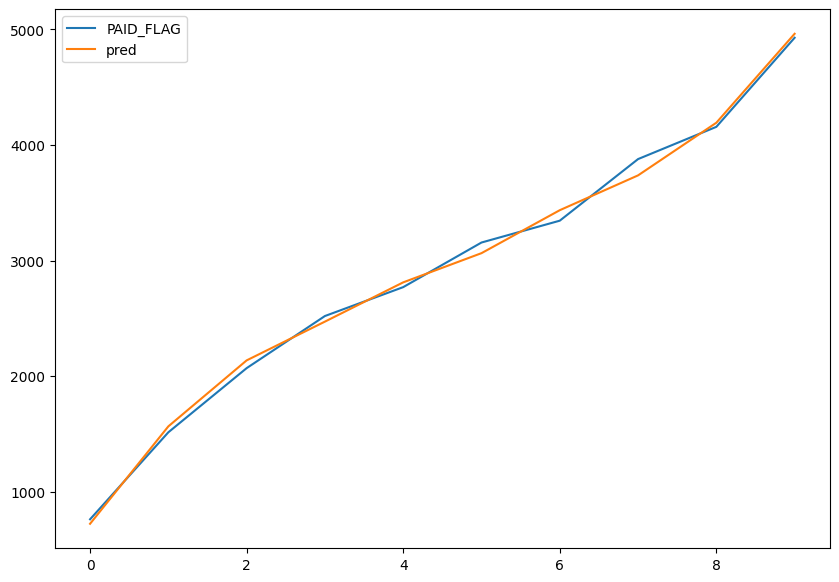

In [58]:
plt.figure(figsize=(10,7))
plt.plot(res['PAID_FLAG'], label='PAID_FLAG')
plt.plot(res['pred'], label='pred')
plt.legend()
plt.show()

In [59]:
df_test['pred_bins'] = pd.qcut(df_test['pred'], 10)
res = df_test.groupby(['pred_bins'])[['PAID_FLAG', 'pred']].sum().reset_index()
res

C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\713839917.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['pred_bins'] = pd.qcut(df_test['pred'], 10)
C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\713839917.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = df_test.groupby(['pred_bins'])[['PAID_FLAG', 'pred']].sum().reset_index()


,pred_bins,PAID_FLAG,pred
0,"(0.008560000000000002, 0.168]",158,156.934121
1,"(0.168, 0.255]",399,379.352336
2,"(0.255, 0.326]",484,518.325061
3,"(0.326, 0.374]",636,611.950113
4,"(0.374, 0.409]",629,679.528355
5,"(0.409, 0.456]",782,744.272680
6,"(0.456, 0.496]",848,832.421508
7,"(0.496, 0.542]",932,907.243488
8,"(0.542, 0.62]",1033,992.207719
9,"(0.62, 0.9]",1173,1179.379678


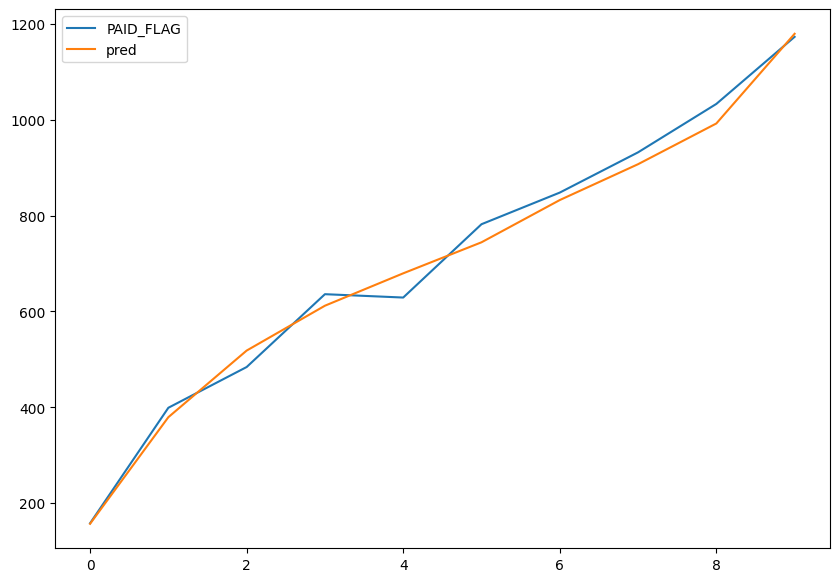

In [60]:
plt.figure(figsize=(10,7))
plt.plot(res['PAID_FLAG'], label='PAID_FLAG')
plt.plot(res['pred'], label='pred')
plt.legend()
plt.show()

In [54]:
df_nalozh['pred_1']=model.predict(df_nalozh[fact].astype(float))
print(df_nalozh['pred_1'].isna().sum())
# Удаляем...
df_nalozh = df_nalozh.dropna(subset=['pred_1']).reset_index(drop=True)

print(sum(df_nalozh['PAID_FLAG']), sum(df_nalozh['pred_1']))

13
59256 249482.1329276344


In [53]:
df_nalozh.shape

(717306, 149)

In [43]:
df_nalozh.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,OKVED_GROUP_3,INSURANT_REGION_GROUP_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_-1_0,PRICE_LEVEL_NUM_FOR_FREQ_5_6,PRICE_LEVEL_NUM_FOR_FREQ_7_8_9,PRICE_LEVEL_NUM_FOR_FREQ_-1_0_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_5_6_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_7_8_9_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_1_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_4_Moskva&obl
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,False,False,False
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,False,False,False
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,False,False,False
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-3,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,False,False,False
4,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-5,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,False,False,False


In [54]:
df_nalozh[df_nalozh['POLICY_NUMBER']=='008DR4580000051-3']

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,INSURANT_REGION_GROUP_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_-1_0,PRICE_LEVEL_NUM_FOR_FREQ_5_6,PRICE_LEVEL_NUM_FOR_FREQ_7_8_9,PRICE_LEVEL_NUM_FOR_FREQ_-1_0_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_5_6_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_7_8_9_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_1_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_4_Moskva&obl,pred_1
179462,45-Set'1,Heliks,008DR4580000051,AGT,008DR4580000045,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,...,True,False,False,False,False,False,False,False,False,0.633983
179465,1721-Set'1,Poliklinika.ru,008DR4580000051,AGT,008DR4580000045,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,...,True,False,False,False,False,False,False,False,False,0.633983
179468,731-Set'1,MedlajN-Servis,008DR4580000051,AGT,008DR4580000045,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,...,True,False,False,False,False,False,False,False,False,0.633983
179469,45-Set'1,Heliks,008DR4580000051,AGT,008DR4580000045,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,...,True,False,False,False,False,False,False,False,False,0.633983
179473,1221-Set'1,Doktor rjadom,008DR4580000051,AGT,008DR4580000045,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,...,True,False,False,False,False,False,False,False,False,0.633983
179474,826-Set'1,FGBU «NMITs TPM» Minzdrava Rossii,008DR4580000051,AGT,008DR4580000045,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,...,True,False,False,False,False,False,False,False,False,0.633983
179475,77-060-05,KDTs Medsi v Mar'ino (KDTsM),008DR4580000051,AGT,008DR4580000045,"OOO ""KOMMUNIKATsIONNAJa GRUPPA AGT""",008DR4580000051-3,2024-04-04 00:00:00,2025-04-03 23:59:59,2024-04-04 00:00:00,...,True,False,False,False,False,False,False,False,False,0.633983


In [55]:
# На тесте (аналогично)
y_true_test = df_test['PAID_FLAG']
y_pred_test = df_test['pred']

valid_mask_test = (~y_true_test.isna()) & (~y_pred_test.isna())
auc_test = roc_auc_score(y_true_test[valid_mask_test], y_pred_test[valid_mask_test])
gini_test = 2 * auc_test - 1

print(f"Gini (test): {gini_test:.4f}")


Gini (test): 0.4040


C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\713839917.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['pred_bins'] = pd.qcut(df_test['pred'], 10)
C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\713839917.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = df_test.groupby(['pred_bins'])[['PAID_FLAG', 'pred']].sum().reset_index()


,pred_bins,PAID_FLAG,pred
0,"(0.008560000000000002, 0.168]",158,156.934121
1,"(0.168, 0.255]",399,379.352336
2,"(0.255, 0.326]",484,518.325061
3,"(0.326, 0.374]",636,611.950113
4,"(0.374, 0.409]",629,679.528355
5,"(0.409, 0.456]",782,744.272680
6,"(0.456, 0.496]",848,832.421508
7,"(0.496, 0.542]",932,907.243488
8,"(0.542, 0.62]",1033,992.207719
9,"(0.62, 0.9]",1173,1179.379678


In [1130]:
# result = (
#     data_combined_0.groupby(['DOGOVOR_NUMBER_POLICY'])[['pred', 'PAID_FLAG']]
#     .sum()
#     .sort_values('PAID_FLAG', ascending=False)
#     #.head(200)
# )

# #print("DOGOVOR_NUMBER_POLICY по сумме PAID_FLAG (по убыванию):")
# #print(result)

# result.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\test_nalozh_freq_контракт.xlsx')

In [60]:
import pandas as pd

# Добавляем метку источника
df_train = df_train.copy()  # хорошая практика
df_test = df_test.copy()

df_train['dataset'] = 'train'
df_test['dataset'] = 'test'

# Объединяем таблицы
data_combined_0 = pd.concat([df_train, df_test], ignore_index=True)

# Проверка
print("Размер объединённой таблицы:", data_combined_0.shape)
print("Количество по датасетам:")
print(data_combined_0['dataset'].value_counts())

Размер объединённой таблицы: (92897, 178)
Количество по датасетам:
dataset
train    75532
test     17365
Name: count, dtype: int64


In [ ]:
# # Создаём новый датафрейм с нужными столбцами
# selected_columns = data_combined_0[['POLICY_NUMBER', 'pred']].copy()

In [61]:
df_nalozh_freq = df_nalozh[['GROUP (KOD SETI/LPU)' , 'DOGOVOR_NUMBER_POLICY', 'POLICY_NUMBER', 'FOLD', 'pred_1', 'PAID_FLAG', 'SUM_PRICE_TO_PAY']].copy()

In [59]:
df_nalozh.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,INSURANT_REGION_GROUP_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_-1_0,PRICE_LEVEL_NUM_FOR_FREQ_5_6,PRICE_LEVEL_NUM_FOR_FREQ_7_8_9,PRICE_LEVEL_NUM_FOR_FREQ_-1_0_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_5_6_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_7_8_9_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_1_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_4_Moskva&obl,pred_1
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,False,False,0.492691
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,False,False,0.492691
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,False,False,0.492691
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-3,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,False,False,0.492691
4,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-5,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,False,False,0.492691


In [ ]:
filtered = df_nalozh_freq[df_nalozh_freq['DOGOVOR_NUMBER_POLICY'] == '008DT4580000044']

# filtered 


In [115]:
data_combined_0.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\df_nalozh_freq.xlsx', index=False)

In [ ]:
#df_nalozh_freq.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\df_nalozh_freq.xlsx', index=False)

## Модель средней выплаты в основное ЛПУ

In [ ]:
df.head()

,Unnamed: 0,DOGOVOR_NUMBER_POLICY,HOLDING,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,...,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sredstv_bin,spark_Sootnoshenie sovokupnogo dolga k EBIT_bin,spark_Rentabelnost capitala (ROE)_bin,spark_Coeff tekushei liqvidnosti_bin,spark_Coeff bistroi liqvidnosti_bin,CNT_PROGRAM/cnt_policy_beg_BIN,CNT_PROGRAM/cnt_policy_beg_BIN_v,const,0-0.2_INSURED_EXP_NEW,>0.2_INSURED_EXP_NEW
0,0,008BS4581005347,KAMEN'TORG,"OOO ""KAMLIT""",Ju,008BS4581005347-6,2023-10-02 00:00:00,2024-10-01 23:59:59,2023-10-02 00:00:00,2024-10-01 23:59:59,...,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sred...,spark_Sootnoshenie sovokupnogo dolga k EBIT_11...,spark_Rentabelnost capitala (ROE)_-240_0,spark_Coeff tekushei liqvidnosti_1_1,spark_Coeff bistroi liqvidnosti_0_0,"[0.05, 0.1)",2,1,0.2,1.0
1,1,008BS4581005347,KAMEN'TORG,"OOO ""KAMLIT""",Ju,008BS4581005347-11,2023-10-02 00:00:00,2024-10-01 23:59:59,2023-10-02 00:00:00,2024-10-01 23:59:59,...,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sred...,spark_Sootnoshenie sovokupnogo dolga k EBIT_11...,spark_Rentabelnost capitala (ROE)_-240_0,spark_Coeff tekushei liqvidnosti_1_1,spark_Coeff bistroi liqvidnosti_0_0,"[0.05, 0.1)",2,1,0.2,1.0
2,2,008BS4581005347,KAMEN'TORG,"OOO ""KAMLIT""",Ju,008BS4581005347-12,2023-10-02 00:00:00,2024-10-01 23:59:59,2023-10-02 00:00:00,2024-10-01 23:59:59,...,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sred...,spark_Sootnoshenie sovokupnogo dolga k EBIT_11...,spark_Rentabelnost capitala (ROE)_-240_0,spark_Coeff tekushei liqvidnosti_1_1,spark_Coeff bistroi liqvidnosti_0_0,"[0.05, 0.1)",2,1,0.2,1.0
3,3,008BS4581005347,KAMEN'TORG,"OOO ""KAMLIT""",Ju,008BS4581005347-15,2023-10-02 00:00:00,2024-10-01 23:59:59,2023-10-02 00:00:00,2024-10-01 23:59:59,...,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sred...,spark_Sootnoshenie sovokupnogo dolga k EBIT_11...,spark_Rentabelnost capitala (ROE)_-240_0,spark_Coeff tekushei liqvidnosti_1_1,spark_Coeff bistroi liqvidnosti_0_0,"[0.05, 0.1)",2,1,0.2,1.0
4,4,008BS4581005347,KAMEN'TORG,"OOO ""KAMLIT""",Ju,008BS4581005347-17,2023-10-02 00:00:00,2024-10-01 23:59:59,2023-10-02 00:00:00,2024-10-01 23:59:59,...,spark_Coeff_sootnoshenie_zaemnii_i_sobstv_sred...,spark_Sootnoshenie sovokupnogo dolga k EBIT_11...,spark_Rentabelnost capitala (ROE)_-240_0,spark_Coeff tekushei liqvidnosti_1_1,spark_Coeff bistroi liqvidnosti_0_0,"[0.05, 0.1)",2,1,0.2,1.0


In [61]:
df[['SUM_PRICE_TO_PAY', 'PAID_FLAG', 'SUM_PRICE_TO_PAY_0']].sum()

SUM_PRICE_TO_PAY      8.669206e+08
PAID_FLAG             3.617200e+04
SUM_PRICE_TO_PAY_0    1.591496e+08
dtype: float64

In [62]:
def create_variate(a):
    if a <= 0.1:
        return a
    else:
        return 0.1

# Применяем функцию к столбцу 
df['0-0.1_INSURED_EXP_NEW'] = df['INSURED_EXP_NEW'].apply(create_variate)


def create_variate(a):
    if a <= 0.1:
        return a
    else:
        return 0.1

# Применяем функцию к столбцу 
df_main['0-0.1_INSURED_EXP_NEW'] = df_main['INSURED_EXP_NEW'].apply(create_variate)

In [63]:
def create_variate(a):
    if a > 0.1:
        return a
    else:
        return 0.1

# Применяем функцию к столбцу 
df['>0.1_INSURED_EXP_NEW'] = df['INSURED_EXP_NEW'].apply(create_variate)


def create_variate(a):
    if a > 0.1:
        return a
    else:
        return 0.1

# Применяем функцию к столбцу 
df_main['>0.1_INSURED_EXP_NEW'] = df_main['INSURED_EXP_NEW'].apply(create_variate)

In [64]:
def create_variate(a):
    if a <= 0.12:
        return a
    else:
        return 0.12

# Применяем функцию к столбцу 
df['0-0.12_INSURED_EXP_NEW'] = df['INSURED_EXP_NEW'].apply(create_variate)


def create_variate(a):
    if a <= 0.12:
        return a
    else:
        return 0.12

# Применяем функцию к столбцу 
df_main['0-0.12_INSURED_EXP_NEW'] = df_main['INSURED_EXP_NEW'].apply(create_variate)

In [65]:
def create_variate(a):
    if a > 0.12:
        return a
    else:
        return 0.12

# Применяем функцию к столбцу 
df['>0.12_INSURED_EXP_NEW'] = df['INSURED_EXP_NEW'].apply(create_variate)


def create_variate(a):
    if a > 0.12:
        return a
    else:
        return 0.12

# Применяем функцию к столбцу 
df_main['>0.12_INSURED_EXP_NEW'] = df_main['INSURED_EXP_NEW'].apply(create_variate)

In [66]:
features_cont=['const', 'RELATIVE', 'VIP']   

features_cat=[
 'COVENANTA_ZHUD',
 'ASSISTANCE_TYPE',
 'OKVED_GROUP',
 'PROLONGATION_TYPE',
 'REGION ITOG_GROUP',
 'spark_Tax_type',
 'PRICE_LEVEL_NUM',
 'PRICE_LEVEL_NUM_FOR_FREQ'
]


features_v = [ 
'0-0.1_INSURED_EXP_NEW',
'>0.1_INSURED_EXP_NEW'
 ]

features_v_2 = [ 
'0-0.12_INSURED_EXP_NEW',
'>0.12_INSURED_EXP_NEW'
 ]

# for nalozh
feat_cat=[
 'ASSISTANCE_TYPE',
 'OKVED_GROUP',
 'PROLONGATION_TYPE',
 'REGION ITOG_GROUP',
 'spark_Tax_type',
 'PRICE_LEVEL_NUM',
 'PRICE_LEVEL_NUM_FOR_FREQ'
]


In [67]:
X_sev=pd.get_dummies(df, columns=features_cat)

In [68]:
X_sev_main=pd.get_dummies(df_main, columns=feat_cat)

In [69]:
X_sev=X_sev[(X_sev['SUM_PRICE_TO_PAY']>0)]
X_sev[['SUM_PRICE_TO_PAY', 'PAID_FLAG']].sum()

SUM_PRICE_TO_PAY    8.669773e+08
PAID_FLAG           3.617200e+04
dtype: float64

<Axes: xlabel='SUM_PRICE_TO_PAY', ylabel='Count'>

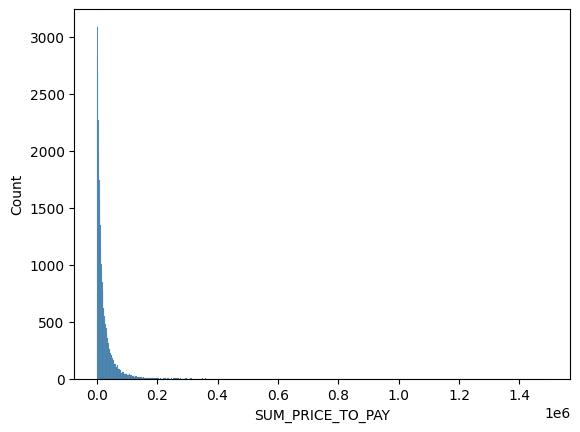

In [70]:
sns.histplot(X_sev['SUM_PRICE_TO_PAY']) 

In [71]:
X_sev.columns.to_list()

['Unnamed: 0',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'INSURANT_NAME',
 'INSURANT_TYPE',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'F_GENDER',
 'RELATIVE',
 'REGION',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_RAZDEL',
 'ORG_TYPE',
 'STAR',
 'REVIEWS',
 'BUS_DIST_MIN',
 'SUBWAY_DIST_MIN',
 'SUBWAY_SYNT',
 'GROUP (KOD SETI/LPU)',
 'GROUP name SETI/TOU',
 'REGION ITOG',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'CLINIC_RANK',
 'SUM_PAID_ALL',
 'PRICE_LEVEL',
 'COVENANTA',
 'COMISSION_PERCENTAGE_FIX',
 'PROGRAM_LIST_RISK_PREPAY_SPEC',
 'SUM_PRICE_TO_PAY_0',
 'PAID_FLAG',
 'YEAR',
 'spark_website',
 'spark_age_of_company',
 'spark_liquidation',
 'spark_form_of_ownership',
 'spark_public_sector',
 'spark_IDO',
 'spark_IF

In [72]:
factors_sev=[ 'const',
 'RELATIVE',
 'VIP',
 'COVENANTA_ZHUD_1',
 #'COVENANTA_noncovenant',
 #'COVENANTA_not_def',
 #'ASSISTANCE_TYPE_Posrednik RMS',
 'ASSISTANCE_TYPE_Prjamoj dogovor SBS',
#  "OKVED_GROUP_Dejatel'nost' administrativnaja i soputstvujuschie dopolnitel'nye uslugi",
#  "OKVED_GROUP_Dejatel'nost' finansovaja i strahovaja",
#  "OKVED_GROUP_Dejatel'nost' gostinits i predprijatij obschestvennogo pitanija",
#  "OKVED_GROUP_Dejatel'nost' po operatsijam s nedvizhimym imuschestvom",
#  "OKVED_GROUP_Dejatel'nost' professional'naja, nauchnaja i tehnicheskaja",
#  "OKVED_GROUP_Dejatel'nost' v oblasti informatsii i svjazi",
#  "OKVED_GROUP_Dejatel'nost' v oblasti kul'tury, sporta, organizatsii dosuga i razvlechenij",
#  "OKVED_GROUP_Dejatel'nost' v oblasti zdravoohranenija i sotsial'nyh uslug",
#  'OKVED_GROUP_Dobycha poleznyh iskopaemyh',
#  "OKVED_GROUP_Gosudarstvennoe upravlenie i obespechenie voennoj bezopasnosti, sotsial'noe obespechenie",
#  'OKVED_GROUP_Obespechenie elektricheskoj energiej, gazom i parom, konditsionirovanie vozduha',
#  'OKVED_GROUP_Obrabatyvajuschie proizvodstva',
#  'OKVED_GROUP_Obrazovanie',
#  'OKVED_GROUP_Predostavlenie prochih vidov uslug',
#  "OKVED_GROUP_Sel'skoe, lesnoe hozjajstvo, ohota, rybolovstvo i rybovodstvo",
#  "OKVED_GROUP_Stroitel'stvo",
#  'OKVED_GROUP_Torgovlja optovaja i roznichnaja, remont avtotransportnyh sredstv i mototsiklov',
#  'OKVED_GROUP_Transportirovka i hranenie',
#  "OKVED_GROUP_Vodosnabzhenie, vodootvedenie, organizatsija sbora i utilizatsii othodov, dejatel'nost' po likvidatsii zagrjaznenij",
 'PROLONGATION_TYPE_Pervichnyj',
 #'PROLONGATION_TYPE_Prolongatsija',
 #'PROLONGATION_TYPE_not_def',
 'REGION ITOG_GROUP_MOSKVA I MO',
 #'REGION ITOG_GROUP_PROCHEE',
 'REGION ITOG_GROUP_SPB I LO',
 'spark_Tax_type_AUSN',
 #'spark_Tax_type_ESHN',
 'spark_Tax_type_USN',
 #'spark_Tax_type_USN, AUSN',
 #'spark_Tax_type_not_def',
 #'PRICE_LEVEL_NUM_-1',
 #'PRICE_LEVEL_NUM_0',
 'PRICE_LEVEL_NUM_1_2',
 'PRICE_LEVEL_NUM_3',
 'PRICE_LEVEL_NUM_4_5',
 'PRICE_LEVEL_NUM_6',
 'PRICE_LEVEL_NUM_7_8_9',
 'OKVED_GROUP_1', 
 #'OKVED_GROUP_2',
 'OKVED_GROUP_3'
            ]

In [73]:
X_sev['PRICE_LEVEL_NUM_1_2'] =X_sev['PRICE_LEVEL_NUM_1']+X_sev['PRICE_LEVEL_NUM_2']
X_sev['PRICE_LEVEL_NUM_4_5'] =X_sev['PRICE_LEVEL_NUM_4']+X_sev['PRICE_LEVEL_NUM_5']
X_sev['PRICE_LEVEL_NUM_7_8_9'] =X_sev['PRICE_LEVEL_NUM_7']+X_sev['PRICE_LEVEL_NUM_8']+X_sev['PRICE_LEVEL_NUM_9']

X_sev['OKVED_GROUP_1']=X_sev["OKVED_GROUP_Gosudarstvennoe upravlenie i obespechenie voennoj bezopasnosti, sotsial'noe obespechenie"]+X_sev["OKVED_GROUP_Sel'skoe, lesnoe hozjajstvo, ohota, rybolovstvo i rybovodstvo"]
X_sev['OKVED_GROUP_2']=X_sev["OKVED_GROUP_Obespechenie elektricheskoj energiej, gazom i parom, konditsionirovanie vozduha"]+X_sev["OKVED_GROUP_Obrabatyvajuschie proizvodstva"]+X_sev["OKVED_GROUP_Stroitel'stvo"]
X_sev['OKVED_GROUP_3']=X_sev["OKVED_GROUP_Dejatel'nost' administrativnaja i soputstvujuschie dopolnitel'nye uslugi"]+X_sev[ "OKVED_GROUP_Dejatel'nost' finansovaja i strahovaja"]+X_sev["OKVED_GROUP_Dejatel'nost' po operatsijam s nedvizhimym imuschestvom"]+\
X_sev["OKVED_GROUP_Dejatel'nost' professional'naja, nauchnaja i tehnicheskaja"]+X_sev[ "OKVED_GROUP_Dejatel'nost' v oblasti zdravoohranenija i sotsial'nyh uslug"]+X_sev["OKVED_GROUP_Dobycha poleznyh iskopaemyh"]+X_sev['OKVED_GROUP_Predostavlenie prochih vidov uslug']
 

In [74]:
X_sev_main['PRICE_LEVEL_NUM_1_2'] =X_sev_main['PRICE_LEVEL_NUM_1']+X_sev_main['PRICE_LEVEL_NUM_2']
X_sev_main['PRICE_LEVEL_NUM_4_5'] =X_sev_main['PRICE_LEVEL_NUM_4']+X_sev_main['PRICE_LEVEL_NUM_5']
X_sev_main['PRICE_LEVEL_NUM_7_8_9'] =X_sev_main['PRICE_LEVEL_NUM_7']+X_sev_main['PRICE_LEVEL_NUM_8']+X_sev_main['PRICE_LEVEL_NUM_9']

X_sev_main['OKVED_GROUP_1']=X_sev_main["OKVED_GROUP_Gosudarstvennoe upravlenie i obespechenie voennoj bezopasnosti, sotsial'noe obespechenie"]+X_sev_main["OKVED_GROUP_Sel'skoe, lesnoe hozjajstvo, ohota, rybolovstvo i rybovodstvo"]
X_sev_main['OKVED_GROUP_2']=X_sev_main["OKVED_GROUP_Obespechenie elektricheskoj energiej, gazom i parom, konditsionirovanie vozduha"]+X_sev_main["OKVED_GROUP_Obrabatyvajuschie proizvodstva"]+X_sev_main["OKVED_GROUP_Stroitel'stvo"]
X_sev_main['OKVED_GROUP_3']=X_sev_main["OKVED_GROUP_Dejatel'nost' administrativnaja i soputstvujuschie dopolnitel'nye uslugi"]+X_sev_main[ "OKVED_GROUP_Dejatel'nost' finansovaja i strahovaja"]+X_sev_main["OKVED_GROUP_Dejatel'nost' po operatsijam s nedvizhimym imuschestvom"]+\
X_sev_main["OKVED_GROUP_Dejatel'nost' professional'naja, nauchnaja i tehnicheskaja"]+X_sev_main[ "OKVED_GROUP_Dejatel'nost' v oblasti zdravoohranenija i sotsial'nyh uslug"]+X_sev_main["OKVED_GROUP_Dobycha poleznyh iskopaemyh"]+X_sev_main['OKVED_GROUP_Predostavlenie prochih vidov uslug']
 

In [75]:
X_sev_main.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_RAZDEL,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply,SHARE_PRICE_LPU_FROM_MAX_v,SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV,pred,pred_norm,final_pred,spark_Zalog,CNT_PROGRAM/cnt_policy_beg_BIN_v,0-0.2_INSURED_EXP_NEW,>0.2_INSURED_EXP_NEW,0-0.1_INSURED_EXP_NEW,>0.1_INSURED_EXP_NEW,0-0.12_INSURED_EXP_NEW,>0.12_INSURED_EXP_NEW,ASSISTANCE_TYPE_Posrednik RMS,ASSISTANCE_TYPE_Prjamoj dogovor SBS,ASSISTANCE_TYPE_not_def,OKVED_GROUP_Dejatel'nost' administrativnaja i soputstvujuschie dopolnitel'nye uslugi,OKVED_GROUP_Dejatel'nost' finansovaja i strahovaja,OKVED_GROUP_Dejatel'nost' gostinits i predprijatij obschestvennogo pitanija,OKVED_GROUP_Dejatel'nost' po operatsijam s nedvizhimym imuschestvom,"OKVED_GROUP_Dejatel'nost' professional'naja, nauchnaja i tehnicheskaja",OKVED_GROUP_Dejatel'nost' v oblasti informatsii i svjazi,"OKVED_GROUP_Dejatel'nost' v oblasti kul'tury, sporta, organizatsii dosuga i razvlechenij",OKVED_GROUP_Dejatel'nost' v oblasti zdravoohranenija i sotsial'nyh uslug,OKVED_GROUP_Dobycha poleznyh iskopaemyh,"OKVED_GROUP_Gosudarstvennoe upravlenie i obespechenie voennoj bezopasnosti, sotsial'noe obespechenie","OKVED_GROUP_Obespechenie elektricheskoj energiej, gazom i parom, konditsionirovanie vozduha",OKVED_GROUP_Obrabatyvajuschie proizvodstva,OKVED_GROUP_Obrazovanie,OKVED_GROUP_Predostavlenie prochih vidov uslug,"OKVED_GROUP_Sel'skoe, lesnoe hozjajstvo, ohota, rybolovstvo i rybovodstvo",OKVED_GROUP_Stroitel'stvo,"OKVED_GROUP_Torgovlja optovaja i roznichnaja, remont avtotransportnyh sredstv i mototsiklov",OKVED_GROUP_Transportirovka i hranenie,"OKVED_GROUP_Vodosnabzhenie, vodootvedenie, organizatsija sbora i utilizatsii othodov, dejatel'nost' po likvidatsii zagrjaznenij",PROLONGATION_TYPE_Pervichnyj,PROLONGATION_TYPE_Prolongatsija,PROLONGATION_TYPE_not_def,REGION ITOG_GROUP_MOSKVA I MO,REGION ITOG_GROUP_PROCHEE,REGION ITOG_GROUP_SPB I LO,spark_Tax_type_AUSN,spark_Tax_type_ESHN,spark_Tax_type_USN,"spark_Tax_type_USN, AUSN",spark_Tax_type_not_def,PRICE_LEVEL_NUM_-1,PRICE_LEVEL_NUM_0,PRICE_LEVEL_NUM_1,PRICE_LEVEL_NUM_2,PRICE_LEVEL_NUM_3,PRICE_LEVEL_NUM_4,PRICE_LEVEL_NUM_5,PRICE_LEVEL_NUM_6,PRICE_LEVEL_NUM_7,PRICE_LEVEL_NUM_8,PRICE_LEVEL_NUM_9,PRICE_LEVEL_NUM_FOR_FREQ_-1.0,PRICE_LEVEL_NUM_FOR_FREQ_0.0,PRICE_LEVEL_NUM_FOR_FREQ_1.0,PRICE_LEVEL_NUM_FOR_FREQ_2.0,PRICE_LEVEL_NUM_FOR_FREQ_3.0,PRICE_LEVEL_NUM_FOR_FREQ_4.0,PRICE_LEVEL_NUM_FOR_FREQ_5.0,PRICE_LEVEL_NUM_FOR_FREQ_6.0,PRICE_LEVEL_NUM_FOR_FREQ_7.0,PRICE_LEVEL_NUM_FOR_FREQ_8.0,PRICE_LEVEL_NUM_FOR_FREQ_9.0,PRICE_LEVEL_NUM_1_2,PRICE_LEVEL_NUM_4_5,PRICE_LEVEL_NUM_7_8_9,OKVED

In [76]:
fact_sev=factors_sev+features_v

In [77]:
# Преобразуем матрицу в таблицу пар
corr_matrix = X_sev[fact_sev].corr()  # или df[fact].corr(), в зависимости от имени датафрейма


corr_pairs = (
    corr_matrix
    .where(corr_matrix.abs() > 0.5)  # только |r| > 0.5
    .stack()  # в виде пар (col1, col2): corr
)

# Убираем дубли (A-B и B-A) и диагональ (A-A)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs.drop_duplicates()

# Создаём DataFrame
high_corr_df = pd.DataFrame(corr_pairs, columns=['Корреляция']).reset_index()
high_corr_df.columns = ['Признак_1', 'Признак_2', 'Корреляция']
high_corr_df = high_corr_df.sort_values(by='Корреляция', key=abs, ascending=False).reset_index(drop=True)

# Показываем
print("Сильно скоррелированные пары (|r| > 0.5):")
print(high_corr_df)

Сильно скоррелированные пары (|r| > 0.5):
Empty DataFrame
Columns: [Признак_1, Признак_2, Корреляция]
Index: []


In [78]:
from sklearn.model_selection import train_test_split


train_sev = X_sev[X_sev['FOLD'].isin([1, 2, 3, 4])]
test_sev = X_sev[X_sev['FOLD'].isin([5])]

# разделение данных на признаки и целевую переменную
X_sev_tr = train_sev.drop(['FOLD', 'PAID_FLAG'], axis=1)
y_train = train_sev['PAID_FLAG']
X_sev_test = test_sev.drop(['FOLD', 'PAID_FLAG'], axis=1)
y_test = test_sev['PAID_FLAG']

In [79]:
X_sev_tr['SUM_PRICE_TO_PAY'].sum()

686205041.2861371

In [80]:
X_sev_test['SUM_PRICE_TO_PAY'].sum()

180772223.85000306

In [81]:
model_sev_tr=sm.GLM(X_sev_tr['SUM_PRICE_TO_PAY'],\
                  X_sev_tr[fact_sev].astype(float), family=sm.families.Gamma(link=sm.families.links.log())).fit()

model_sev_tr.summary()

c:\Users\Sakinat.Ibragimova\.conda\envs\Sakinat\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:       SUM_PRICE_TO_PAY   No. Observations:                29098
Model:                            GLM   Df Residuals:                    29079
Model Family:                   Gamma   Df Model:                           18
Link Function:                    log   Scale:                          1.3382
Method:                          IRLS   Log-Likelihood:            -3.1882e+05
Date:                Fri, 17 Jul 2026   Deviance:                       31172.
Time:                        10:26:13   Pearson chi2:                 3.89e+04
No. Iterations:                    15   Pseudo R-squ. (CS):             0.1976
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                   7.8284      0.157     49.939      0.000       7.521       8.136
RELATIVE                                0.2146      0.070      3.069      0.002       0.078       0.352
VIP                                     0.2377      0.021     11.104      0.000       0.196       0.280
COVENANTA_ZHUD_1                       -0.0818      0.016     -5.255      0.000      -0.112      -0.051
ASSISTANCE_TYPE_Prjamoj dogovor SBS     0.1196      0.018      6.487      0.000       0.083       0.156
PROLONGATION_TYPE_Pervichnyj            0.0866      0.016      5.273      0.000       0.054       0.119
REGION ITOG_GROUP_MOSKVA I MO           0.8398      0.016     51.674      0.000       0.808       0.872
REGION ITOG_GROUP_SPB I LO              0.2665      0.022     12.017      0.000       0.223       0.310
spark_Tax_type_AUSN                     0.5080      0.094      5.386      0.000       0.323       0.693
spark_Tax_type_USN                      0.1299      0.019      6.849      0.000       0.093       0.167
PRICE_LEVEL_NUM_1_2                    -0.4301      0.020    -21.260      0.000      -0.470      -0.390
PRICE_LEVEL_NUM_3                      -0.1065      0.023     -4.641      0.000      -0.151      -0.062
PRICE_LEVEL_NUM_4_5                     0.1761      0.026      6.754      0.000       0.125       0.227
PRICE_LEVEL_NUM_6                       0.4117      0.044      9.275      0.000       0.325       0.499
PRICE_LEVEL_NUM_7_8_9                   0.9955      0.069     14.334      0.000       0.859       1.132
OKVED_GROUP_1                          -0.1305      0.043     -3.023      0.003      -0.215      -0.046
OKVED_GROUP_3                           0.0612      0.017      3.696      0.000       0.029       0.094
0-0.1_INSURED_EXP_NEW                  12.9331      1.606      8.053      0.000       9.785      16.081
>0.1_INSURED_EXP_NEW                    0.5447      0.030     18.399      0.000       0.487       0.603
=======================================================================================================
"""

In [82]:
gamma2_tr= sm.GLM(X_sev_tr['SUM_PRICE_TO_PAY'], X_sev_tr[fact_sev].astype(float), family=sm.families.Gamma(link=sm.families.links.log())).fit()

c:\Users\Sakinat.Ibragimova\.conda\envs\Sakinat\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [83]:
X_sev_tr['sev_pred']=gamma2_tr.predict(X_sev_tr[fact_sev].astype(float))
print((X_sev_tr['SUM_PRICE_TO_PAY']).sum(), X_sev_tr['sev_pred'].sum())
from sklearn.metrics import r2_score
r2_score(X_sev_tr['SUM_PRICE_TO_PAY'], X_sev_tr['sev_pred'])

686205041.2861371 686877431.313972


0.16375642351628028

In [90]:
# # Фильтруем строки по номеру договора
# mask = X_sev_tr['DOGOVOR_NUMBER_POLICY'] == '008DT4580000044'
# filtered = X_sev_tr[mask]

# # Выводим суммы PAID_FLAG и pred
# print(sum(filtered['SUM_PRICE_TO_PAY']), sum(filtered['sev_pred']))
# #filtered.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\check_sev_008DT4580000044.xlsx')


In [91]:
X_sev_test['sev_pred']=gamma2_tr.predict(X_sev_test[fact_sev].astype(float))

In [92]:
(X_sev_test['SUM_PRICE_TO_PAY']).sum(), X_sev_test['sev_pred'].sum()
print((X_sev_test['SUM_PRICE_TO_PAY']).sum(), X_sev_test['sev_pred'].sum())

      
r2_score(X_sev_test['SUM_PRICE_TO_PAY'], X_sev_test['sev_pred'])

180772223.85000306 175626975.70704588


0.1790041687261742

In [93]:
X_sev_tr['pred_bins'] = pd.qcut(X_sev_tr['sev_pred'], 10)
res = X_sev_tr.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY', 'sev_pred']].sum().reset_index()
res

C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\2858464167.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = X_sev_tr.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY', 'sev_pred']].sum().reset_index()


,pred_bins,SUM_PRICE_TO_PAY,sev_pred
0,"(1962.858, 11435.589]",2.899679e+07,2.761065e+07
1,"(11435.589, 13121.695]",3.489756e+07,3.580095e+07
2,"(13121.695, 15467.945]",4.192359e+07,4.267469e+07
3,"(15467.945, 16854.819]",4.483783e+07,4.566063e+07
4,"(16854.819, 18055.045]",5.102018e+07,5.116590e+07
5,"(18055.045, 20840.976]",5.329070e+07,5.630564e+07
6,"(20840.976, 25287.057]",6.849161e+07,6.699756e+07
7,"(25287.057, 33266.443]",8.164082e+07,8.338831e+07
8,"(33266.443, 42530.45]",1.107354e+08,1.108738e+08
9,"(42530.45, 226464.513]",1.703706e+08,1.663993e+08


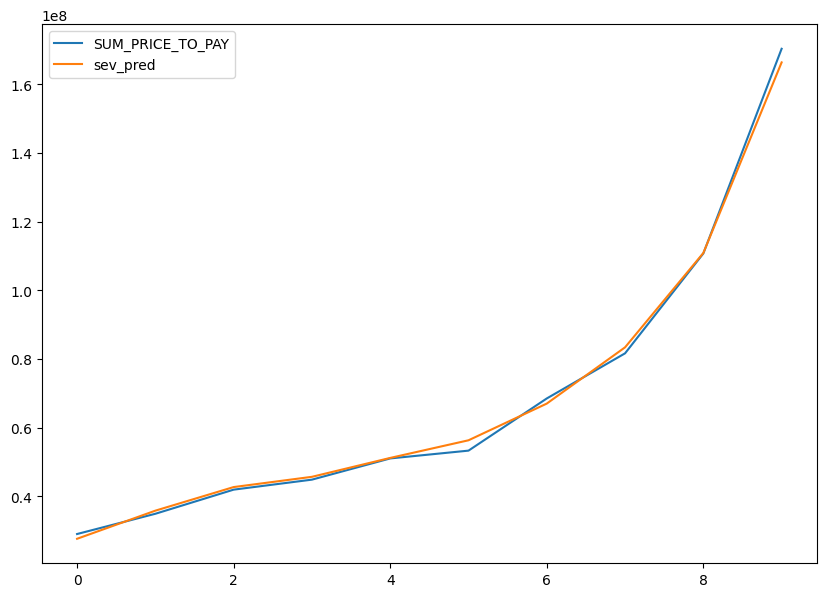

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(res['SUM_PRICE_TO_PAY'], label='SUM_PRICE_TO_PAY')
plt.plot(res['sev_pred'], label='sev_pred')
plt.legend()
plt.show()

In [96]:
X_sev_test['pred_bins'] = pd.qcut(X_sev_test['sev_pred'], 10)
res = X_sev_test.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY', 'sev_pred']].sum().reset_index()
res

C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\4126663971.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = X_sev_test.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY', 'sev_pred']].sum().reset_index()


,pred_bins,SUM_PRICE_TO_PAY,sev_pred
0,"(2212.16, 11503.708]",7.346751e+06,6.774442e+06
1,"(11503.708, 13843.595]",8.758109e+06,8.886509e+06
2,"(13843.595, 15854.997]",1.124898e+07,1.192122e+07
3,"(15854.997, 17432.524]",1.197360e+07,1.086732e+07
4,"(17432.524, 19851.47]",1.227814e+07,1.294770e+07
5,"(19851.47, 22535.839]",1.704335e+07,1.476265e+07
6,"(22535.839, 27181.426]",1.976617e+07,1.760477e+07
7,"(27181.426, 35091.826]",2.191197e+07,2.227479e+07
8,"(35091.826, 43326.628]",2.909680e+07,2.701628e+07
9,"(43326.628, 186598.437]",4.134836e+07,4.257130e+07


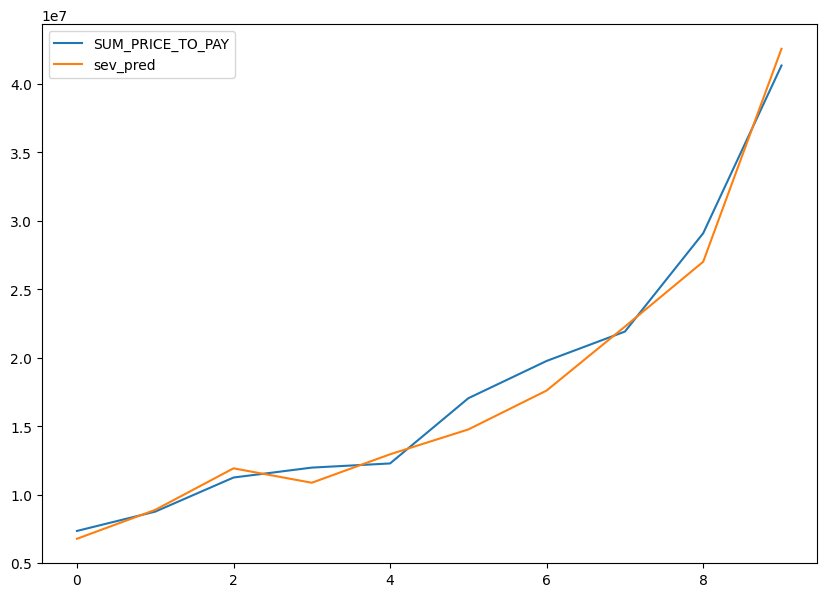

In [97]:
plt.figure(figsize=(10,7))
plt.plot(res['SUM_PRICE_TO_PAY'], label='SUM_PRICE_TO_PAY')
plt.plot(res['sev_pred'], label='sev_pred')
plt.legend()
plt.show()

In [86]:
X_sev_main['sev_pred']=model_sev_tr.predict(X_sev_main[fact_sev].astype(float))
print((X_sev_main['SUM_PRICE_TO_PAY']).sum(), X_sev_main['sev_pred'].sum())

1022304490.8260163 11481392510.042034


In [267]:
# print(X_sev_main[fact_sev].isna().sum())


In [84]:
X_sev_main.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,PRICE_LEVEL_NUM_FOR_FREQ_7.0,PRICE_LEVEL_NUM_FOR_FREQ_8.0,PRICE_LEVEL_NUM_FOR_FREQ_9.0,PRICE_LEVEL_NUM_1_2,PRICE_LEVEL_NUM_4_5,PRICE_LEVEL_NUM_7_8_9,OKVED_GROUP_1,OKVED_GROUP_2,OKVED_GROUP_3,sev_pred
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,True,False,False,False,True,False,14363.771406
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,True,False,False,False,True,False,12745.028959
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,True,False,19593.906624
3,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-3,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,True,False,False,False,True,False,12745.028959
4,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-5,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,...,False,False,False,False,False,False,False,True,False,19593.906624


In [88]:
X_sev_main['sev_pred'].isna().sum()

0

In [89]:
# Создаём новый датафрейм с нужными столбцами
X_sev_main_nalozh = X_sev_main[['GROUP (KOD SETI/LPU)' , 'DOGOVOR_NUMBER_POLICY',  'SERVICE_POINT_ID_NEW', 'POLICY_NUMBER', 'sev_pred']].copy()

# Просмотр результата
X_sev_main_nalozh.head()
#X_sev_main_nalozh.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\X_sev_main_nalozh.xlsx', index=False )

,GROUP (KOD SETI/LPU),DOGOVOR_NUMBER_POLICY,SERVICE_POINT_ID_NEW,POLICY_NUMBER,sev_pred
0,2494-Set'1,008BS4581005475,67FE2FFA-09A5-5D7F-E053-596510AC686B,008BS4581005475-9,14363.771406
1,2494-Set'1,008BS4581005475,NaN,008BS4581005475-6,12745.028959
2,845/Klinika Ekspert Tver'/69-744-01,008BS4581005475,NaN,008BS4581005475-7,19593.906624
3,2494-Set'1,008BS4581005475,NaN,008BS4581005475-3,12745.028959
4,845/Klinika Ekspert Tver'/69-744-01,008BS4581005475,NaN,008BS4581005475-5,19593.906624


In [350]:
df_main.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply,SHARE_PRICE_LPU_FROM_MAX_v,SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV,pred,pred_norm,final_pred,PRICE_LEVEL_NUM_FOR_FREQ,spark_Zalog,spark_Tax_type,CNT_PROGRAM/cnt_policy_beg_BIN_v,0-0.2_INSURED_EXP_NEW,>0.2_INSURED_EXP_NEW,0-0.1_INSURED_EXP_NEW,>0.1_INSURED_EXP_NEW,0-0.12_INSURED_EXP_NEW,>0.12_INSURED_EXP_NEW
0,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-9,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1,Pervichnyj,Tverskaja obl,Prochee,48,40-49,18-64,1.0,Stroitel'stvo,Razdel F,4.4,541,0.19,-1.0,0.0,0.0,0.0,1,TVERSKAJa,PROCHEE,Prjamoj dogovor SBS,800.0,1,67FE2FFA-09A5-5D7F-E053-596510AC686B,2,ECONOM,1,5793,2,Risk,15.0,noncovenant,1,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2,0.5,1,-1,0,1,0.14,0.5,0.96,level_2 (others),level_2 (others),14,level_1 (-1),44.0,5.0,0.10,0.69,False,True,True,False,0.0,0.0,0,0.0,0.291992,0.781465,0.373647,1.0,not_def,USN,3.0,0.2,1.0,0.1,1.0,0.12,1.0
1,2494-Set'1,Tsentromed,008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-6,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,Zh,1,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1,Pervichnyj,Tverskaja obl,Prochee,51,50-59,18-64,1.0,Stroitel'stvo,Razdel F,4.4,541,0.19,-1.0,0.0,0.0,0.0,1,NaN,NaN,not_def,0.0,0,NaN,0,ECONOM,1,5793,2,Risk,15.0,noncovenant,0,0.69,0.96,1.00,0.17,-1.0,0.0,0.0,0.0,3,2,0.5,1,-1,0,1,0.14,0.5,0.96,level_2 (others),level_2 (others),14,level_1 (-1),44.0,5.0,0.10,0.69,False,True,True,False,0.0,0.0,0,0.0,0.291992,0.781465,0.373647,1.0,not_def,USN,3.0,0.2,1.0,0.1,1.0,0.12,1.0
2,845/Klinika Ekspert Tver'/69-744-01,Klinika Ekspert Tver',008BS4581005475,BAZIS (TVERSKAJa OBLAST'),008BS4581005475,"OOO ""BAZIS""",008BS4581005475-7,2023-10-09 00:00:00,2024-10-08 23:59:59,2023-10-09 00:00:00,2024-10-08 23:59:59,367,0,0,2,15,0.13,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Tver',1,Pervichnyj,Tverskaja obl,Prochee,39,30-39,18-64,1.0,Stroitel'stvo,Razdel F,4.6,420,0.12,-1.0,0.0,0.0,0.0,1,NaN,NaN,not_def,0.0,0,NaN,0,Prochee,0,8433,1,Risk,15.0,noncovenant,0,1.00,1.00,0.78,0.11,-1.0,0.0,0.0,0.0,3,2,0.5,1,-1,0,1,0.14,0.5,1.00,level_2 (others),level_2 (others),14,level_1 (-1),82.0,16.0,0.18,1.00,False,True,True,False,0.0,0.0,0,0.0,0.489473,0.781465,0.626353,1.0,not_def,USN,3.0,0.2,1

In [90]:
X_sev_main_nalozh.shape

(717319, 5)

In [354]:
# X_sev_main_nalozh['pred_bins'] = pd.qcut(X_sev_main_nalozh['sev_pred'], 10)
# res = X_sev_main_nalozh.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY', 'sev_pred']].sum().reset_index()
# res

In [89]:
# X_sev_test[['SUM_PRICE_TO_PAY', 'sev_pred']]

<Axes: xlabel='SUM_PRICE_TO_PAY', ylabel='sev_pred'>

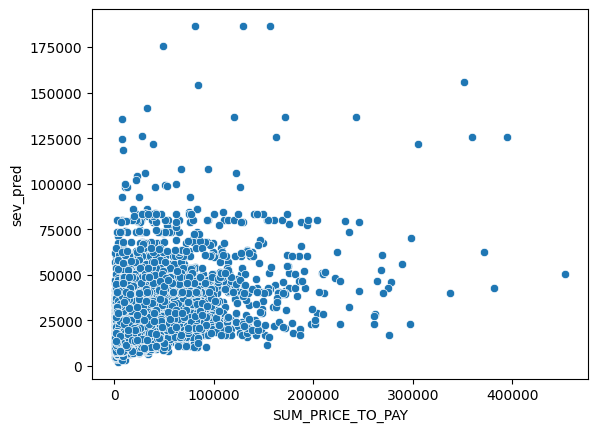

In [98]:
sns.scatterplot(x= X_sev_test['SUM_PRICE_TO_PAY'], y=X_sev_test['sev_pred']) 

In [91]:
import pandas as pd

# Добавляем метку источника
X_sev_tr = X_sev_tr.copy()  # хорошая практика
X_sev_test = X_sev_test.copy()

X_sev_tr['dataset'] = 'train'
X_sev_test['dataset'] = 'test'

# Объединяем таблицы
data_combined = pd.concat([X_sev_tr, X_sev_test], ignore_index=True)

# Проверка
print("Размер объединённой таблицы:", data_combined.shape)
print("Количество по датасетам:")
print(data_combined['dataset'].value_counts())

Размер объединённой таблицы: (36172, 187)
Количество по датасетам:
dataset
train    29098
test      7074
Name: count, dtype: int64


In [112]:
# result1 = (
#     data_combined.groupby(['DOGOVOR_NUMBER_POLICY'])[['sev_pred', 'SUM_PRICE_TO_PAY', 'SUM_PRICE_TO_PAY_0']]
#     .sum()
#     .sort_values('SUM_PRICE_TO_PAY', ascending=False)
#    # .head(20)
# )

data_combined.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\наложение_выплаты_в_осн_ЛПУ_контракт.xlsx')
# print("DOGOVOR_NUMBER_POLICY по сумме SUM_PRICE_TO_PAY (по убыванию):")
# print(result1)

In [1171]:
# # Создаём новый датафрейм с нужными столбцами
# selected_columns_2 = data_combined[['POLICY_NUMBER', 'sev_pred']].copy()

# # Просмотр результата
# print(selected_columns_2.head())


In [1172]:
# data_combined.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\выплаты_в_осн_ЛПУ.xlsx', index=False )

# Модель средней выплаты в неосновное ЛПУ

In [99]:
X_sev[['SUM_PRICE_TO_PAY_0', 'PAID_FLAG']].sum()

SUM_PRICE_TO_PAY_0    1.591653e+08
PAID_FLAG             3.617200e+04
dtype: float64

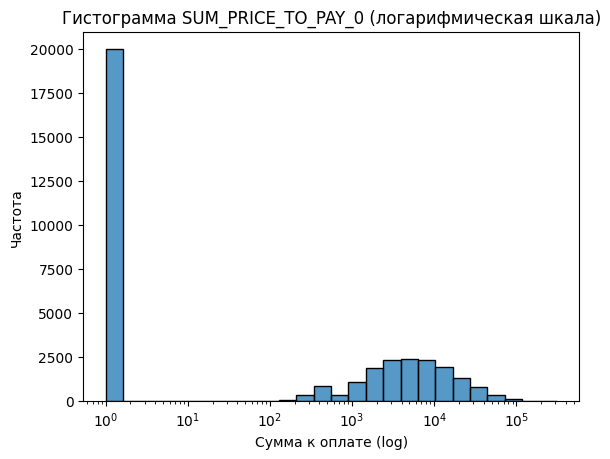

In [100]:
# Добавляем малое число, чтобы избежать log(0)
sns.histplot(X_sev['SUM_PRICE_TO_PAY_0'] + 1, log_scale=True)
plt.title('Гистограмма SUM_PRICE_TO_PAY_0 (логарифмическая шкала)')
plt.xlabel('Сумма к оплате (log)')
plt.ylabel('Частота')
plt.show()


In [101]:
X_sev_main.columns.to_list()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_RAZDEL',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_VALUE',
 'PRICE_CLINIC_RANK',
 'PROGRAM_LIST_RISK_PREPAY_SPEC',
 'COMISSION_PERCENTAGE_FIX',
 'COVENANTA',
 'PAID_FLAG',
 'SHARE_PRICE_LPU_FROM_MAX',
 'SHAR

In [102]:
factors_sev=[ 'const',
             'RELATIVE', 
             'VIP',
#'COVENANTA_covenant',
 #'COVENANTA_noncovenant',
 #'COVENANTA_not_def',
 #'ASSISTANCE_TYPE_Posrednik RMS',
 #'ASSISTANCE_TYPE_Prjamoj dogovor SBS',
#  "OKVED_GROUP_Dejatel'nost' administrativnaja i soputstvujuschie dopolnitel'nye uslugi",
#  "OKVED_GROUP_Dejatel'nost' finansovaja i strahovaja",
#  "OKVED_GROUP_Dejatel'nost' gostinits i predprijatij obschestvennogo pitanija",
#  "OKVED_GROUP_Dejatel'nost' po operatsijam s nedvizhimym imuschestvom",
#  "OKVED_GROUP_Dejatel'nost' professional'naja, nauchnaja i tehnicheskaja",
#  "OKVED_GROUP_Dejatel'nost' v oblasti informatsii i svjazi",
#  "OKVED_GROUP_Dejatel'nost' v oblasti kul'tury, sporta, organizatsii dosuga i razvlechenij",
#  "OKVED_GROUP_Dejatel'nost' v oblasti zdravoohranenija i sotsial'nyh uslug",
#  'OKVED_GROUP_Dobycha poleznyh iskopaemyh',
#  "OKVED_GROUP_Gosudarstvennoe upravlenie i obespechenie voennoj bezopasnosti, sotsial'noe obespechenie",
#  'OKVED_GROUP_Obespechenie elektricheskoj energiej, gazom i parom, konditsionirovanie vozduha',
#  'OKVED_GROUP_Obrabatyvajuschie proizvodstva',
#  'OKVED_GROUP_Obrazovanie',
#  'OKVED_GROUP_Predostavlenie prochih vidov uslug',
#  "OKVED_GROUP_Sel'skoe, lesnoe hozjajstvo, ohota, rybolovstvo i rybovodstvo",
#  "OKVED_GROUP_Stroitel'stvo",
#  'OKVED_GROUP_Torgovlja optovaja i roznichnaja, remont avtotransportnyh sredstv i mototsiklov',
#  'OKVED_GROUP_Transportirovka i hranenie',
#  "OKVED_GROUP_Vodosnabzhenie, vodootvedenie, organizatsija sbora i utilizatsii othodov, dejatel'nost' po likvidatsii zagrjaznenij",
# 'PROLONGATION_TYPE_Pervichnyj',
 #'PROLONGATION_TYPE_Prolongatsija',
 #'PROLONGATION_TYPE_not_def',
 'PROLONGATION_TYPE_Prolongatsija_not_def',
 'REGION ITOG_GROUP_MOSKVA I MO',
 #'REGION ITOG_GROUP_PROCHEE',
 'REGION ITOG_GROUP_SPB I LO',
#  'spark_Tax_type_AUSN',
#  #'spark_Tax_type_ESHN',
#  'spark_Tax_type_USN',
 #'spark_Tax_type_USN, AUSN',
 #'spark_Tax_type_not_def',
 #'PRICE_LEVEL_NUM_-1',
 #'PRICE_LEVEL_NUM_0',
 'PRICE_LEVEL_NUM_FOR_FREQ_1',
 'PRICE_LEVEL_NUM_FOR_FREQ_4',
 'PRICE_LEVEL_NUM_FOR_FREQ_5_6',
 'PRICE_LEVEL_NUM_FOR_FREQ_7_8_9',
 'OKVED_GROUP_1', 
 #'OKVED_GROUP_2',
 'OKVED_GROUP_3',
  'OKVED_GROUP_4',
 #  'OKVED_GROUP_6',
    'OKVED_GROUP_7'
            ]

In [103]:
X_sev['OKVED_GROUP_1']=X_sev["OKVED_GROUP_Sel'skoe, lesnoe hozjajstvo, ohota, rybolovstvo i rybovodstvo"]+X_sev['OKVED_GROUP_Dobycha poleznyh iskopaemyh']
X_sev['OKVED_GROUP_3']=X_sev["OKVED_GROUP_Dejatel'nost' v oblasti informatsii i svjazi"]+X_sev["OKVED_GROUP_Obrabatyvajuschie proizvodstva"]+X_sev["OKVED_GROUP_Dejatel'nost' v oblasti kul'tury, sporta, organizatsii dosuga i razvlechenij"]
X_sev['OKVED_GROUP_4']=X_sev["OKVED_GROUP_Stroitel'stvo"]+X_sev["OKVED_GROUP_Transportirovka i hranenie"]
#X_sev['OKVED_GROUP_6']=X_sev["OKVED_GROUP_Dejatel'nost' gostinits i predprijatij obschestvennogo pitanija"]+X_sev["OKVED_GROUP_Dejatel'nost' professional'naja, nauchnaja i tehnicheskaja"]+X_sev[ "OKVED_GROUP_Dejatel'nost' v oblasti zdravoohranenija i sotsial'nyh uslug"]
X_sev['OKVED_GROUP_7']=X_sev["OKVED_GROUP_Dejatel'nost' po operatsijam s nedvizhimym imuschestvom"]

X_sev['PRICE_LEVEL_NUM_FOR_FREQ_1'] =X_sev['PRICE_LEVEL_NUM_FOR_FREQ_1']
X_sev['PRICE_LEVEL_NUM_FOR_FREQ_4'] =X_sev['PRICE_LEVEL_NUM_FOR_FREQ_4']
X_sev['PRICE_LEVEL_NUM_FOR_FREQ_5_6'] =X_sev['PRICE_LEVEL_NUM_FOR_FREQ_5']+X_sev['PRICE_LEVEL_NUM_FOR_FREQ_6']
X_sev['PRICE_LEVEL_NUM_FOR_FREQ_7_8_9'] =X_sev['PRICE_LEVEL_NUM_FOR_FREQ_9']+X_sev['PRICE_LEVEL_NUM_FOR_FREQ_9']+X_sev['PRICE_LEVEL_NUM_FOR_FREQ_7']

X_sev['PROLONGATION_TYPE_Prolongatsija_not_def'] = X_sev['PROLONGATION_TYPE_Prolongatsija']+X_sev['PROLONGATION_TYPE_not_def']

In [104]:
X_sev_main['OKVED_GROUP_1']=X_sev_main["OKVED_GROUP_Sel'skoe, lesnoe hozjajstvo, ohota, rybolovstvo i rybovodstvo"]+X_sev_main['OKVED_GROUP_Dobycha poleznyh iskopaemyh']
X_sev_main['OKVED_GROUP_3']=X_sev_main["OKVED_GROUP_Dejatel'nost' v oblasti informatsii i svjazi"]+X_sev_main["OKVED_GROUP_Obrabatyvajuschie proizvodstva"]+X_sev_main["OKVED_GROUP_Dejatel'nost' v oblasti kul'tury, sporta, organizatsii dosuga i razvlechenij"]
X_sev_main['OKVED_GROUP_4']=X_sev_main["OKVED_GROUP_Stroitel'stvo"]+X_sev_main["OKVED_GROUP_Transportirovka i hranenie"]
#X_sev_main['OKVED_GROUP_6']=X_sev_main["OKVED_GROUP_Dejatel'nost' gostinits i predprijatij obschestvennogo pitanija"]+X_sev_main["OKVED_GROUP_Dejatel'nost' professional'naja, nauchnaja i tehnicheskaja"]+X_sev_main[ "OKVED_GROUP_Dejatel'nost' v oblasti zdravoohranenija i sotsial'nyh uslug"]
X_sev_main['OKVED_GROUP_7']=X_sev_main["OKVED_GROUP_Dejatel'nost' po operatsijam s nedvizhimym imuschestvom"]

X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_1'] =X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_1.0']
X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_4'] =X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_4.0']
X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_5_6'] =X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_5.0']+X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_6.0']
X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_7_8_9'] =X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_9.0']+X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_8.0']+X_sev_main['PRICE_LEVEL_NUM_FOR_FREQ_7.0']

X_sev_main['PROLONGATION_TYPE_Prolongatsija_not_def'] = X_sev_main['PROLONGATION_TYPE_Prolongatsija']+X_sev_main['PROLONGATION_TYPE_not_def']

In [105]:
fact_sev=factors_sev+features_v_2

In [106]:
from sklearn.model_selection import train_test_split


train_sev = X_sev[X_sev['FOLD'].isin([1, 2, 3, 4])]
test_sev = X_sev[X_sev['FOLD'].isin([5])]

# разделение данных на признаки и целевую переменную
X_sev_tr = train_sev.drop(['FOLD', 'PAID_FLAG'], axis=1)
y_train = train_sev['PAID_FLAG']
X_sev_test = test_sev.drop(['FOLD', 'PAID_FLAG'], axis=1)
y_test = test_sev['PAID_FLAG']

In [119]:
# model_sev_tr=sm.GLM(X_sev_tr['SUM_PRICE_TO_PAY_0'],\
#                   X_sev_tr[fact_sev].astype(float), family=sm.families.Gamma(link=sm.families.links.log())).fit()

# model_sev_tr.summary()

In [107]:
import statsmodels.api as sm
from statsmodels.genmod.families import Family
from statsmodels.genmod.families.links import log

# Подготовка данных
y = X_sev_tr['SUM_PRICE_TO_PAY_0']
X = X_sev_tr[fact_sev].astype(float)

# Добавляем константу
#X = sm.add_constant(X, has_constant='add')

# Указываем семейство Tweedie с ЛОГАРИФМИЧЕСКИМ link'ом
family = sm.families.Tweedie(var_power=1.5, link=sm.families.links.log())

# Обучаем модель
model_sev_tr = sm.GLM(
    y,
    X,
    family=family
).fit()

# Выводим результат
print(model_sev_tr.summary())




c:\Users\Sakinat.Ibragimova\.conda\envs\Sakinat\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:     SUM_PRICE_TO_PAY_0   No. Observations:                29098
Model:                            GLM   Df Residuals:                    29082
Model Family:                 Tweedie   Df Model:                           15
Link Function:                    log   Scale:                          339.83
Method:                          IRLS   Log-Likelihood:            -1.5318e+05
Date:                Fri, 17 Jul 2026   Deviance:                   6.3090e+06
Time:                        10:56:45   Pearson chi2:                 9.88e+06
No. Iterations:                    14   Pseudo R-squ. (CS):            0.04588
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [108]:
Tweedie_tr= sm.GLM(X_sev_tr['SUM_PRICE_TO_PAY_0'], X_sev_tr[fact_sev].astype(float), family=sm.families.Tweedie(link=sm.families.links.log())).fit()

c:\Users\Sakinat.Ibragimova\.conda\envs\Sakinat\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Sakinat.Ibragimova\.conda\envs\Sakinat\lib\site-packages\statsmodels\genmod\families\family.py:1650: RuntimeWarning: divide by zero encountered in log
  endog * np.log(endog / mu) + (mu - endog))
c:\Users\Sakinat.Ibragimova\.conda\envs\Sakinat\lib\site-packages\statsmodels\genmod\families\family.py:1650: RuntimeWarning: invalid value encountered in multiply
  endog * np.log(endog / mu) + (mu - endog))


In [109]:
X_sev_tr['sev_pred']=Tweedie_tr.predict(X_sev_tr[fact_sev].astype(float))
print((X_sev_tr['SUM_PRICE_TO_PAY_0']).sum(), X_sev_tr['sev_pred'].sum())
from sklearn.metrics import r2_score
r2_score(X_sev_tr['SUM_PRICE_TO_PAY_0'], X_sev_tr['sev_pred'])

127237041.22988862 127237041.22986868


0.041312931237430184

In [110]:
X_sev_test['sev_pred']=Tweedie_tr.predict(X_sev_test[fact_sev].astype(float))

In [111]:
(X_sev_test['SUM_PRICE_TO_PAY_0']).sum(), X_sev_test['sev_pred'].sum()
print((X_sev_test['SUM_PRICE_TO_PAY_0']).sum(), X_sev_test['sev_pred'].sum())

      
r2_score(X_sev_test['SUM_PRICE_TO_PAY_0'], X_sev_test['sev_pred'])

31928307.44998779 33006674.60331727


0.018312538599486117

In [112]:
X_sev_main['sev_pred']=Tweedie_tr.predict(X_sev_main[fact_sev].astype(float))

In [114]:
X_sev_tr['pred_bins'] = pd.qcut(X_sev_tr['sev_pred'], 10)
res = X_sev_tr.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY_0', 'sev_pred']].sum().reset_index()
res

C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\688291110.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = X_sev_tr.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY_0', 'sev_pred']].sum().reset_index()


,pred_bins,SUM_PRICE_TO_PAY_0,sev_pred
0,"(84.97399999999999, 2060.269]",4.735017e+06,4.586377e+06
1,"(2060.269, 2618.014]",6.777871e+06,6.990102e+06
2,"(2618.014, 3008.812]",8.601988e+06,8.982698e+06
3,"(3008.812, 3298.961]",9.765687e+06,8.922304e+06
4,"(3298.961, 3820.781]",1.462136e+07,1.508606e+07
5,"(3820.781, 4335.248]",7.187573e+06,7.130596e+06
6,"(4335.248, 5032.371]",1.509988e+07,1.450124e+07
7,"(5032.371, 5913.653]",1.871943e+07,1.925952e+07
8,"(5913.653, 7425.269]",1.541624e+07,1.482517e+07
9,"(7425.269, 19568.855]",2.631200e+07,2.695297e+07


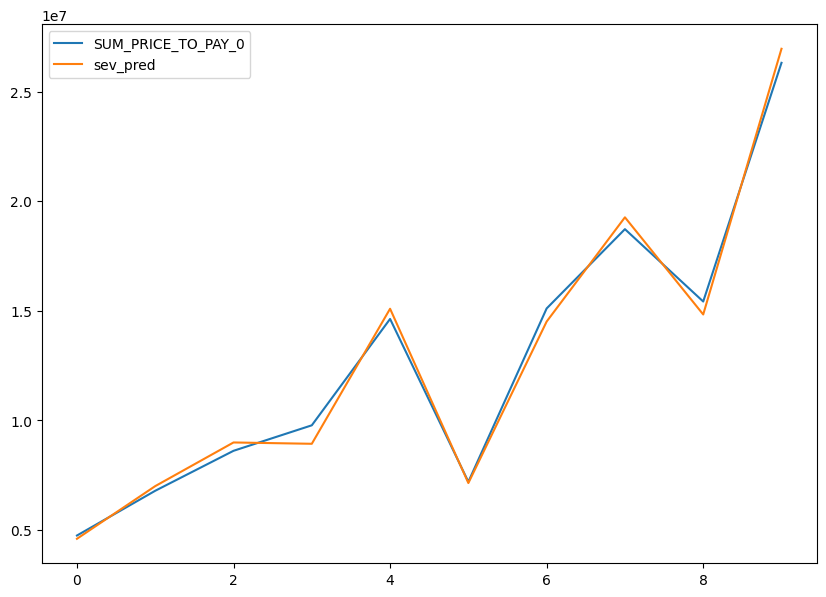

In [116]:
plt.figure(figsize=(10,7))
plt.plot(res['SUM_PRICE_TO_PAY_0'], label='SUM_PRICE_TO_PAY_0')
plt.plot(res['sev_pred'], label='sev_pred')
plt.legend()
plt.show()

In [117]:
X_sev_test['pred_bins'] = pd.qcut(X_sev_test['sev_pred'], 10)
res = X_sev_test.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY_0', 'sev_pred']].sum().reset_index()
res

C:\Temp\Sakinat.Ibragimova\13\ipykernel_548\1599077520.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = X_sev_test.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY_0', 'sev_pred']].sum().reset_index()


,pred_bins,SUM_PRICE_TO_PAY_0,sev_pred
0,"(67.389, 2186.922]",1.258871e+06,1.178456e+06
1,"(2186.922, 2819.38]",1.854343e+06,1.843375e+06
2,"(2819.38, 3265.342]",2.437620e+06,2.135631e+06
3,"(3265.342, 3820.781]",5.265745e+06,4.915648e+06
4,"(3820.781, 3909.992]",1.548102e+05,2.345080e+05
5,"(3909.992, 4656.919]",3.017145e+06,3.041787e+06
6,"(4656.919, 5223.29]",3.935723e+06,3.474257e+06
7,"(5223.29, 5913.653]",4.040487e+06,4.138290e+06
8,"(5913.653, 7788.904]",4.532964e+06,4.915606e+06
9,"(7788.904, 19240.286]",5.430598e+06,7.129116e+06


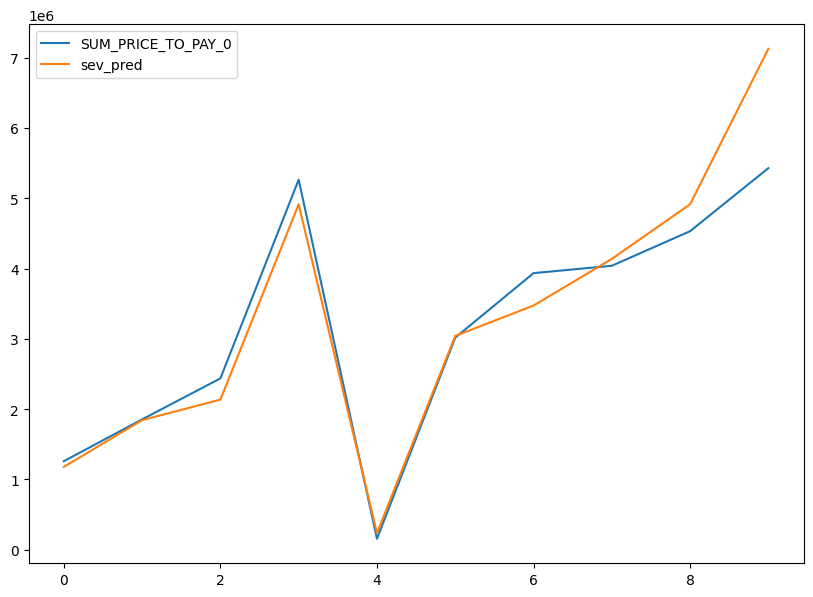

In [118]:
plt.figure(figsize=(10,7))
plt.plot(res['SUM_PRICE_TO_PAY_0'], label='SUM_PRICE_TO_PAY_0')
plt.plot(res['sev_pred'], label='sev_pred')
plt.legend()
plt.show()

In [106]:
# Создаём новый датафрейм с нужными столбцами
X_sev_prochee_nalozh = X_sev_main[['GROUP (KOD SETI/LPU)' , 'DOGOVOR_NUMBER_POLICY', 'SERVICE_POINT_ID_NEW', 'POLICY_NUMBER', 'sev_pred']].copy()

# Просмотр результата
X_sev_prochee_nalozh.head()
#X_sev_prochee_nalozh.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\X_sev_prochee_nalozh.xlsx', index=False )

,GROUP (KOD SETI/LPU),DOGOVOR_NUMBER_POLICY,SERVICE_POINT_ID_NEW,POLICY_NUMBER,sev_pred
0,2494-Set'1,008BS4581005475,67FE2FFA-09A5-5D7F-E053-596510AC686B,008BS4581005475-9,2258.947172
1,2494-Set'1,008BS4581005475,NaN,008BS4581005475-6,2258.947172
2,845/Klinika Ekspert Tver'/69-744-01,008BS4581005475,NaN,008BS4581005475-7,2258.947172
3,2494-Set'1,008BS4581005475,NaN,008BS4581005475-3,2258.947172
4,845/Klinika Ekspert Tver'/69-744-01,008BS4581005475,NaN,008BS4581005475-5,2258.947172


In [ ]:
#X_sev_main_nalozh=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\X_sev_main_nalozh.xlsx')

In [ ]:
#df_nalozh_freq=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\df_nalozh_freq.xlsx')


In [ ]:
#X_sev_prochee_nalozh=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\X_sev_prochee_nalozh.xlsx')

In [107]:
X_sev_main_nalozh.head()

,GROUP (KOD SETI/LPU),DOGOVOR_NUMBER_POLICY,SERVICE_POINT_ID_NEW,POLICY_NUMBER,sev_pred
0,2494-Set'1,008BS4581005475,67FE2FFA-09A5-5D7F-E053-596510AC686B,008BS4581005475-9,14363.771406
1,2494-Set'1,008BS4581005475,NaN,008BS4581005475-6,12745.028959
2,845/Klinika Ekspert Tver'/69-744-01,008BS4581005475,NaN,008BS4581005475-7,19593.906624
3,2494-Set'1,008BS4581005475,NaN,008BS4581005475-3,12745.028959
4,845/Klinika Ekspert Tver'/69-744-01,008BS4581005475,NaN,008BS4581005475-5,19593.906624


In [108]:
# Шаг 1: Переименуем столбцы sev_pred для ясности
X_sev_main_nalozh_renamed = X_sev_main_nalozh[['GROUP (KOD SETI/LPU)', 'POLICY_NUMBER', 'SERVICE_POINT_ID_NEW', 'sev_pred']].copy()
X_sev_main_nalozh_renamed.rename(columns={'sev_pred': 'sev_pred_main'}, inplace=True)

X_sev_prochee_nalozh_renamed = X_sev_prochee_nalozh[['GROUP (KOD SETI/LPU)', 'POLICY_NUMBER', 'SERVICE_POINT_ID_NEW', 'sev_pred']].copy()
X_sev_prochee_nalozh_renamed.rename(columns={'sev_pred': 'sev_pred_prochee'}, inplace=True)



#df_main_nalozh = df_main[['GROUP (KOD SETI/LPU)', 'POLICY_NUMBER', 'распределение по ЛПУ']].copy()


# Шаг 2: Первый merge — с основными убытками
df_nalozh_itog = df_nalozh.merge(
    X_sev_main_nalozh_renamed,
    on=['GROUP (KOD SETI/LPU)', 'SERVICE_POINT_ID_NEW', 'POLICY_NUMBER'],
    how='left'
)

# Шаг 3: Второй merge — с прочими убытками
df_nalozh_itog= df_nalozh_itog.merge(
    X_sev_prochee_nalozh_renamed,
    on=['GROUP (KOD SETI/LPU)', 'SERVICE_POINT_ID_NEW','POLICY_NUMBER'],
    how='left'
)




# # Проверка результата
# print(f"Количество строк в df_nalozh_freq после merge: {len(df_nalozh_freq)}")
# print("Новые столбцы:")
# print(df_nalozh_freq[['sev_pred_main', 'sev_pred_prochee']].notnull().sum())


In [109]:
df_nalozh_itog.shape

(717306, 151)

In [101]:
X_sev_prochee_nalozh_renamed.head()

,GROUP (KOD SETI/LPU),POLICY_NUMBER,SERVICE_POINT_ID_NEW,sev_pred_prochee
0,845/Klinika Ekspert Tver'/69-744-01,008BS4581005475-1,NaN,2245.402218
1,2494-Set'1,008BS4581005475-2,67FE2FFA-09A5-5D7F-E053-596510AC686B,2245.402218
2,845/Klinika Ekspert Tver'/69-744-01,008BS4581005475-7,NaN,2245.402218
3,2494-Set'1,008BS4581005475-9,67FE2FFA-09A5-5D7F-E053-596510AC686B,2245.402218
4,2494-Set'1,008BS4581005475-1,NaN,2245.402218


In [371]:
df_nalozh_itog.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,INSURANT_REGION,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_RAZDEL,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PRICE_CLINIC_RANK,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,SHARE_SUBWAY_DIST_MIN_BINS,PAID_FLAG_1,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_STAR_FROM_MAX_BIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_SUBWAY_DIST_MIN_BINS_BIN,cnt_insurer_for_seti,cnt_apply_for_seti,share_apply,SHARE_PRICE_LPU_FROM_MAX_v,SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),COVENANTA_ZHUD_0,COVENANTA_ZHUD_1,SHARE_PRICE_LPU_FROM_MAX_v*COV,SHARE_LPU_IN_PROGRAM*COV,CNT_CLINIC_IN_PROGRAM*COV,share_apply*COV,pred,pred_norm,final_pred,spark_Tax_type,CNT_PROGRAM/cnt_policy_beg_BIN_v,0-0.2_INSURED_EXP_NEW,>0.2_INSURED_EXP_NEW,spark_Zalog_da,spark_Zalog_not_def,OKVED_GROUP_Dejatel'nost' administrativnaja i soputstvujuschie dopolnitel'nye uslugi,OKVED_GROUP_Dejatel'nost' finansovaja i strahovaja,OKVED_GROUP_Dejatel'nost' gostinits i predprijatij obschestvennogo pitanija,OKVED_GROUP_Dejatel'nost' po operatsijam s nedvizhimym imuschestvom,"OKVED_GROUP_Dejatel'nost' professional'naja, nauchnaja i tehnicheskaja",OKVED_GROUP_Dejatel'nost' v oblasti informatsii i svjazi,"OKVED_GROUP_Dejatel'nost' v oblasti kul'tury, sporta, organizatsii dosuga i razvlechenij",OKVED_GROUP_Dejatel'nost' v oblasti zdravoohranenija i sotsial'nyh uslug,OKVED_GROUP_Dobycha poleznyh iskopaemyh,"OKVED_GROUP_Gosudarstvennoe upravlenie i obespechenie voennoj bezopasnosti, sotsial'noe obespechenie","OKVED_GROUP_Obespechenie elektricheskoj energiej, gazom i parom, konditsionirovanie vozduha",OKVED_GROUP_Obrabatyvajuschie proizvodstva,OKVED_GROUP_Obrazovanie,OKVED_GROUP_Predostavlenie prochih vidov uslug,"OKVED_GROUP_Sel'skoe, lesnoe hozjajstvo, ohota, rybolovstvo i rybovodstvo",OKVED_GROUP_Stroitel'stvo,"OKVED_GROUP_Torgovlja optovaja i roznichnaja, remont avtotransportnyh sredstv i mototsiklov",OKVED_GROUP_Transportirovka i hranenie,"OKVED_GROUP_Vodosnabzhenie, vodootvedenie, organizatsija sbora i utilizatsii othodov, dejatel'nost' po likvidatsii zagrjaznenij",PROLONGATION_TYPE_Pervichnyj,PROLONGATION_TYPE_Prolongatsija,PROLONGATION_TYPE_not_def,INSURANT_REGION_GROUP_Leningradskaja obl,INSURANT_REGION_GROUP_Moskovskaja obl,INSURANT_REGION_GROUP_Moskva,INSURANT_REGION_GROUP_Prochee,INSURANT_REGION_GROUP_Sankt-Peterburg,PRICE_LEVEL_NUM_FOR_FREQ_-1.0,PRICE_LEVEL_NUM_FOR_FREQ_0.0,PRICE_LEVEL_NUM_FOR_FREQ_1.0,PRICE_LEVEL_NUM_FOR_FREQ_2.0,PRICE_LEVEL_NUM_FOR_FREQ_3.0,PRICE_LEVEL_NUM_FOR_FREQ_4.0,PRICE_LEVEL_NUM_FOR_FREQ_5.0,PRICE_LEVEL_NUM_FOR_FREQ_6.0,PRICE_LEVEL_NUM_FOR_FREQ_7.0,PRICE_LEVEL_NUM_FOR_FREQ_8.0,PRICE_LEVEL_NUM_FOR_FREQ_9.0,OKVED_GROUP_2,OKVED_GROUP_3,INSURANT_REGION_GROUP_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_-1_0,PRICE_LEVEL_NUM_FOR_FREQ_5_6,PRICE_LEVEL_NUM_FOR_FREQ_7_8_9,PRICE_LEVEL_NUM_FOR_FREQ_-1_0_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_5_6_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_7_8_9_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_1_Moskva&obl,PRICE_LEVEL_NUM_FOR_FREQ_4_Moskva&obl,pred_1,sev_pred_main,sev_pred_prochee
0,2494

In [110]:
df_nalozh_itog.shape

(717306, 151)

In [ ]:
#df_nalozh_itog = df_nalozh_itog.drop_duplicates().reset_index(drop=True)

In [111]:
df_nalozh_itog = df_nalozh_itog[['GROUP (KOD SETI/LPU)', 'GROUP_NAME_SETI_TOU', 'DOGOVOR_NUMBER_POLICY', 'COVENANTA_ZHUD_1', 'PROGRAM_NAME', 'SERVICE_POINT_ID_NEW' ,'POLICY_NUMBER',  'HOLDING', 'PAID_FLAG_1', 'PRICE_VALUE',
                          'HOLDING_DOC_NUM', 'INSURANT_REGION', 'INSURANT_NAME', 'START_DATE', 'END_DATE', 'CNT_POLICY_BEG', 'FOLD', 'INSURED_EXP_NEW', 'SUM_PRICE_TO_PAY',  'PAID_FLAG', 'pred', 'final_pred', 'pred_1', 'sev_pred_main', 'sev_pred_prochee'
                          ]].copy()

In [112]:
df_nalozh_itog.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\df_nalozh_itog5.xlsx', index=False )

In [ ]:
X_sev_main[X_sev_main['POLICY_NUMBER']=='008BS3950000457-2']


,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,OKVED_GROUP_2,OKVED_GROUP_3,sev_pred,OKVED_GROUP_4,OKVED_GROUP_7,PRICE_LEVEL_NUM_FOR_FREQ_1,PRICE_LEVEL_NUM_FOR_FREQ_4,PRICE_LEVEL_NUM_FOR_FREQ_5_6,PRICE_LEVEL_NUM_FOR_FREQ_7_8_9,PROLONGATION_TYPE_Prolongatsija_not_def
338977,4976-Set'1756,LDTs MIBS (Sankt-Peterburg),008BS3950000457,AKTIV (TOMSK),008BS3950000455,"OOO ""TOMLESDREV""",008BS3950000457-2,2022-01-04 00:00:00,2023-01-03 23:59:59,2022-01-04 00:00:00,...,True,True,4346.122686,False,False,False,False,False,False,False
338982,RMS000587,"OOO ""Zdorov'e""",008BS3950000457,AKTIV (TOMSK),008BS3950000455,"OOO ""TOMLESDREV""",008BS3950000457-2,2022-01-04 00:00:00,2023-01-03 23:59:59,2022-01-04 00:00:00,...,True,True,3009.352515,False,False,False,False,False,False,False


In [315]:
data_combined_1[data_combined_1['POLICY_NUMBER']=='008DT4580000042-343']

,Unnamed: 0,DOGOVOR_NUMBER_POLICY,HOLDING,INSURANT_NAME,INSURANT_TYPE,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,...,OKVED_GROUP_1,OKVED_GROUP_2,OKVED_GROUP_3,OKVED_GROUP_4,OKVED_GROUP_7,PRICE_LEVEL_NUM_FOR_FREQ_5_6,PRICE_LEVEL_NUM_FOR_FREQ_7_8_9,PROLONGATION_TYPE_Prolongatsija_not_def,sev_pred,dataset
17457,21579,008DT4580000042,IGS,"AO ""INVESTGEOSERVIS""",Ju,008DT4580000042-343,2023-09-30 00:00:00,29.09.24,20.07.24,29.09.24,...,True,False,False,False,False,False,True,False,13126.740986,train


In [322]:
df_main[df_main['GROUP (KOD SETI/LPU)']=="1721-Set'1"]

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,...,PRICE_LEVEL_NUM_FOR_FREQ,spark_Zalog,spark_Tax_type,CNT_PROGRAM/cnt_policy_beg_BIN_v,0-0.2_INSURED_EXP_NEW,>0.2_INSURED_EXP_NEW,0-0.1_INSURED_EXP_NEW,>0.1_INSURED_EXP_NEW,0-0.12_INSURED_EXP_NEW,>0.12_INSURED_EXP_NEW
76,1721-Set'1,Poliklinika.ru,008BS4580002936,AKSIOMA-SOFT,008BS4580002934,"OOO ""AKSIOMA-SOFT KONSALTING""",008BS4580002936-78,2024-10-15 00:00:00,2025-10-14 23:59:59,2024-10-15 00:00:00,...,4.0,not_def,not_def,4.0,0.2,1.00,0.1,1.00,0.12,1.00
108,1721-Set'1,Poliklinika.ru,008BS4580002936,AKSIOMA-SOFT,008BS4580002934,"OOO ""AKSIOMA-SOFT KONSALTING""",008BS4580002936-47,2024-10-15 00:00:00,2025-10-14 23:59:59,2024-10-15 00:00:00,...,4.0,not_def,not_def,4.0,0.2,1.00,0.1,1.00,0.12,1.00
109,1721-Set'1,Poliklinika.ru,008BS4580002936,AKSIOMA-SOFT,008BS4580002934,"OOO ""AKSIOMA-SOFT KONSALTING""",008BS4580002936-142,2024-10-15 00:00:00,2025-10-14 23:59:59,2025-03-10 00:00:00,...,4.0,not_def,not_def,4.0,0.2,0.60,0.1,0.60,0.12,0.60
162,1721-Set'1,Poliklinika.ru,008BS4580002936,AKSIOMA-SOFT,008BS4580002934,"OOO ""AKSIOMA-SOFT KONSALTING""",008BS4580002936-128,2024-10-15 00:00:00,2025-10-14 23:59:59,2025-02-01 00:00:00,...,4.0,not_def,not_def,4.0,0.2,0.70,0.1,0.70,0.12,0.70
192,1721-Set'1,Poliklinika.ru,008BS4580002936,AKSIOMA-SOFT,008BS4580002934,"OOO ""AKSIOMA-SOFT KONSALTING""",008BS4580002936-99,2024-10-15 00:00:00,2025-10-14 23:59:59,2024-11-01 00:00:00,...,4.0,not_def,not_def,4.0,0.2,0.47,0.1,0.47,0.12,0.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714240,1721-Set'1,Poliklinika.ru,008BS4580002578,SMU ITS,008BS4580002577,"OOO ""BLITsENERGO""",008BS4580002578-32,2024-06-17 00:00:00,2025-06-16 23:59:59,2025-02-01 00:00:00,...,-1.0,not_def,not_def,5.0,0.2,0.37,0.1,0.37,0.12,0.37
714246,1721-Set'1,Poliklinika.ru,008BS4580002578,SMU ITS,008BS4580002577,"OOO ""BLITsENERGO""",008BS4580002578-36,2024-06-17 00:00:00,2025-06-16 23:59:59,2025-03-10 00:00:00,...,-1.0,not_def,not_def,5.0,0.2,0.27,0.1,0.27,0.12,0.27
714893,1721-Set'1,Poliklinika.ru,008DR4580000042,MSS (MOSKVA),008DR4580000042,"AO ""MSS""",008DR4580000042-52,2024-02-05 00:00:00,2025-02-04 23:59:59,2024-07-20 00:00:00,...,-1.0,not_def,not_def,3.0,0.2,0.55,0.1,0.55,0.12,0.55
714904,1721-Set'1,Poliklinika.ru,008DR4580000042,MSS (MOSKVA),008DR4580000042,"AO ""MSS""",008DR4580000042-53,2024-02-05 00:00:00,2025-02-04 23:59:59,2024-09-01 00:00:00,...,-1.0,not_def,not_def,3.0,0.2,0.43,0.1,0.43,0.12,0.43


In [630]:
X_sev_test['pred_bins'] = pd.qcut(X_sev_test['sev_pred'], 10)
res = X_sev_test.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY_0', 'sev_pred']].sum().reset_index()
res

C:\Temp\Sakinat.Ibragimova\53\ipykernel_8704\1599077520.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = X_sev_test.groupby(['pred_bins'])[['SUM_PRICE_TO_PAY_0', 'sev_pred']].sum().reset_index()


,pred_bins,SUM_PRICE_TO_PAY_0,sev_pred
0,"(67.054, 2187.128]",1.258871e+06,1.176828e+06
1,"(2187.128, 2820.385]",1.854343e+06,1.839244e+06
2,"(2820.385, 3268.084]",2.445190e+06,2.151334e+06
3,"(3268.084, 3822.548]",5.266869e+06,4.910879e+06
4,"(3822.548, 3895.777]",1.461162e+05,2.267972e+05
5,"(3895.777, 4648.532]",3.015785e+06,3.034713e+06
6,"(4648.532, 5226.167]",3.937083e+06,3.478818e+06
7,"(5226.167, 5904.671]",3.984107e+06,4.071250e+06
8,"(5904.671, 7784.648]",4.589344e+06,4.978123e+06
9,"(7784.648, 19203.49]",5.430598e+06,7.125030e+06


In [438]:
X_sev_test[['SUM_PRICE_TO_PAY_0', 'sev_pred']]

,SUM_PRICE_TO_PAY_0,sev_pred
0,0.000000,2048.325833
9,2180.000000,3009.352515
13,0.000000,3822.547722
28,0.000000,3822.547722
39,0.000000,5750.483712
40,0.000000,3853.428822
41,0.000000,3853.428822
42,0.000000,3853.428822
43,0.000000,3529.540536
44,2250.000000,3853.428822


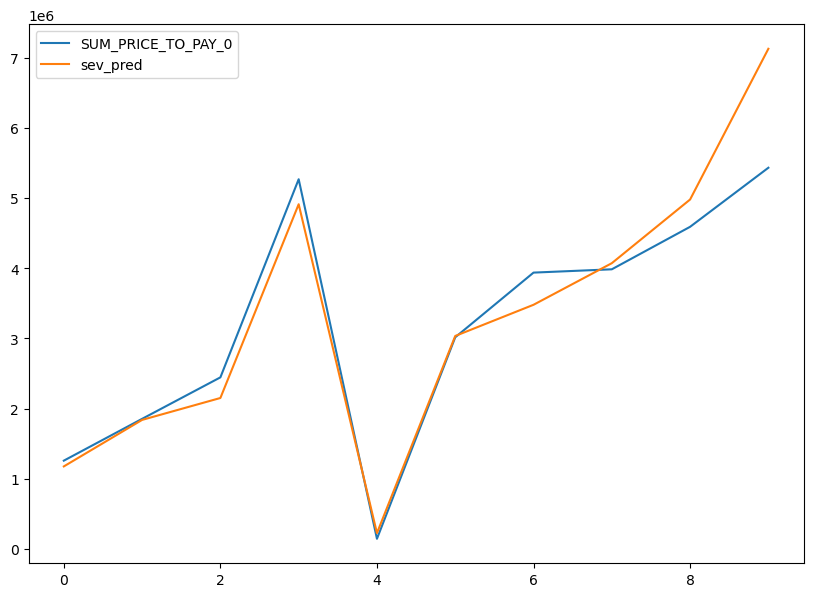

In [110]:
plt.figure(figsize=(10,7))
plt.plot(res['SUM_PRICE_TO_PAY_0'], label='SUM_PRICE_TO_PAY_0')
plt.plot(res['sev_pred'], label='sev_pred')
plt.legend()
plt.show()

<Axes: xlabel='SUM_PRICE_TO_PAY_0', ylabel='sev_pred'>

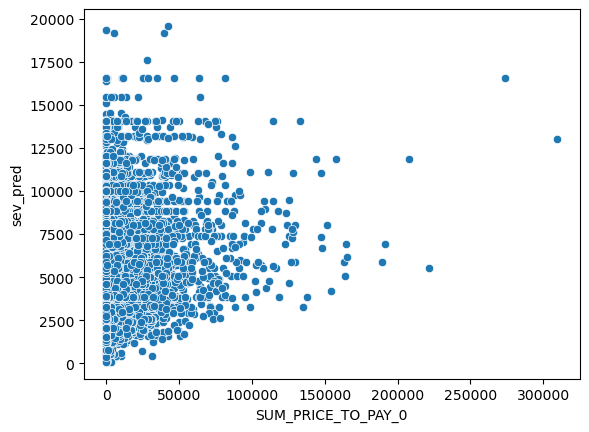

In [111]:
sns.scatterplot(x= X_sev_tr['SUM_PRICE_TO_PAY_0'], y=X_sev_tr['sev_pred']) 

In [110]:
import pandas as pd

# Добавляем метку источника
X_sev_tr = X_sev_tr.copy()  # хорошая практика
X_sev_test = X_sev_test.copy()

X_sev_tr['dataset'] = 'train'
X_sev_test['dataset'] = 'test'

# Объединяем таблицы
data_combined_1 = pd.concat([X_sev_tr, X_sev_test], ignore_index=True)

# Проверка
print("Размер объединённой таблицы:", data_combined_1.shape)
print("Количество по датасетам:")
print(data_combined_1['dataset'].value_counts())

Размер объединённой таблицы: (36172, 192)
Количество по датасетам:
dataset
train    29098
test      7074
Name: count, dtype: int64


In [111]:
data_combined_1.to_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\наложение_выплаты_в_прочие_ЛПУ.xlsx', index=False )

In [1234]:
df_main=pd.read_excel(r'T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ДМС\2026 1кв\наложение\merged_df.xlsx')

In [1239]:
df_main.columns.tolist()

['GROUP (KOD SETI/LPU)',
 'GROUP_NAME_SETI_TOU',
 'DOGOVOR_NUMBER_POLICY',
 'HOLDING',
 'HOLDING_DOC_NUM',
 'INSURANT_NAME',
 'POLICY_NUMBER',
 'RESP_DT_BEG',
 'RESP_DT_END',
 'START_DATE',
 'END_DATE',
 'DAYS',
 'ATTACHMENT',
 'UNPINNING',
 'CNT_PROGRAM',
 'CNT_POLICY_BEG',
 'CNT_PROGRAM/cnt_policy_beg',
 'Pol',
 'F_GENDER',
 'CHILD',
 'RELATIVE',
 'PREPAYMENT',
 'DIRECT_SERVICE',
 'COMPENSATION',
 'VIP',
 'PROGRAM_NAME',
 'DOGOVOR_TYPE',
 'PROLONGATION_TYPE',
 'INSURANT_REGION',
 'INSURANT_REGION_GROUP',
 'INS_AGE',
 'INS_AGE_CATEGORY',
 'INSURED_AGEGROUP',
 'INSURED_EXP_NEW',
 'OKVED_GROUP',
 'OKVED_RAZDEL',
 'Region_itog',
 'MAX_STAR',
 'MAX_REVIEWS',
 'MIN_BUS_DIST_MIN',
 'MIN_SUBWAY_DIST_MIN',
 'MAX_SUBWAY_SYNT',
 'MIN_SUBWAY_SYNT',
 'AVG_SUBWAY_SYNT',
 'CNT_LPU_V_SETI',
 'REGION ITOG',
 'REGION ITOG_GROUP',
 'ASSISTANCE_TYPE',
 'SUM_PRICE_TO_PAY',
 'CNT',
 'SERVICE_POINT_ID_NEW',
 'CLINIC_RANK',
 'PRICE_LEVEL',
 'PRICE_LEVEL_NUM',
 'PRICE_VALUE',
 'PROGRAM_LIST_RISK_PREPAY_SPEC'

In [1240]:
df_main.head()

,GROUP (KOD SETI/LPU),GROUP_NAME_SETI_TOU,DOGOVOR_NUMBER_POLICY,HOLDING,HOLDING_DOC_NUM,INSURANT_NAME,POLICY_NUMBER,RESP_DT_BEG,RESP_DT_END,START_DATE,END_DATE,DAYS,ATTACHMENT,UNPINNING,CNT_PROGRAM,CNT_POLICY_BEG,CNT_PROGRAM/cnt_policy_beg,Pol,F_GENDER,CHILD,RELATIVE,PREPAYMENT,DIRECT_SERVICE,COMPENSATION,VIP,PROGRAM_NAME,DOGOVOR_TYPE,PROLONGATION_TYPE,INSURANT_REGION,INSURANT_REGION_GROUP,INS_AGE,INS_AGE_CATEGORY,INSURED_AGEGROUP,INSURED_EXP_NEW,OKVED_GROUP,OKVED_RAZDEL,Region_itog,MAX_STAR,MAX_REVIEWS,MIN_BUS_DIST_MIN,MIN_SUBWAY_DIST_MIN,MAX_SUBWAY_SYNT,MIN_SUBWAY_SYNT,AVG_SUBWAY_SYNT,CNT_LPU_V_SETI,REGION ITOG,REGION ITOG_GROUP,ASSISTANCE_TYPE,SUM_PRICE_TO_PAY,CNT,SERVICE_POINT_ID_NEW,CLINIC_RANK,PRICE_LEVEL,PRICE_LEVEL_NUM,PRICE_VALUE,PROGRAM_LIST_RISK_PREPAY_SPEC,COMISSION_PERCENTAGE_FIX,COVENANTA,PAID_FLAG,SHARE_PRICE_LPU_FROM_MAX,SHARE_STAR_FROM_MAX,SHARE_REVIEW_FROM_MAX,SHARE_BUS_DIST_MIN_FROM_MIN,SHARE_SUBWAY_DIST_MIN_FROM_MIN,SHARE_MAX_SUBWAY_SYNT_FROM_MIN,SHARE_MIN_SUBWAY_SYNT_FROM_MIN,SHARE_AVG_SUBWAY_SYNT_FROM_MIN,METRO_FLAG,CNT_CLINIC_IN_PROGRAM,SHARE_LPU_IN_PROGRAM,FOLD,PAID_FLAG_1,SHARE_SUBWAY_DIST_MIN_BINS,const,0-0.14_SHARE_LPU_IN_PROGRAM,>0.14_SHARE_LPU_IN_PROGRAM,SHARE_STAR_FROM_MAX_v,SHARE_MIN_SUBWAY_SYNT_FROM_MIN_BIN,SHARE_SUBWAY_DIST_MIN_BINS_CODE,SHARE_STAR_FROM_MAX_BIN_level_1 (-1),SHARE_STAR_FROM_MAX_BIN_level_2 (others),SHARE_PRICE_LPU_BIN_level_1 (-1),SHARE_PRICE_LPU_BIN_level_2 (others),SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_1 (-1),SHARE_SUBWAY_DIST_MIN_BINS_BIN_level_2 (others),pred,pred_norm,final_pred,pred_bins,PRICE_LEVEL_NUM_FOR_FREQ,spark_Zalog,spark_Tax_type,CNT_PROGRAM/cnt_policy_beg_BIN_v
0,4404-1,Tsentr kul'tury zdorov'ja Olimp Pjat',008BS4581008118,T-PROEKT,008BS4581008118,"OOO ""T-PROEKT""",008BS4581008118-1,2024-07-15 00:00:00,2025-07-14 23:59:59,2024-07-15 00:00:00,2025-07-14 23:59:59,366,0,0,1,1,1.00,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Voronezh,1,Pervichnyj,Voronezhskaja obl,Prochee,58,50-59,18-64,1.00,Torgovlja optovaja i roznichnaja; remont avtot...,Razdel G,VORONEZhSKAJa,5.0,531,0.26,-1.0,0.0,0.0,0.0,1,VORONEZhSKAJa,PROCHEE,Prjamoj dogovor SBS,7400.0,2,a35ef0ee-19a8-492e-bea9-bdfdfd8cf48d,2,VIP,6,20835,Risk,15.0,noncovenant,1,1.00,1.0,0.15,0.24,-1.0,0.0,0.0,0.0,3,4,0.25,4,0,-1,1,0.14,0.25,1.0,level_2 (others),1,False,True,False,True,True,False,0.375354,1.274168,0.294587,"(0.257, 1.0]",6.0,not_def,USN,20.0
1,2614-Set'1,Klinika Gorod Zdorov'ja,008BS4581008118,T-PROEKT,008BS4581008118,"OOO ""T-PROEKT""",008BS4581008118-1,2024-07-15 00:00:00,2025-07-14 23:59:59,2024-07-15 00:00:00,2025-07-14 23:59:59,366,0,0,1,1,1.00,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Voronezh,1,Pervichnyj,Voronezhskaja obl,Prochee,58,50-59,18-64,1.00,Torgovlja optovaja i roznichnaja; remont avtot...,Razdel G,VORONEZhSKAJa,5.0,3547,0.10,-1.0,0.0,0.0,0.0,1,VORONEZhSKAJa,PROCHEE,Prjamoj dogovor SBS,129440.0,17,155ca2e8-7a1a-4257-8dda-39d65e680efb,1,VIP,6,20835,Risk,15.0,noncovenant,1,1.00,1.0,1.00,0.09,-1.0,0.0,0.0,0.0,3,4,0.25,4,1,-1,1,0.14,0.25,1.0,level_2 (others),1,False,True,False,True,True,False,0.375354,1.274168,0.294587,"(0.257, 1.0]",6.0,not_def,USN,20.0
2,1767-Set'1,ChUZ «KB «RZhD-Meditsina» g. Voronezh»,008BS4581008118,T-PROEKT,008BS4581008118,"OOO ""T-PROEKT""",008BS4581008118-1,2024-07-15 00:00:00,2025-07-14 23:59:59,2024-07-15 00:00:00,2025-07-14 23:59:59,366,0,0,1,1,1.00,M,0,0,0,0,1,0,0,Programma № 1: Vzroslaja Voronezh,1,Pervichnyj,Voronezhskaja obl,Prochee,58,50-59,18-64,1.00,Torgovlja optovaja i roznichnaja; remont avtot...,Razdel G,VORONEZhSKAJa,-1.0,-1,-1.00,-1.0,-1.0,-1.0,-1.0,1,VORONEZhSKAJa,PROCHEE,Prjamoj dogovor SBS,2150.0,1,67FE2FFA-DFB6-5D7F-E053-596510AC686B,3,ECONOM,1,6061,Risk,15.0,noncovenant,1,0.29,-1.0,-1.00,-1.00,-1.0,-1.0,-1.0,-1.0,3,4,0.25,4,0,-1,1,0.14,0.25,-1.0,level_1 (-1),1,True,False,False,True,True,False,0.148106,1.274168,0.116238,"(0.114, 0.167]",6.0,not_def,USN,20.0
3,4422-1,Klinika semejnoj meditsiny Evkalipt,008BS4581008118,T-PROEKT,008BS4581008118,"OOO ""T-PROEKT""

In [1241]:
df_main.shape

(702831, 93)

In [1238]:
# Список нужных столбцов из df
cols_to_add = [
    'POLICY_NUMBER',  # ключ обязательно включаем

    'PRICE_LEVEL_NUM_FOR_FREQ',

    'spark_Zalog',
    'spark_Tax_type',
    'CNT_PROGRAM/cnt_policy_beg_BIN_v'
]

# Проверка: существуют ли такие столбцы в df_score?
missing_cols = [col for col in cols_to_add if col not in df.columns]
if missing_cols:
    print("❌ Нет таких столбцов в df:", missing_cols)
else:
    print(f"✅ Все {len(cols_to_add)-1} столбцов найдены")

    # Выбираем подмножество данных
    df_score_subset = df[cols_to_add].copy()

    # Выполняем left join: сохраняем все строки из df_main
    df_main = df_main.merge(df_score_subset, on='POLICY_NUMBER', how='left')

    print(f"✅ Столбцы успешно добавлены к df_main")


✅ Все 4 столбцов найдены
✅ Столбцы успешно добавлены к df_main
